## 1. Brief Description of the Task and Method

This project aims to maximize revenue from direct marketing campaigns for a bank.

For the analysis, several tables are available:
* Social-demographical data (age, gender, tenure in a bank)
* Products owned + actual volumes (current account, saving account, mutual funds, overdraft, credit card, consumer loan)
* Inflow/outflow on C/A, aggregated card turnover (monthly average over past 3 months)
* For 60 % of clients actual sales + revenues from these are available (training set)

The bank has capacity to contact only 15% of the clients (cca 100 people) with a marketing offer and each client can be targeted only once.

The bank expected the following outcomes for the project:
* Which clients have higher propensity to buy consumer loan?
* Which clients have higher propensity to buy credit card?
* Which clients have higher propensity to buy mutual fund?
* Which clients are to be targeted with which offer? A general description is expected.
* What would be the expected revenue based on your strategy?

The executive summary of the analysis should not be larger than two pages. A technical report is rerquired to list clients to be contacted with which offer.

Based on the business understanding and data understanding, both classification models and regression models are created to solve this marketing optimization problem. The method can be described as follows:
* All the features in "Soc_Dem", "Products_ActBalance" and "Inflow_Outflow" tables are merged together to make the prediction.
* For each of the products "MF", "CC" and "CL", a classification model is built up to predict the buying propensity.
* For each of the products "MF", "CC" and "CL", regression models are built up to predict the expected revenue and its 90% confidence interval.
* Based on the predicted buying propensity and the predicted revenue for each potential client, expected total revenue from buying all the three products is calculated. 
* The 100 clients with the highest expected total revenue from buying all the three products are selected as the suggested target clients of the direct marketing campaign.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Importing the Data from the Excel Worksheets

In [49]:
raw_data_path: str = "../data/raw/"
excl_file_name = "Task_Data_Scientist_Dataset.xlsx"

# Parse the Excel file into DataFrame objects 
xlsx = pd.ExcelFile(os.path.join(raw_data_path, excl_file_name))

# Read the worksheets into dataframes
df_Soc_Dem: pd.DataFrame = xlsx.parse("Soc_Dem", header=0) 
df_Products_ActBalance: pd.DataFrame = xlsx.parse("Products_ActBalance", header=0) 
df_Inflow_Outflow: pd.DataFrame = xlsx.parse("Inflow_Outflow", header=0) 
df_Sales_Revenues: pd.DataFrame = xlsx.parse("Sales_Revenues", header=0) 

## 3. Basic EDA of the Dataframes

In [50]:
# Table Soc_Dem
df_Soc_Dem.info()
df_Soc_Dem.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1615 entries, 0 to 1614
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Client  1615 non-null   int64 
 1   Sex     1612 non-null   object
 2   Age     1615 non-null   int64 
 3   Tenure  1615 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 50.6+ KB


,Client,Age,Tenure
count,1615.000000,1615.000000,1615.000000
mean,808.000000,42.848916,101.339938
std,466.354658,18.550529,64.917297
min,1.000000,0.000000,0.000000
25%,404.500000,29.000000,44.000000
50%,808.000000,41.000000,97.000000
75%,1211.500000,57.000000,151.000000
max,1615.000000,97.000000,273.000000


In [51]:
# Table Products_ActBalance
df_Products_ActBalance.info()
df_Products_ActBalance.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1615 entries, 0 to 1614
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Client      1615 non-null   int64  
 1   Count_CA    1615 non-null   int64  
 2   Count_SA    426 non-null    float64
 3   Count_MF    306 non-null    float64
 4   Count_OVD   419 non-null    float64
 5   Count_CC    170 non-null    float64
 6   Count_CL    135 non-null    float64
 7   ActBal_CA   1615 non-null   float64
 8   ActBal_SA   426 non-null    float64
 9   ActBal_MF   306 non-null    float64
 10  ActBal_OVD  419 non-null    float64
 11  ActBal_CC   170 non-null    float64
 12  ActBal_CL   135 non-null    float64
dtypes: float64(11), int64(2)
memory usage: 164.2 KB


,Client,Count_CA,Count_SA,Count_MF,Count_OVD,Count_CC,Count_CL,ActBal_CA,ActBal_SA,ActBal_MF,ActBal_OVD,ActBal_CC,ActBal_CL
count,1615.000000,1615.000000,426.000000,306.000000,419.0,170.0,135.000000,1615.000000,426.000000,306.000000,419.000000,170.000000,135.000000
mean,808.000000,1.078638,1.166667,4.676471,1.0,1.0,1.185185,2438.601941,15201.520284,20517.533479,126.449897,351.295420,4237.641981
std,466.354658,0.333035,0.468205,7.845009,0.0,0.0,0.520980,7072.777350,32365.183430,78046.994833,290.573266,486.679857,4167.134365
min,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,-15.479286,0.000000
25%,404.500000,1.000000,1.000000,1.000000,1.0,1.0,1.000000,61.562143,728.145000,0.000000,0.000000,1.241071,1020.163393
50%,808.000000,1.000000,1.000000,2.000000,1.0,1.0,1.000000,462.221786,4413.503571,1700.943036,0.000000,153.006071,3141.900000
75%,1211.500000,1.000000,1.000000,5.000000,1.0,1.0,1.000000,2174.864286,14622.666071,11169.181339,93.114286,545.008839,5851.657679
max,1615.000000,4.000000,5.000000,79.000000,1.0,1.0,5.000000,171575.889643,389883.830714,761235.504286,2055.325357,3522.233571,20749.294643


In [52]:
# Table Inflow_Outflow
df_Inflow_Outflow.info()
df_Inflow_Outflow.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1587 entries, 0 to 1586
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Client                        1587 non-null   int64  
 1   VolumeCred                    1587 non-null   float64
 2   VolumeCred_CA                 1587 non-null   float64
 3   TransactionsCred              1587 non-null   int64  
 4   TransactionsCred_CA           1587 non-null   int64  
 5   VolumeDeb                     1587 non-null   float64
 6   VolumeDeb_CA                  1587 non-null   float64
 7   VolumeDebCash_Card            1587 non-null   float64
 8   VolumeDebCashless_Card        1587 non-null   float64
 9   VolumeDeb_PaymentOrder        1587 non-null   float64
 10  TransactionsDeb               1587 non-null   int64  
 11  TransactionsDeb_CA            1587 non-null   int64  
 12  TransactionsDebCash_Card      1587 non-null   int64  
 13  Tra

,Client,VolumeCred,VolumeCred_CA,TransactionsCred,TransactionsCred_CA,VolumeDeb,VolumeDeb_CA,VolumeDebCash_Card,VolumeDebCashless_Card,VolumeDeb_PaymentOrder,TransactionsDeb,TransactionsDeb_CA,TransactionsDebCash_Card,TransactionsDebCashless_Card,TransactionsDeb_PaymentOrder
count,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000,1587.000000
mean,808.174543,1823.559572,1506.329113,5.541903,4.265280,1697.218658,1460.202903,257.937337,150.850401,715.974931,16.006931,13.596723,1.988658,5.240076,4.601134
std,466.744374,5864.792552,4661.535696,6.355383,4.944032,5183.787844,4281.369956,757.734230,311.938796,3215.106760,16.243554,12.975287,2.710704,8.386154,5.211451
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,405.500000,252.923393,214.290893,2.000000,2.000000,226.214286,211.848750,0.000000,0.000000,0.000000,4.000000,4.000000,0.000000,0.000000,0.000000
50%,808.000000,655.867500,620.858214,3.000000,3.000000,654.615357,632.148929,71.428571,20.139286,175.428571,11.000000,10.000000,1.000000,1.000000,3.000000
75%,1213.500000,1426.027143,1304.757143,6.000000,4.000000,1418.208214,1329.007857,353.370536,175.892500,507.607143,22.000000,19.000000,3.000000,7.000000,7.000000
max,1615.000000,107703.804286,98717.675000,63.000000,48.000000,119906.503929,73477.932500,23571.428571,3637.616786,72278.782143,102.000000,83.000000,25.000000,60.000000,34.000000


In [53]:
# Table Sales_Revenues
df_Sales_Revenues.info()
df_Sales_Revenues.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 969 entries, 0 to 968
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Client      969 non-null    int64  
 1   Sale_MF     969 non-null    int64  
 2   Sale_CC     969 non-null    int64  
 3   Sale_CL     969 non-null    int64  
 4   Revenue_MF  969 non-null    float64
 5   Revenue_CC  969 non-null    float64
 6   Revenue_CL  969 non-null    float64
dtypes: float64(3), int64(4)
memory usage: 53.1 KB


,Client,Sale_MF,Sale_CC,Sale_CL,Revenue_MF,Revenue_CC,Revenue_CL
count,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000
mean,814.781218,0.199174,0.249742,0.299278,1.925015,2.712827,3.604220
std,464.568139,0.399586,0.433087,0.458178,9.943601,17.693433,7.743618
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,422.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,819.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1216.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.642857
max,1615.000000,1.000000,1.000000,1.000000,220.488214,407.962500,133.275357


In [54]:
# Check the overlap of the Client IDs between different tables

df_merged_Soc_Products = pd.merge(left=df_Soc_Dem, right=df_Products_ActBalance, left_on='Client', right_on='Client')
num_common_ids_Soc_Products = df_merged_Soc_Products.shape[0]

df_merged_Soc_Products_Flow = pd.merge(left=df_merged_Soc_Products, right=df_Inflow_Outflow, left_on='Client', right_on='Client')
num_common_ids_Soc_Products_Flow = df_merged_Soc_Products_Flow.shape[0]

df_merged_all = pd.merge(left=df_merged_Soc_Products_Flow, right=df_Sales_Revenues, left_on='Client', right_on='Client')
num_common_ids_Soc_Products_Flow_Revenues = df_merged_all.shape[0]

print(f"Num. of common Client IDs in Soc_Dem and Products_ActBalance: {num_common_ids_Soc_Products}")
print(f"Num. of common Client IDs in Soc_Dem, Products_ActBalance, and Inflow_Outflow: {num_common_ids_Soc_Products_Flow}")
print(f"Num. of common Client IDs in Sales_Revenues and other tables: {num_common_ids_Soc_Products_Flow_Revenues}")


Num. of common Client IDs in Soc_Dem and Products_ActBalance: 1615
Num. of common Client IDs in Soc_Dem, Products_ActBalance, and Inflow_Outflow: 1587
Num. of common Client IDs in Sales_Revenues and other tables: 951


In [55]:
# Calculate the target rates for the products MF, CC, and CL

target_rate_Sale_MF = df_Sales_Revenues['Sale_MF'].sum() / df_Sales_Revenues.shape[0]
target_rate_Sale_CC = df_Sales_Revenues['Sale_CC'].sum() / df_Sales_Revenues.shape[0]
target_rate_Sale_CL = df_Sales_Revenues['Sale_CL'].sum() / df_Sales_Revenues.shape[0]

print(f"Sale_MF target rate: {target_rate_Sale_MF}")
print(f"Sale_CC target rate: {target_rate_Sale_CC}")
print(f"Sale_CL target rate: {target_rate_Sale_CL}")


Sale_MF target rate: 0.19917440660474717
Sale_CC target rate: 0.24974200206398348
Sale_CL target rate: 0.29927760577915374


#### <span style="color:orange">**Analysis Results and Comments**</span>

* Number of Client IDs in Different Tables:

| Table | Num. of Client IDs |
| ----------- | ----------- |
| Soc_Dem | 1615 |
| Products_ActBalance | 1615 |
| Inflow_Outflow | 1587 |
| Sales_Revenues | 969 |

<br/><br/>

* Categorical Features
  * "Sex" in Table Soc_Dem
<br/><br/>

* Numerical Features
  * All features other than "Client" and "Sex" in different tables
<br/><br/>

* Missing Values
  * 3 missing values in "Sex" column in Table Soc_Dem.
  * For all the numerical features in different tables, all the missing values can be imputed as zero.
  * There is no missing value in Sales_Revenues table; i.e., for every record in this table, it has values for all the 6 target
  variables.
<br/><br/>

* Client ID Overlap between Tables
  * The training set in the table Sales_Revenues contains 969 Client IDs, among them **951** have data in all other tables. 
  * The num. of common Client IDs in all other tables is 1587. By excluding the 951 Client IDs for training, the remaining 
    **636** Client IDs can be used for constructing the application set.   
<br/><br/>

* Imbalanced Targets
  * There are high imbalance in the values of the target variables "Sale_MF", "Sale_CC", and "Sale_CL".


## 4. Preparing the Datasets for Modeling and Prediction

In [56]:
# Change the data type of "Client" column to str in each dataframe to use it as the record ID.
df_merged_Soc_Products_Flow['Client'] = df_merged_Soc_Products_Flow['Client'].astype(str)
df_Sales_Revenues['Client'] = df_Sales_Revenues['Client'].astype(str)

In [57]:
from sklearn.impute import SimpleImputer

# The "Sex" column has only 3 missing values. Mode imputation is applied to fill in the missing values.
gender_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
df_merged_Soc_Products_Flow['Sex'] = gender_imputer.fit_transform(df_merged_Soc_Products_Flow['Sex'].values.reshape(-1, 1))[:, 0]

# Impute the missing values of all numerical columns as 0
df_merged_Soc_Products_Flow.fillna(0.0, inplace=True)

# Generate one-hot encoding for the "Sex" feature
df_encoded_Soc_Products_Flow = pd.get_dummies(df_merged_Soc_Products_Flow, columns=['Sex'], drop_first=True, dtype=int)

# Create the dataset for training
df_modeling = pd.merge(left=df_encoded_Soc_Products_Flow, right=df_Sales_Revenues, left_on='Client', right_on='Client')

# Create the dataset for prediction
df_outer = pd.merge(left=df_encoded_Soc_Products_Flow, right=df_Sales_Revenues, how='outer', 
                    left_on='Client', right_on='Client', indicator = True)
df_prediction = df_outer[(df_outer._merge=='left_only')].drop(['_merge', 
                                                               'Sale_MF',
                                                               'Sale_CC',
                                                               'Sale_CL',
                                                               'Revenue_MF',
                                                               'Revenue_CC',
                                                               'Revenue_CL'], axis=1)

Text(0.5, 1.0, 'Correlation between the features and the targets')

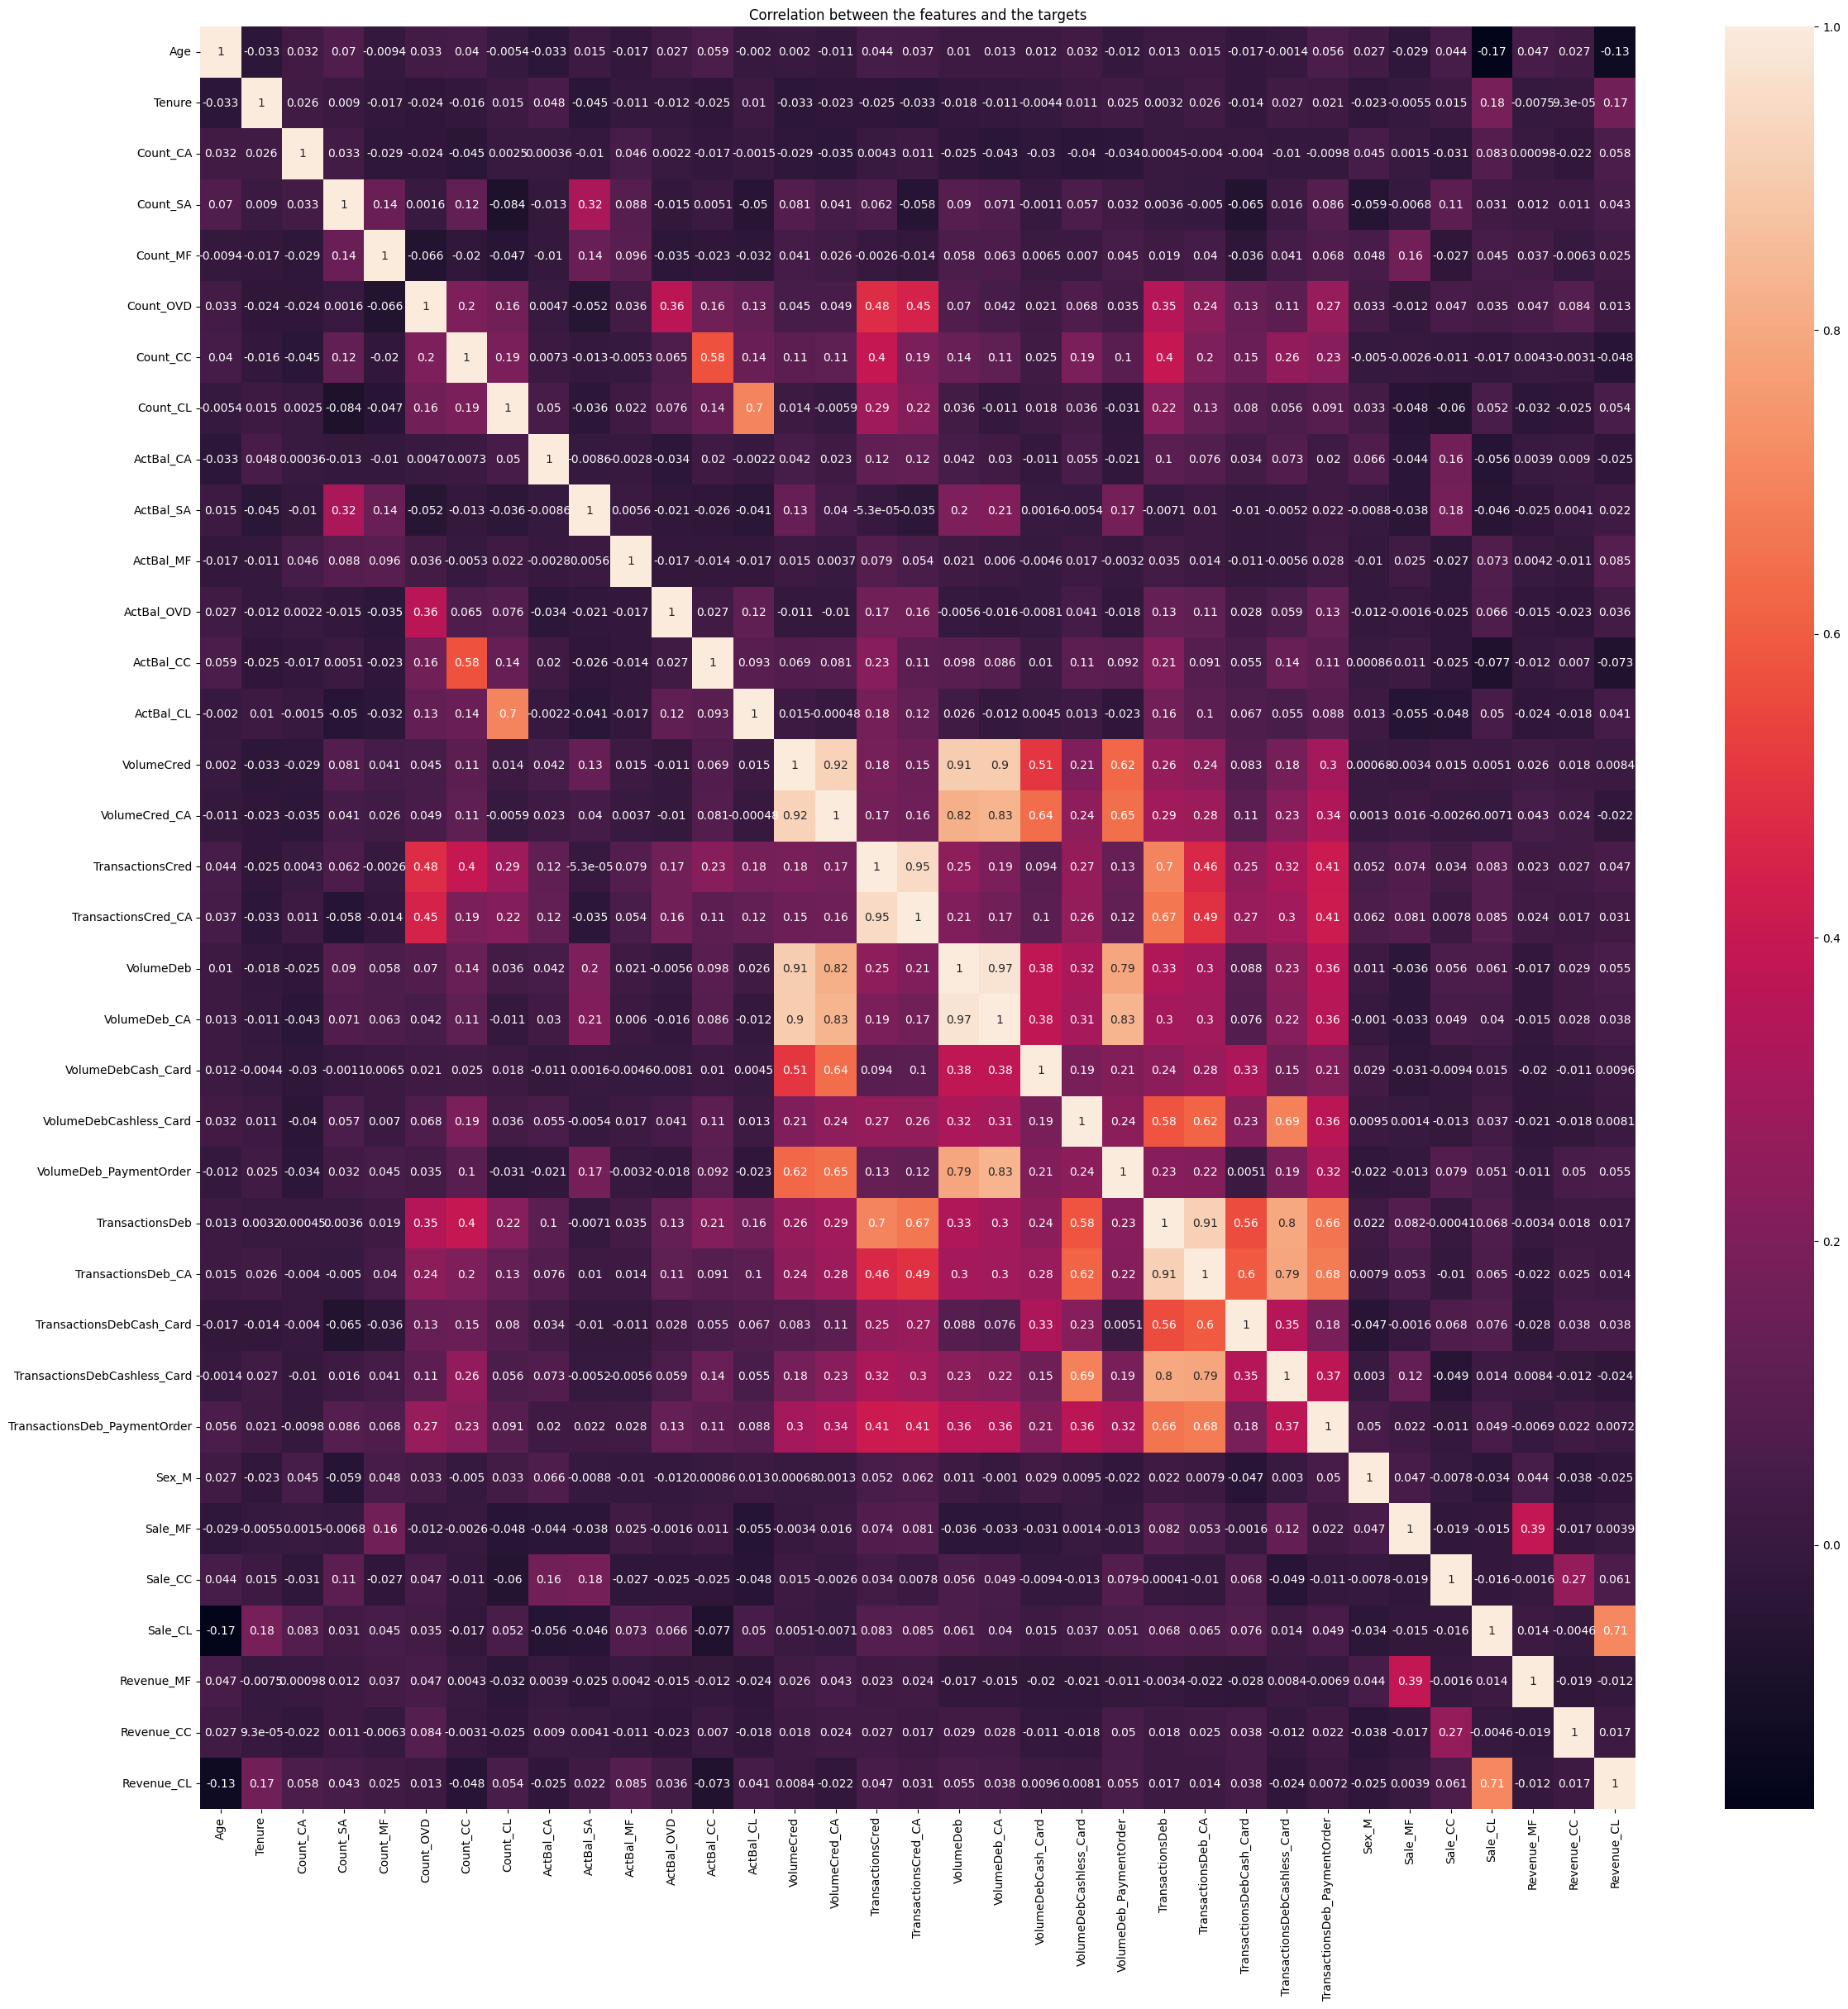

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Perform correlation analysis between the numeric features and the targets, to check if feature selection can be carried out.
df_numeric = df_modeling.drop(['Client'], axis=1).astype('float32')
corr = df_numeric.corr()
fig, ax = plt.subplots(figsize=(28, 28))
g = sns.heatmap(corr, ax=ax, annot=True)
ax.set_title("Correlation between the features and the targets")

In [59]:
# Enrich the data by creating new features

df_enriched_features = df_encoded_Soc_Products_Flow.copy()

# Create flag features for different accounts
df_enriched_features['has_Count_SA'] = np.where(df_enriched_features['Count_SA'] > 0, 1, 0)
df_enriched_features['has_Count_MF'] = np.where(df_enriched_features['Count_MF'] > 0, 1, 0)
df_enriched_features['has_Count_CL'] = np.where(df_enriched_features['Count_CL'] > 0, 1, 0)

# Create average balance features for different accounts
df_enriched_features['avgBal_SA'] = np.where(df_enriched_features['Count_SA'] == 0, 0, df_enriched_features['ActBal_SA'] / df_enriched_features['Count_SA'])
df_enriched_features['avgBal_MF'] = np.where(df_enriched_features['Count_MF'] == 0, 0, df_enriched_features['ActBal_MF'] / df_enriched_features['Count_MF'])
df_enriched_features['avgBal_CL'] = np.where(df_enriched_features['Count_CL'] == 0, 0, df_enriched_features['ActBal_CL'] / df_enriched_features['Count_CL'])

# Create flag features for different types of transactions
df_enriched_features['has_TransactionsCred'] = np.where(df_enriched_features['TransactionsCred'] > 0, 1, 0)
df_enriched_features['has_TransactionsCred_CA'] = np.where(df_enriched_features['TransactionsCred_CA'] > 0, 1, 0)
df_enriched_features['has_TransactionsCred_nonCA'] = np.where((df_enriched_features['TransactionsCred'] > 0) \
                                                  & (df_enriched_features['TransactionsCred'] > df_enriched_features['TransactionsCred_CA']), 1, 0)
df_enriched_features['has_TransactionsDeb'] = np.where(df_enriched_features['TransactionsDeb'] > 0, 1, 0)
df_enriched_features['has_TransactionsDeb_nonCA'] = np.where((df_enriched_features['TransactionsDeb'] > 0) \
                                                  & (df_enriched_features['TransactionsDeb'] > df_enriched_features['TransactionsDeb_CA']), 1, 0)
df_enriched_features['has_TransactionsDebCash'] = np.where(df_enriched_features['TransactionsDebCash_Card'] > 0, 1, 0)
df_enriched_features['has_TransactionsDebCashless'] = np.where(df_enriched_features['TransactionsDebCashless_Card'] > 0, 1, 0)
df_enriched_features['has_PaymentOrder'] = np.where(df_enriched_features['TransactionsDeb_PaymentOrder'] > 0, 1, 0)

# Create average transaction turnover features
df_enriched_features['avg_VolumeCred'] = np.where(df_enriched_features['TransactionsCred'] == 0, 0, df_enriched_features['VolumeCred'] / df_enriched_features['TransactionsCred'])
df_enriched_features['avg_VolumeCred_CA'] = np.where(df_enriched_features['TransactionsCred_CA'] == 0, 0, df_enriched_features['VolumeCred_CA'] / df_enriched_features['TransactionsCred_CA'])
df_enriched_features['avg_VolumeDeb'] = np.where(df_enriched_features['TransactionsDeb'] == 0, 0, df_enriched_features['VolumeDeb'] / df_enriched_features['TransactionsDeb'])
df_enriched_features['avg_VolumeDeb_CA'] = np.where(df_enriched_features['TransactionsDeb_CA'] == 0, 0, df_enriched_features['VolumeDeb_CA'] / df_enriched_features['TransactionsDeb_CA'])
df_enriched_features['avg_VolumeDebCash'] = np.where(df_enriched_features['TransactionsDebCash_Card'] == 0, 0, df_enriched_features['VolumeDebCash_Card'] / df_enriched_features['TransactionsDebCash_Card'])
df_enriched_features['avg_VolumeDebCashless'] = np.where(df_enriched_features['TransactionsDebCashless_Card'] == 0, 0, df_enriched_features['VolumeDebCashless_Card'] / df_enriched_features['TransactionsDebCashless_Card'])
df_enriched_features['avg_VolumeDeb_PaymentOrder'] = np.where(df_enriched_features['TransactionsDeb_PaymentOrder'] == 0, 0, df_enriched_features['VolumeDeb_PaymentOrder'] / df_enriched_features['TransactionsDeb_PaymentOrder'])

# Create difference features
df_enriched_features['VolumeCred_nonCA'] = df_enriched_features['VolumeCred'] - df_enriched_features['VolumeCred_CA']
df_enriched_features['VolumeDeb_nonCA'] = df_enriched_features['VolumeDeb'] - df_enriched_features['VolumeDeb_CA']

df_modeling_enriched = pd.merge(left=df_enriched_features, right=df_Sales_Revenues, left_on='Client', right_on='Client')


# Create the dataset for prediction
df_prediction_enriched = pd.merge(left=df_enriched_features, right=df_Sales_Revenues, how='outer', 
                                    left_on='Client', right_on='Client', indicator = True)  
df_prediction_enriched = df_prediction_enriched[(df_prediction_enriched._merge=='left_only')].drop(['_merge', 
                                                                                                    'Sale_MF',
                                                                                                    'Sale_CC',
                                                                                                    'Sale_CL',
                                                                                                    'Revenue_MF',
                                                                                                    'Revenue_CC',
                                                                                                    'Revenue_CL'], axis=1)


Text(0.5, 1.0, 'Correlation between the created features and the targets')

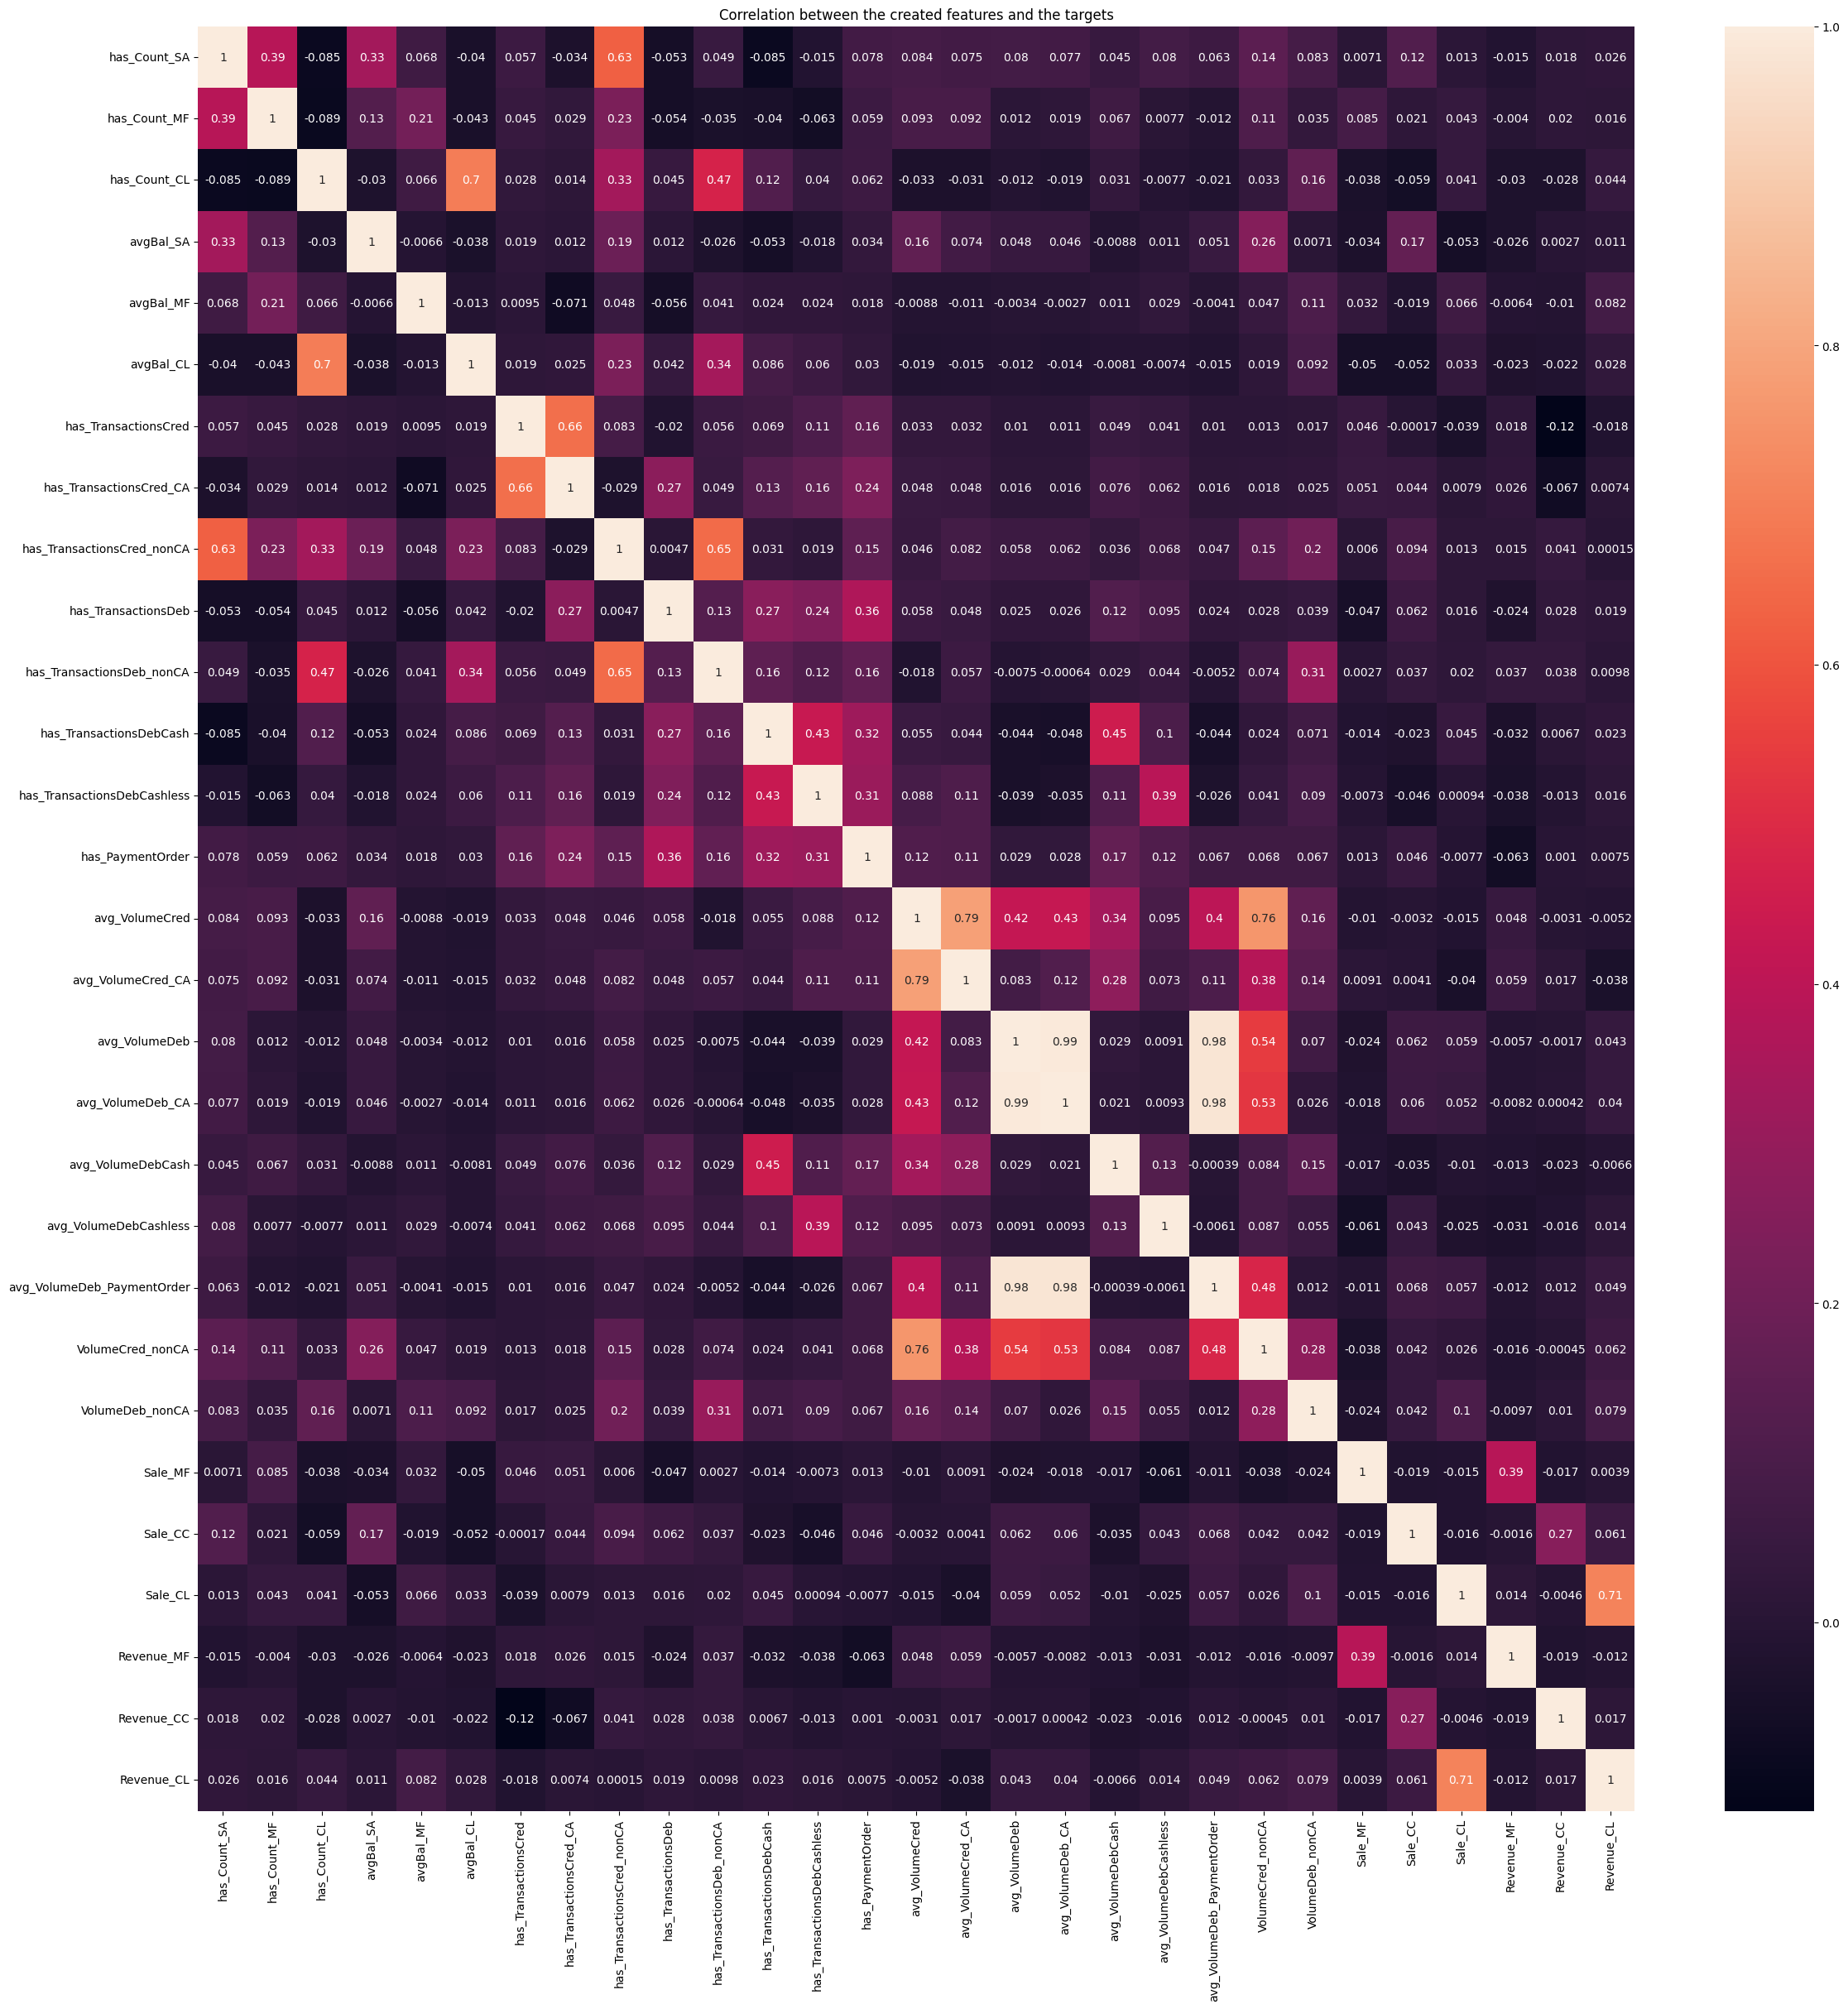

In [60]:
# Investigate the correlation between the created features and the targets

df_new_features = df_modeling_enriched.drop(['Client',
                             'Sex_M',
                             'Age',
                             'Tenure',
                             'Count_CA',
                             'Count_SA',
                             'Count_MF',
                             'Count_OVD',
                             'Count_CC',
                             'Count_CL',
                             'ActBal_CA',
                             'ActBal_SA',
                             'ActBal_MF',
                             'ActBal_OVD',
                             'ActBal_CC',
                             'ActBal_CL',
                             'VolumeCred',
                             'VolumeCred_CA',
                             'TransactionsCred',
                             'TransactionsCred_CA',
                             'VolumeDeb',
                             'VolumeDeb_CA',
                             'VolumeDebCash_Card',
                             'VolumeDebCashless_Card',
                             'VolumeDeb_PaymentOrder',
                             'TransactionsDeb',
                             'TransactionsDeb_CA',
                             'TransactionsDebCash_Card',
                             'TransactionsDebCashless_Card',
                             'TransactionsDeb_PaymentOrder',], axis=1).astype('float32')
                             
corr = df_new_features.corr()
fig, ax = plt.subplots(figsize=(28, 28))
g = sns.heatmap(corr, ax=ax, annot=True)
ax.set_title("Correlation between the created features and the targets")
                             

#### <span style="color:orange">**Comments**</span>

* The correlation between the original/created features and the targets are usually low. No correlation coefficients are much higher or lowed than others.
* No numerical features are fully correlated with another.
* Therefore, based on the correlation analysis, no original/created features will be eliminated for modeling.

### Analyzing and handling Skewness in Feature Value Distribution

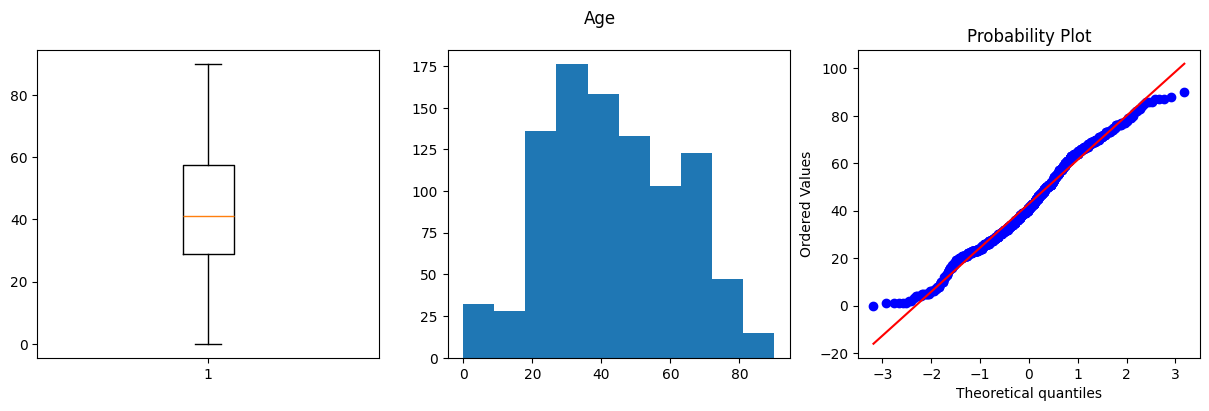

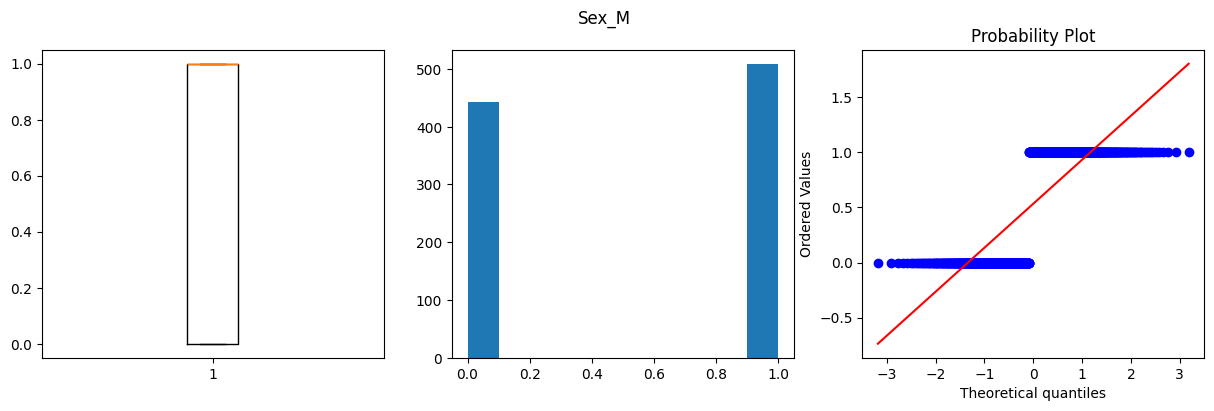

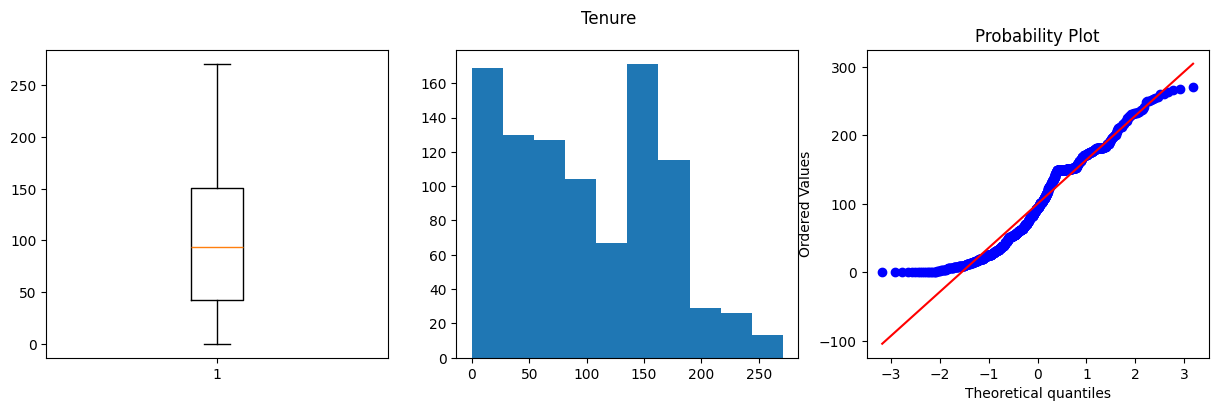

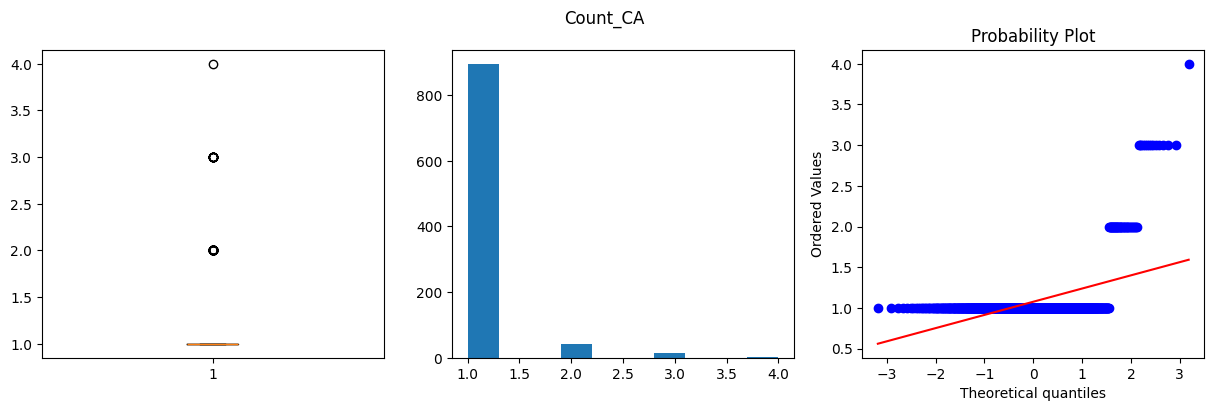

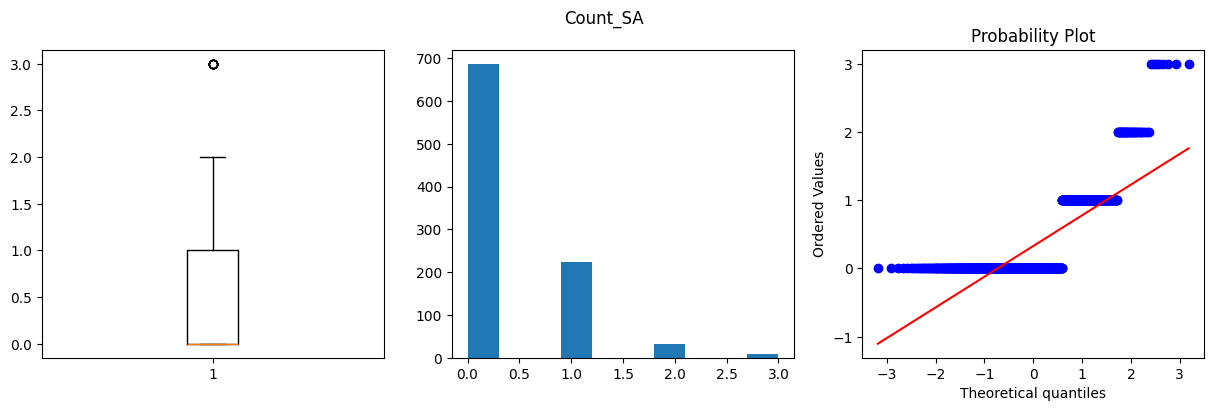

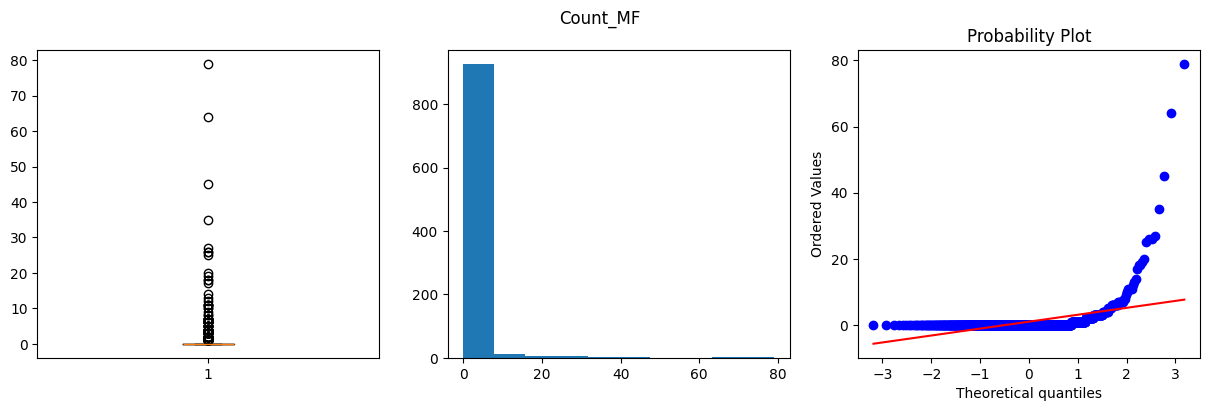

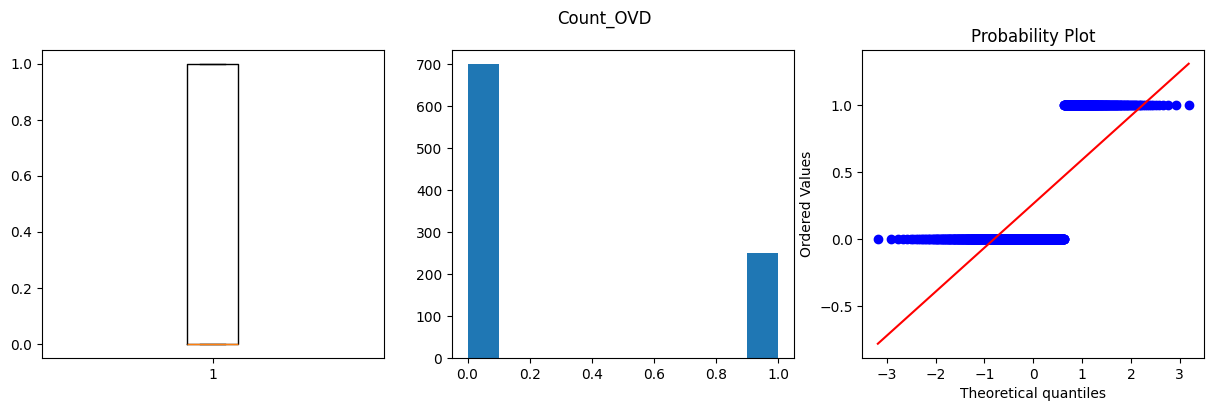

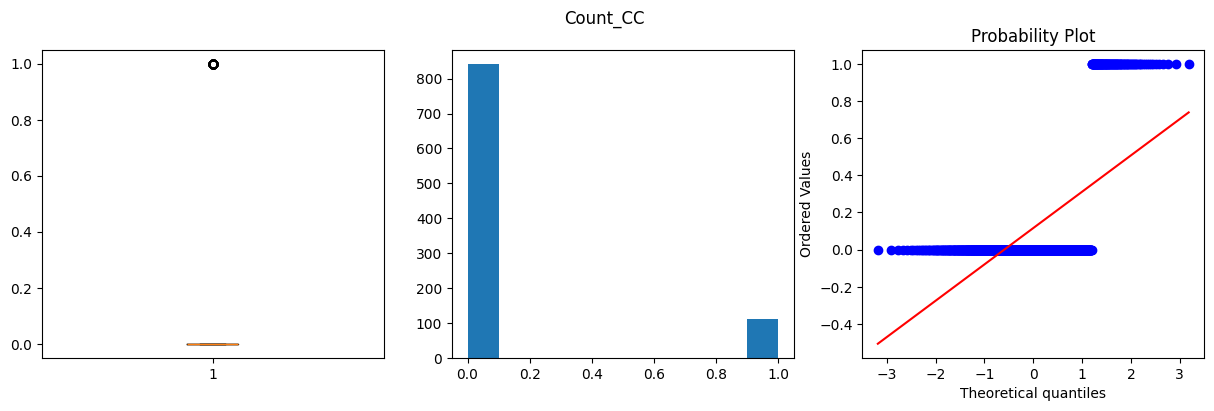

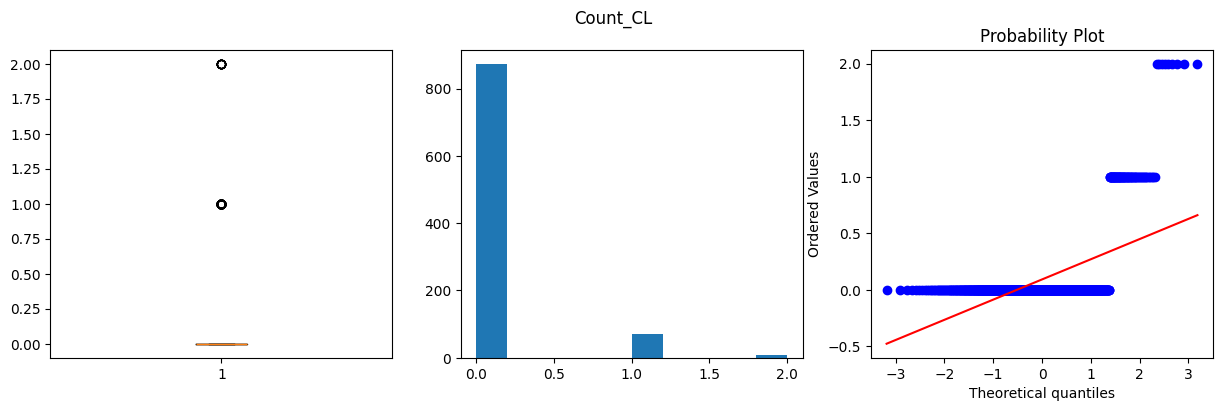

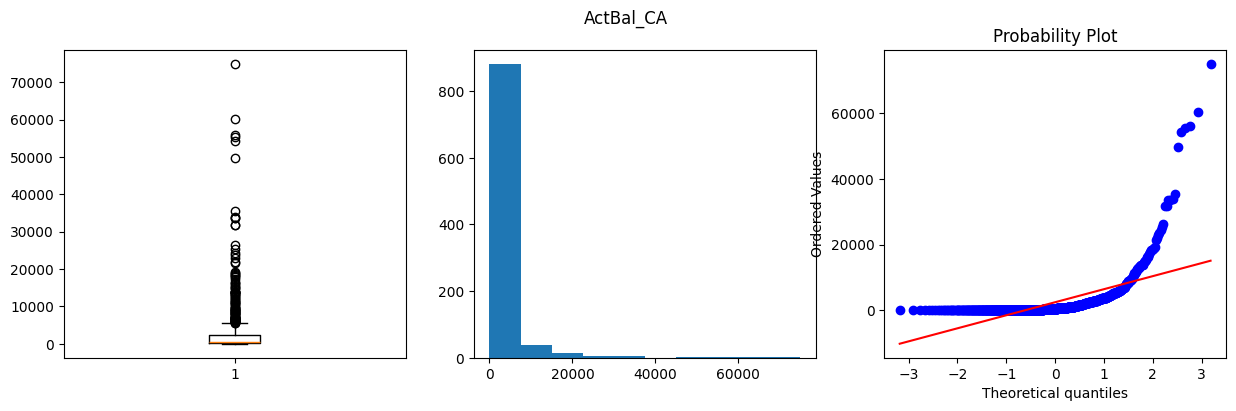

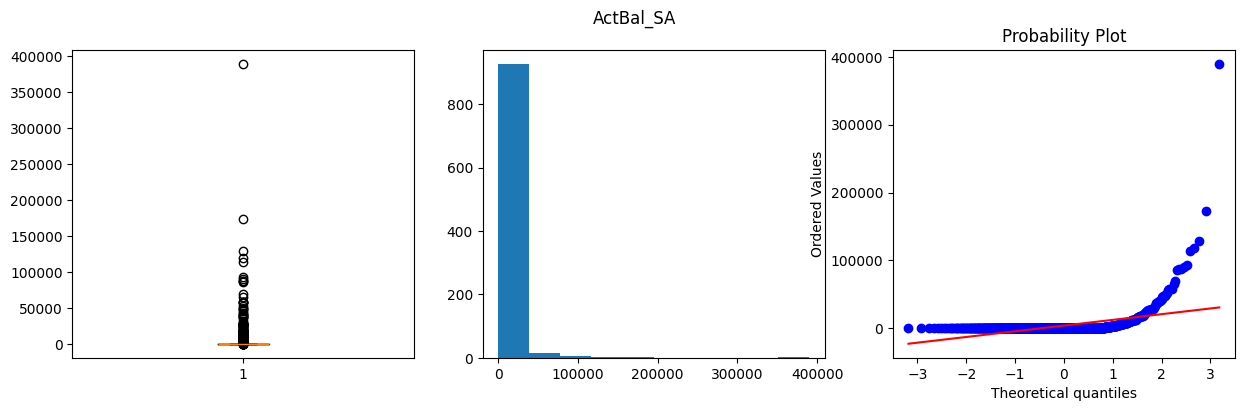

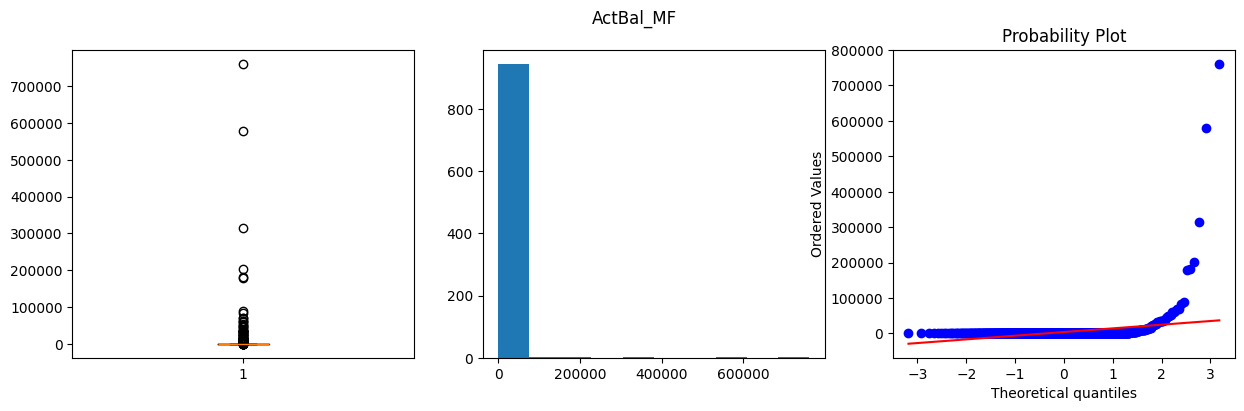

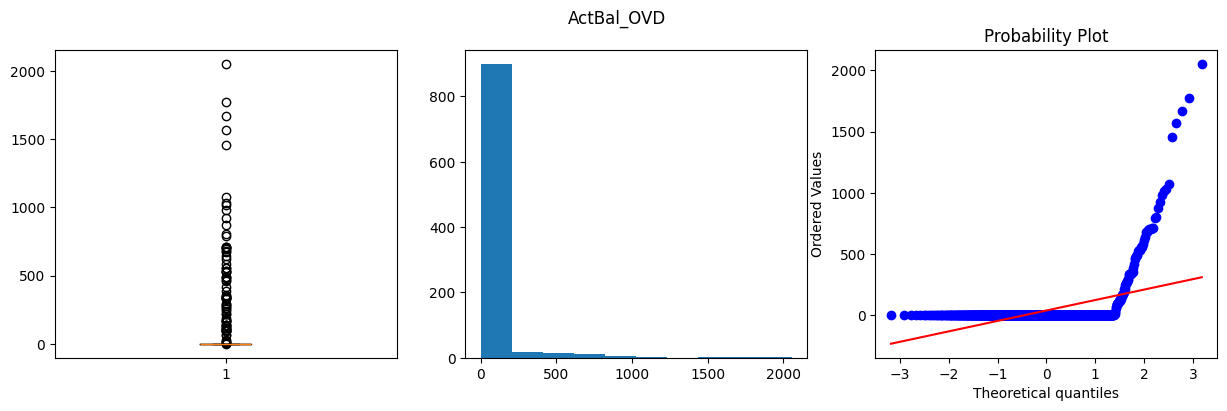

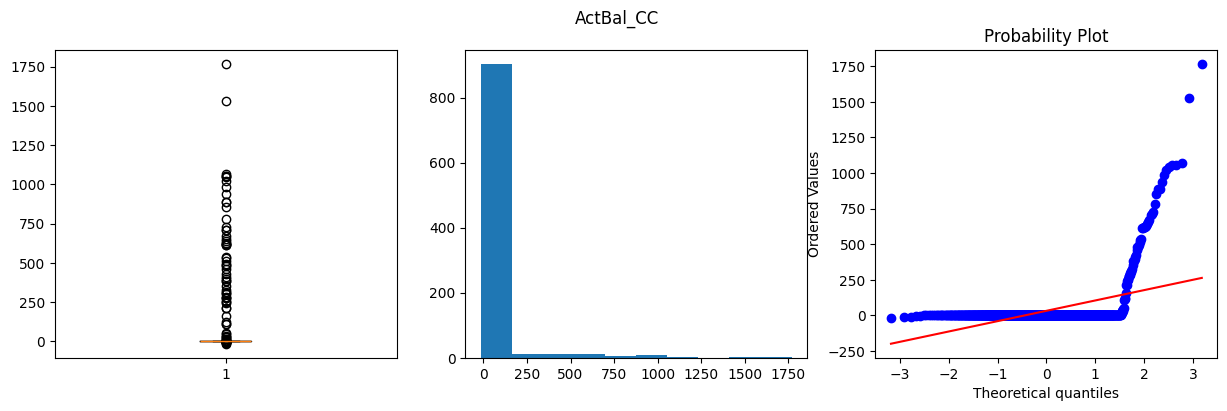

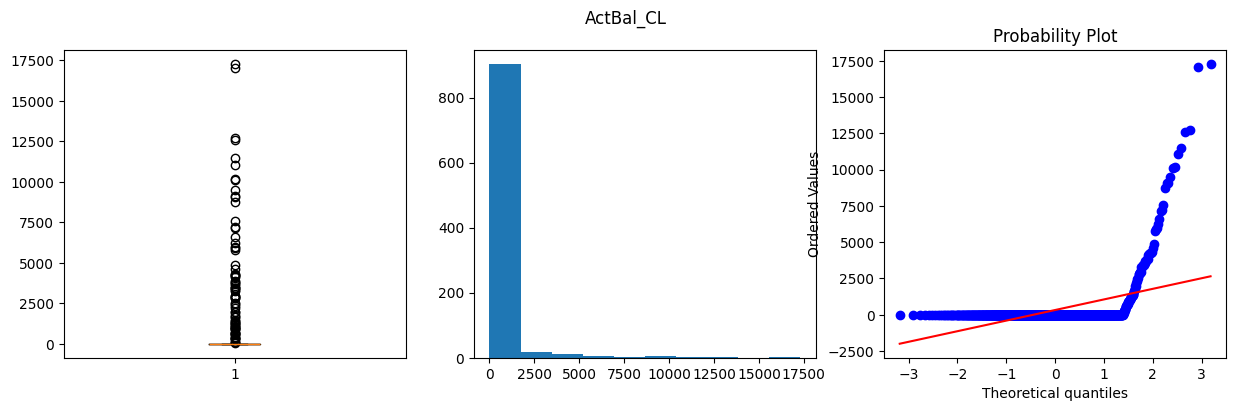

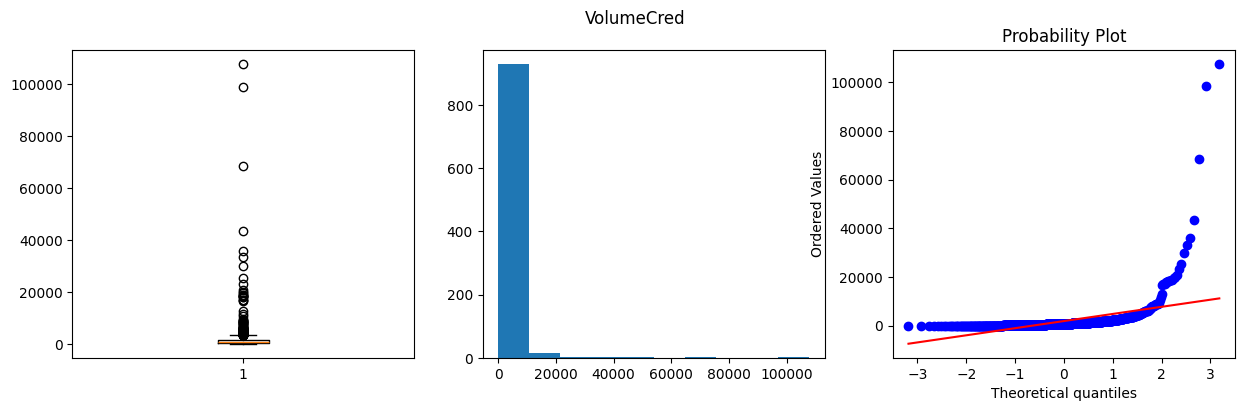

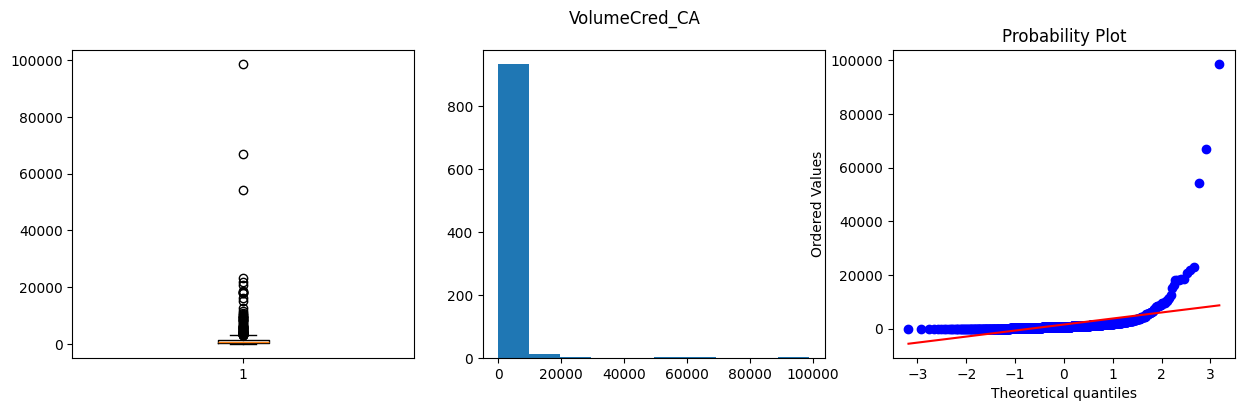

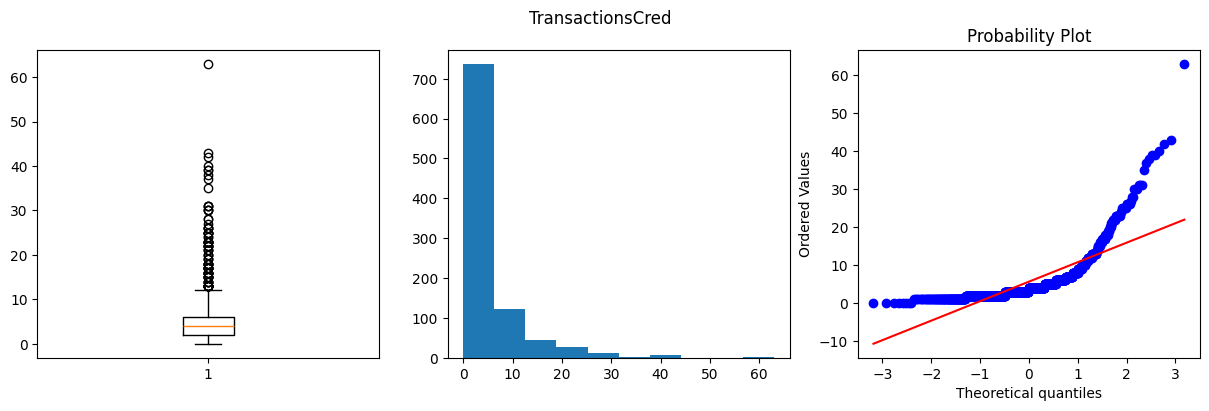

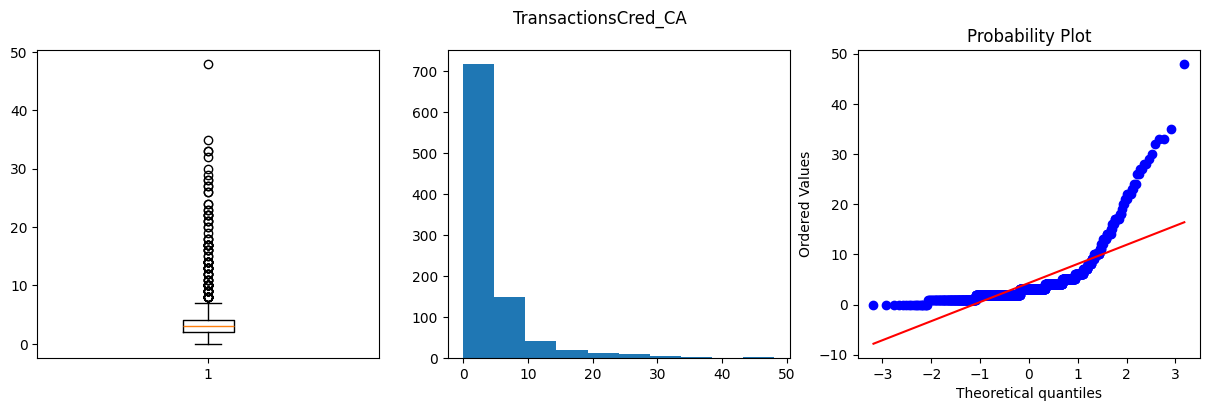

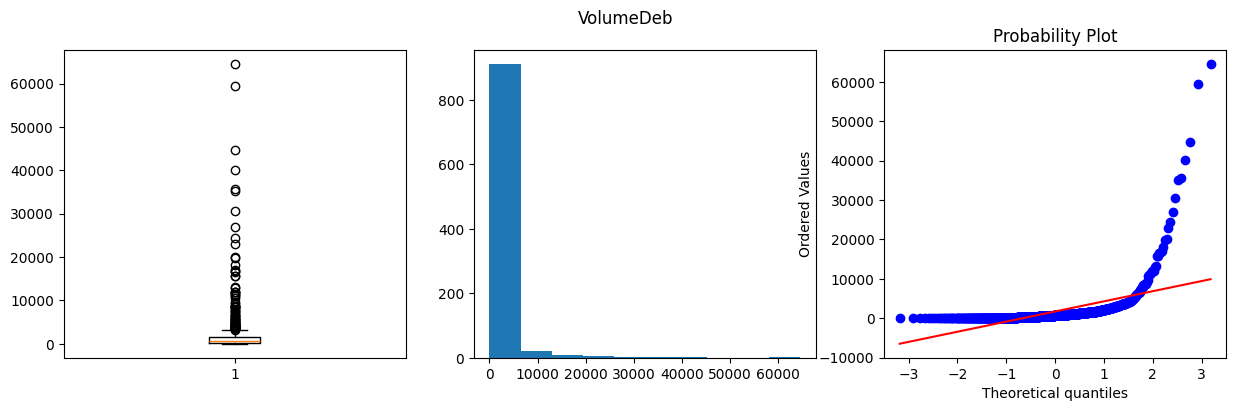

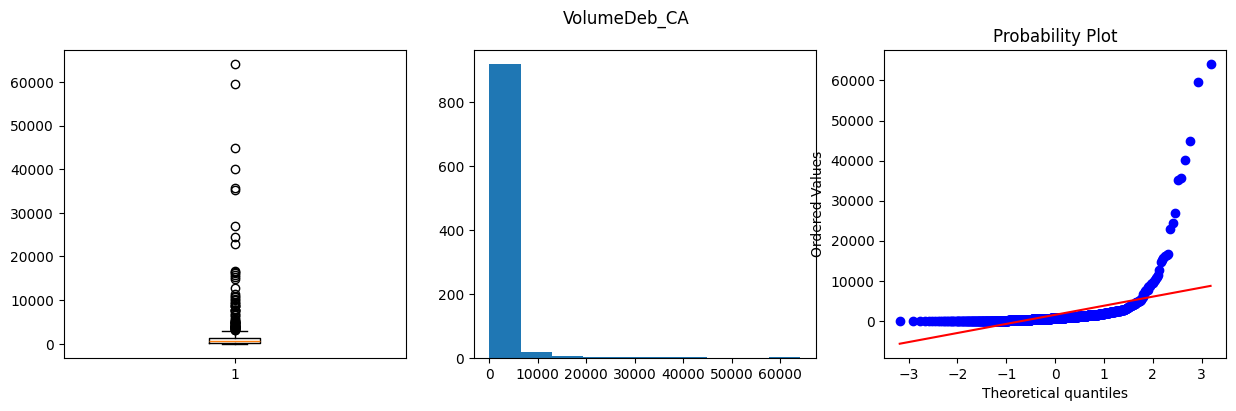

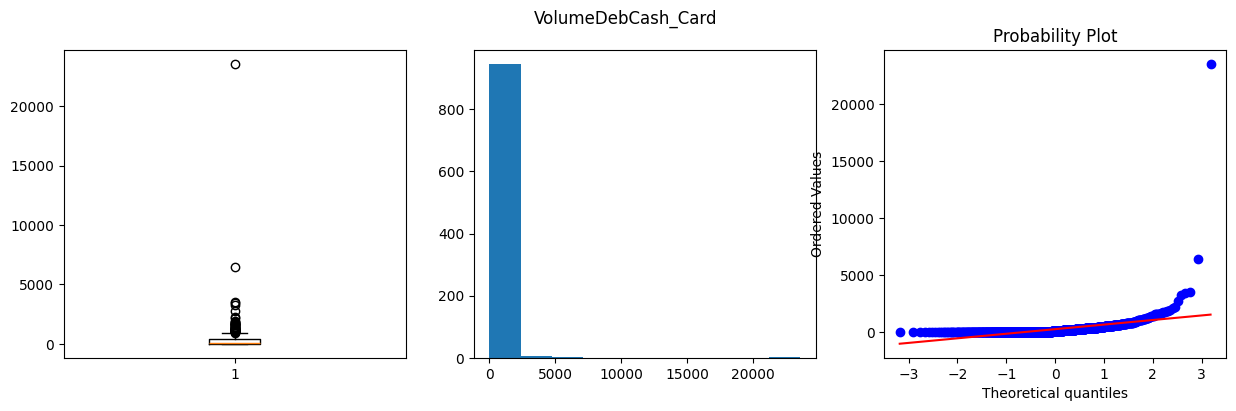

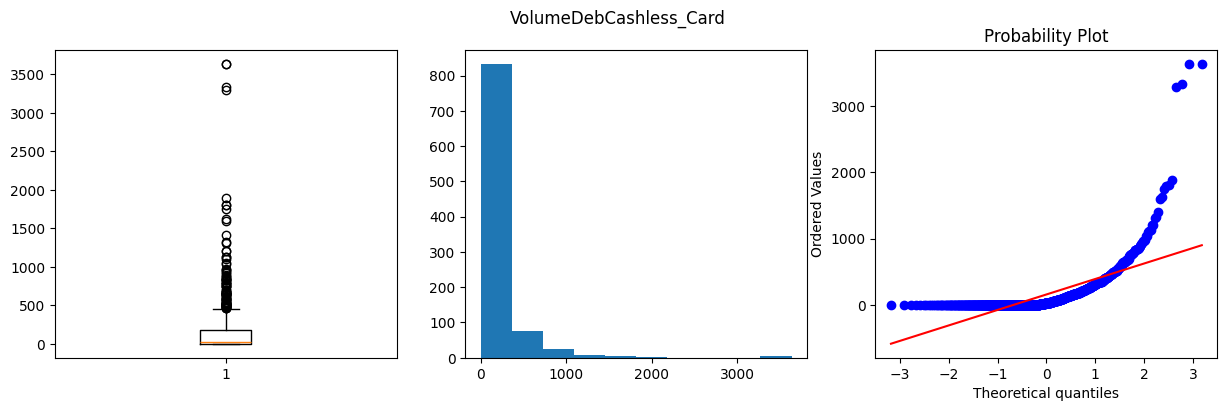

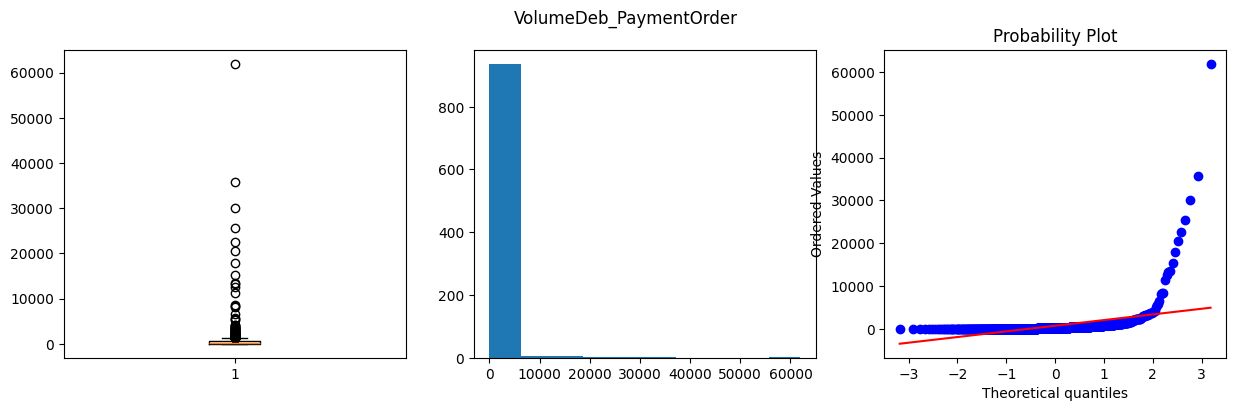

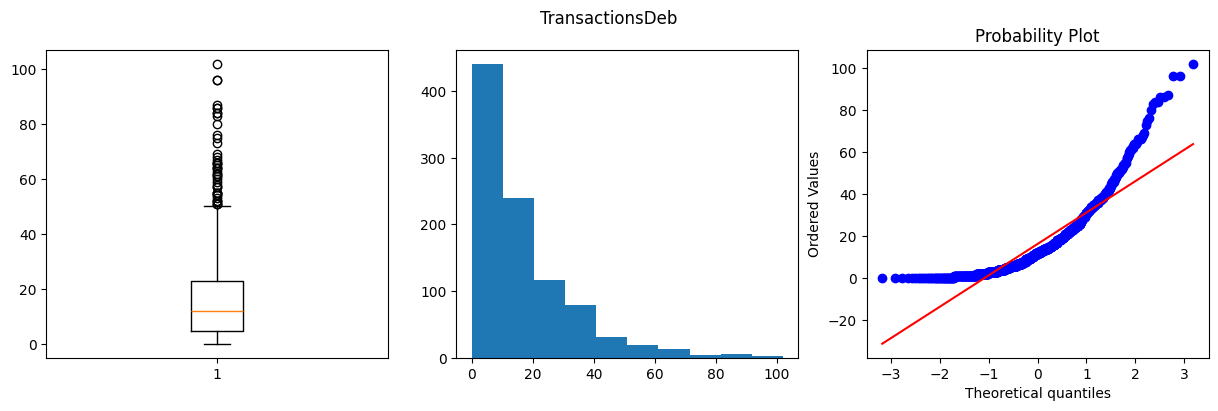

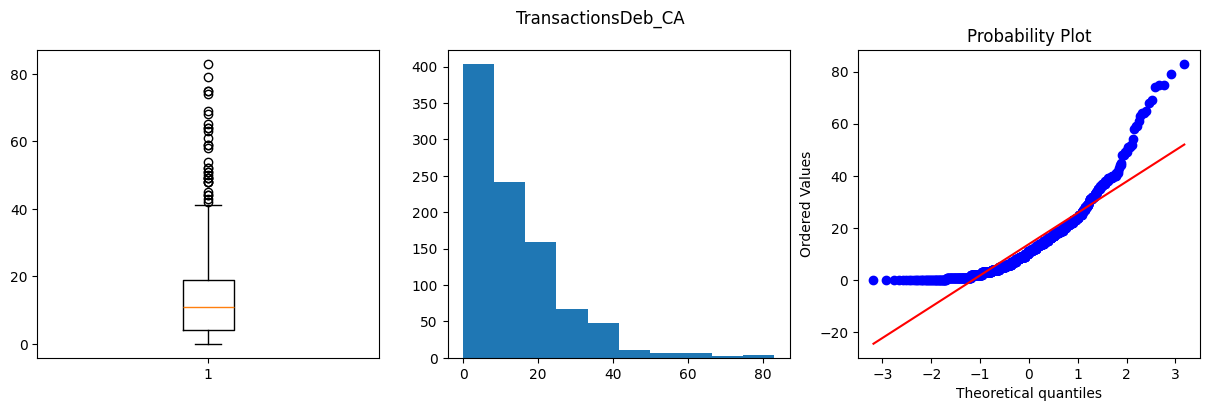

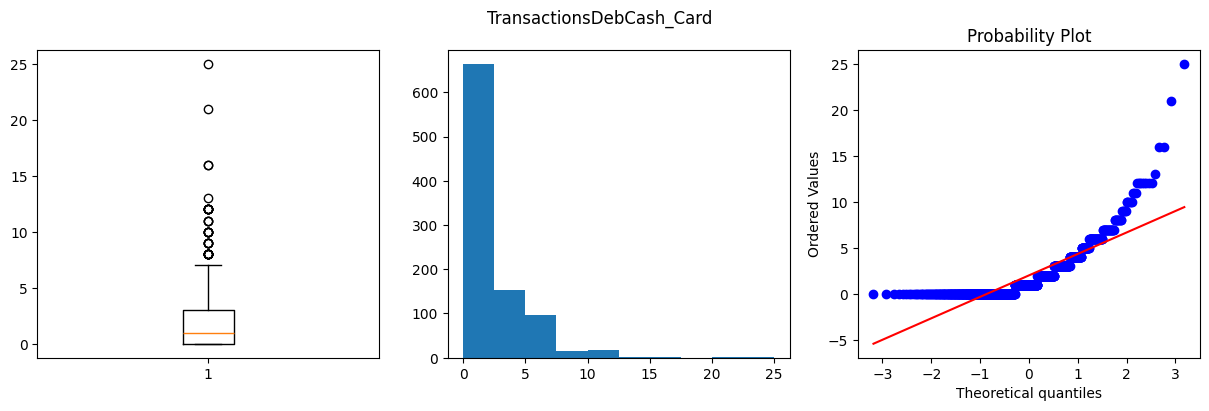

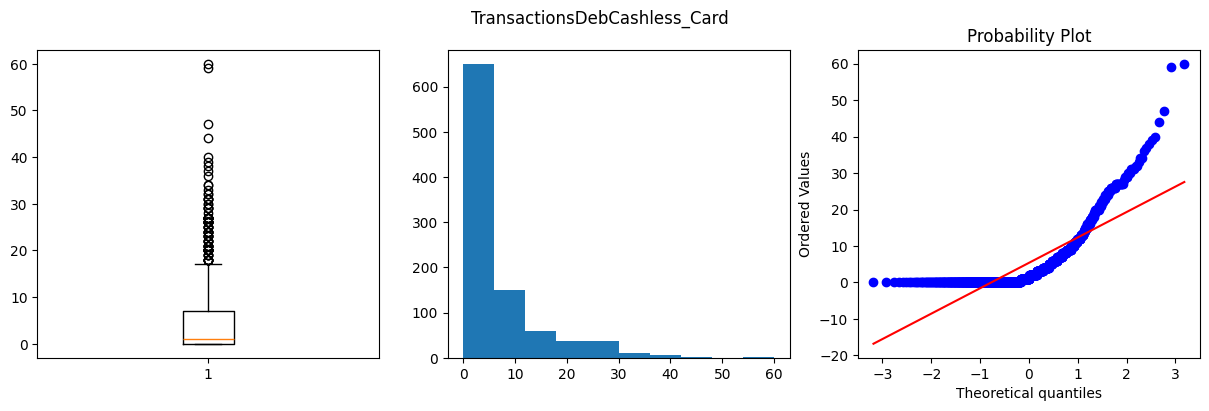

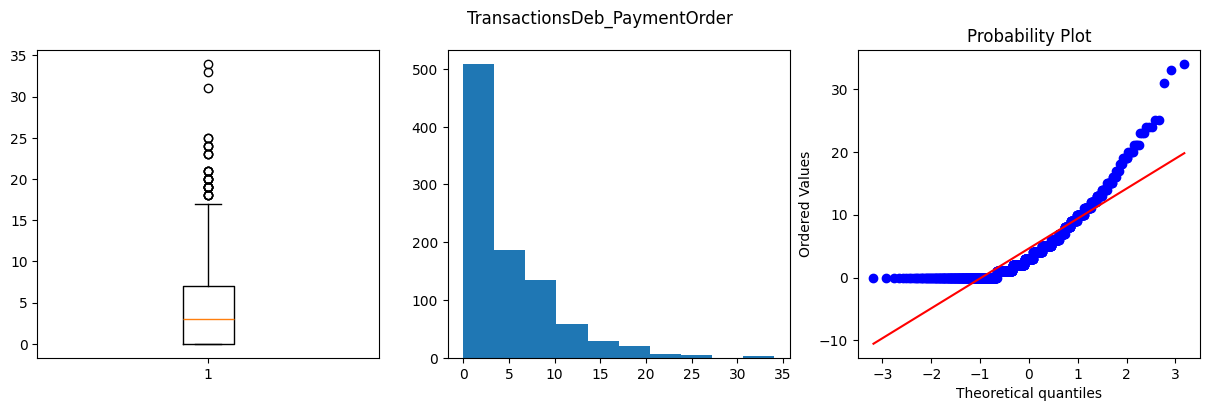

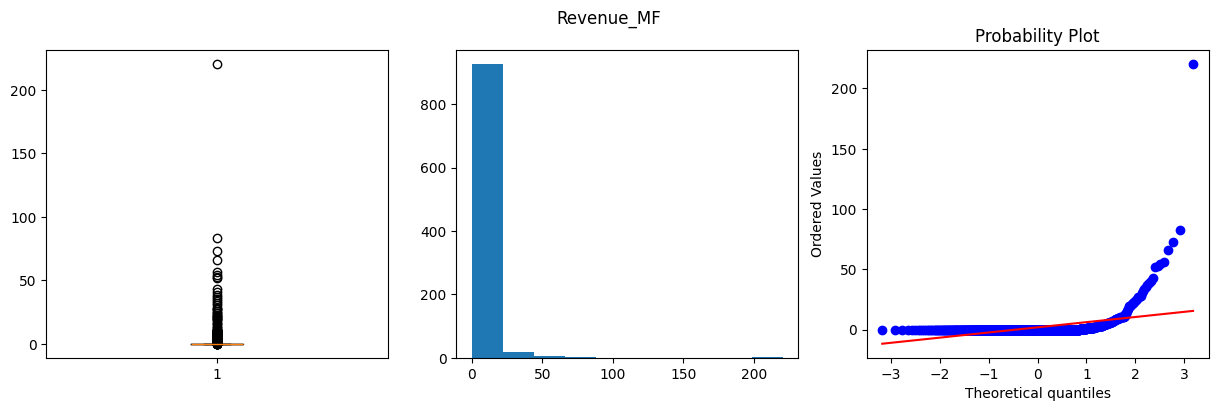

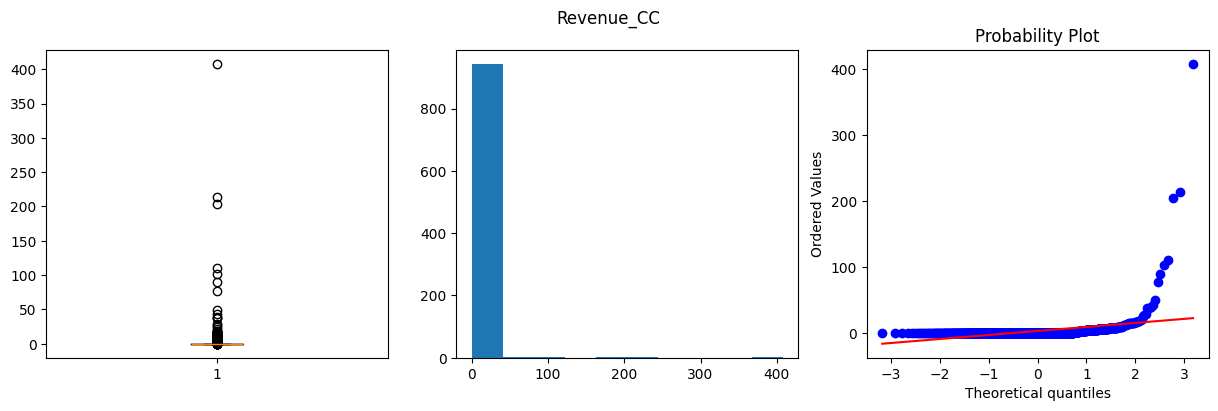

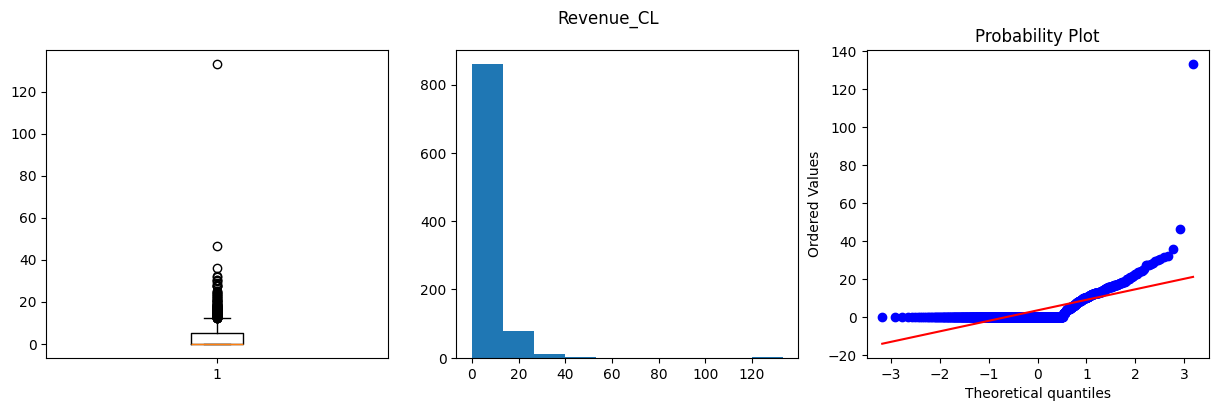

In [62]:
import scipy.stats as stats

cols = [ 'Age',
         'Sex_M',
         'Tenure',
         'Count_CA',
         'Count_SA',
         'Count_MF',
         'Count_OVD',
         'Count_CC',
         'Count_CL',
         'ActBal_CA',
         'ActBal_SA',
         'ActBal_MF',
         'ActBal_OVD',
         'ActBal_CC',
         'ActBal_CL',
         'VolumeCred',
         'VolumeCred_CA',
         'TransactionsCred',
         'TransactionsCred_CA',
         'VolumeDeb',
         'VolumeDeb_CA',
         'VolumeDebCash_Card',
         'VolumeDebCashless_Card',
         'VolumeDeb_PaymentOrder',
         'TransactionsDeb',
         'TransactionsDeb_CA',
         'TransactionsDebCash_Card',
         'TransactionsDebCashless_Card',
         'TransactionsDeb_PaymentOrder',
         'Revenue_MF',
         'Revenue_CC',
         'Revenue_CL',]

for col in cols: 
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
    fig.suptitle(col)
    axes[0].boxplot(df_numeric[col])
    axes[1].hist(df_numeric[col])
    stats.probplot(df_numeric[col], dist='norm', plot=axes[2])
    plt.show()

#### <span style="color:orange">**Comments**</span>

The analysis shows that:
* The distribution of 'Age', 'Sex_M' and 'Tenure' are almost not skewed. 
* The distribution of the count features 'Count_CA', 'Count_SA', 'Count_MF', 'Count_OVD', 'Count_CC', and 'Count_CL' are skewed, but they are discrete features and their value ranges are quite small. 
* The distribution of the count feature 'Count_MF' is skewed and its value range is big ([0, 79]). 
* The distribution of balance features and volume features, as well as the distribution of transaction count features, are all right-skewed. 
* The min value of 'ActBal_CC' is negative, while for other features the min values are 0.

Data transformation is going to be used to deal with the skewness of feature value distribution, to make the distribution of each numerical feature close to normal distribution form. Based on the analysis, we'd apply data transformation on the following features:
* 'Count_MF',
* all the balance features
* all the transaction count features
* all the transaction volume features
* all the revenue columns

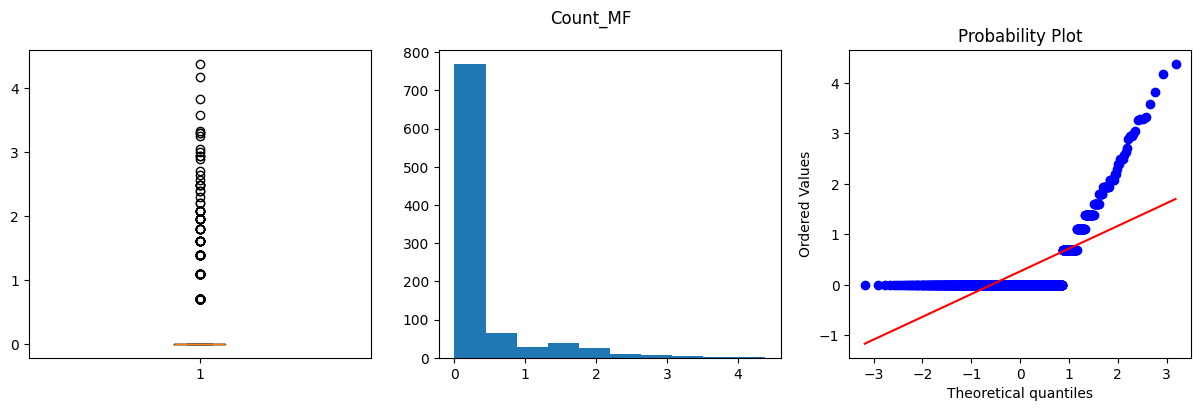

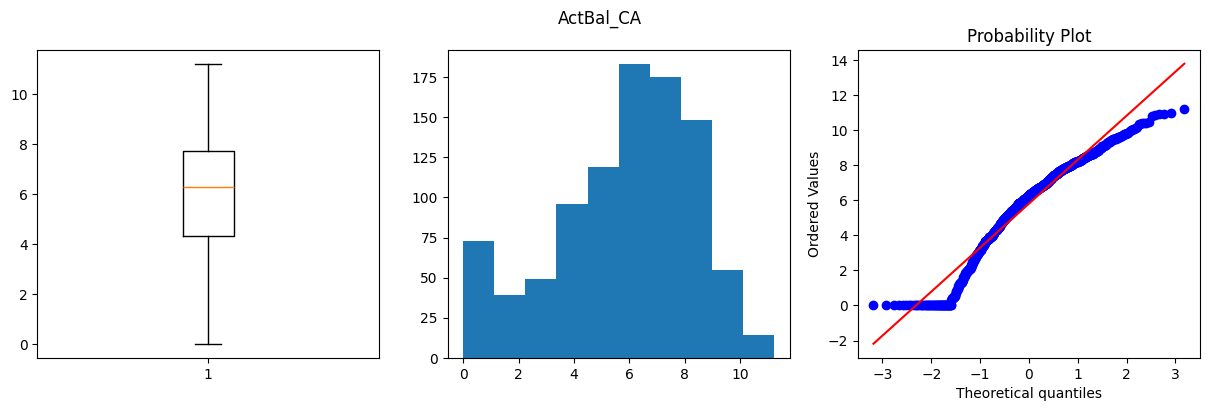

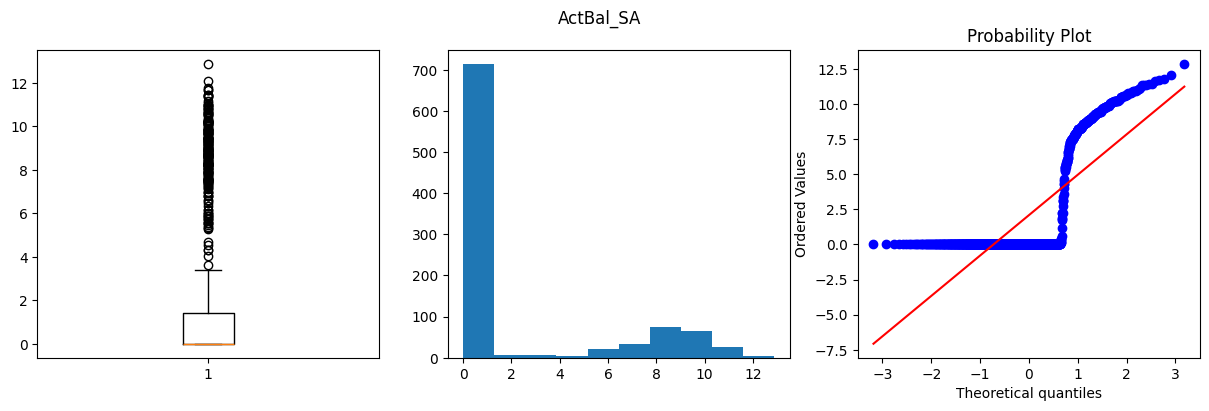

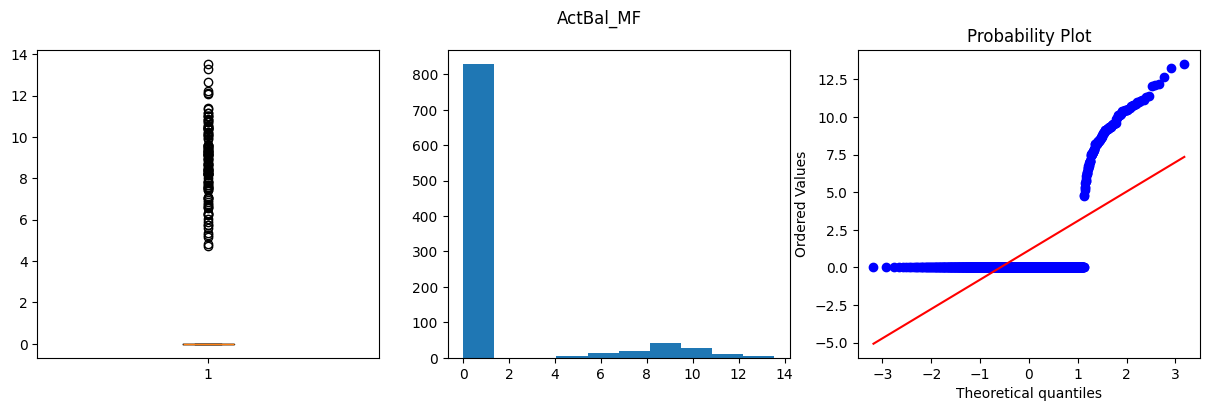

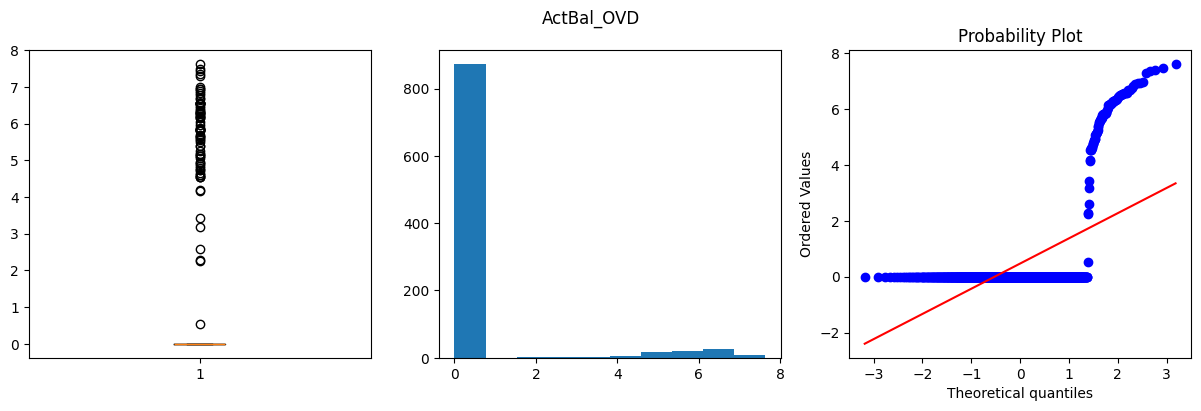

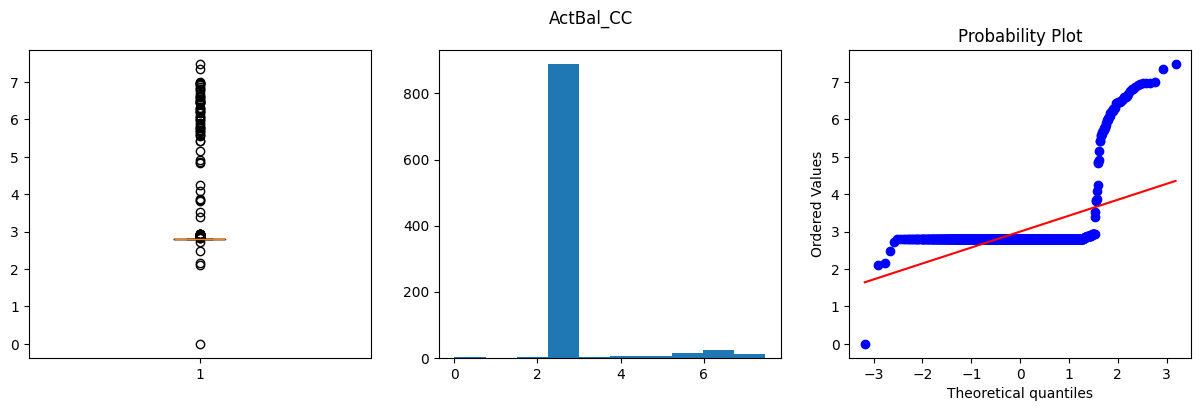

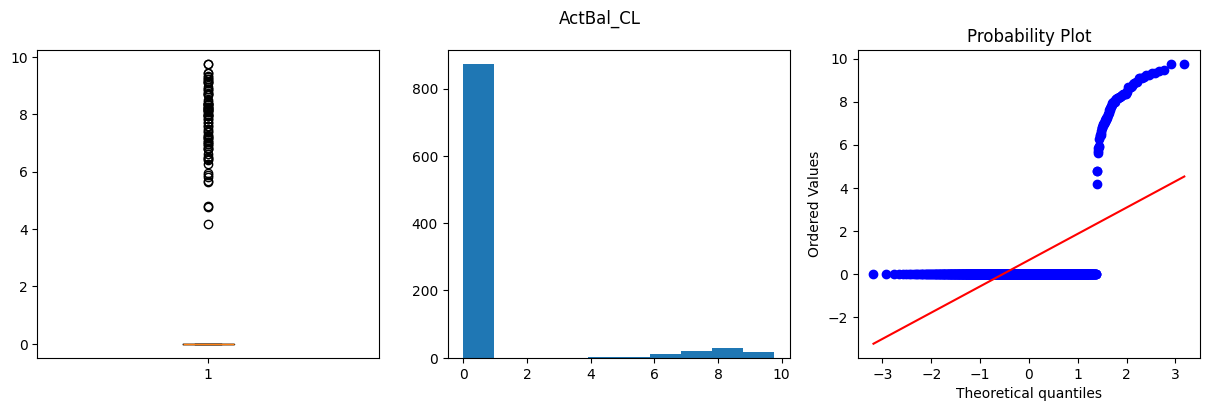

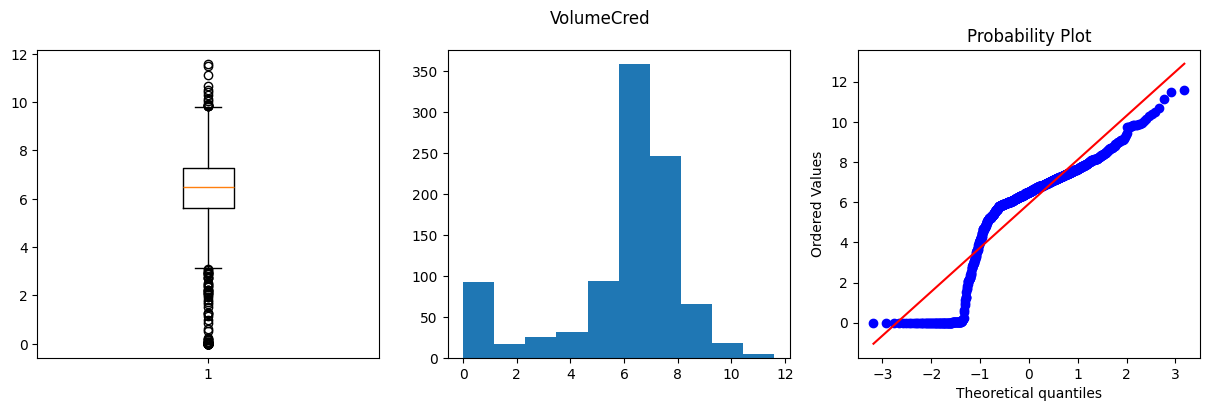

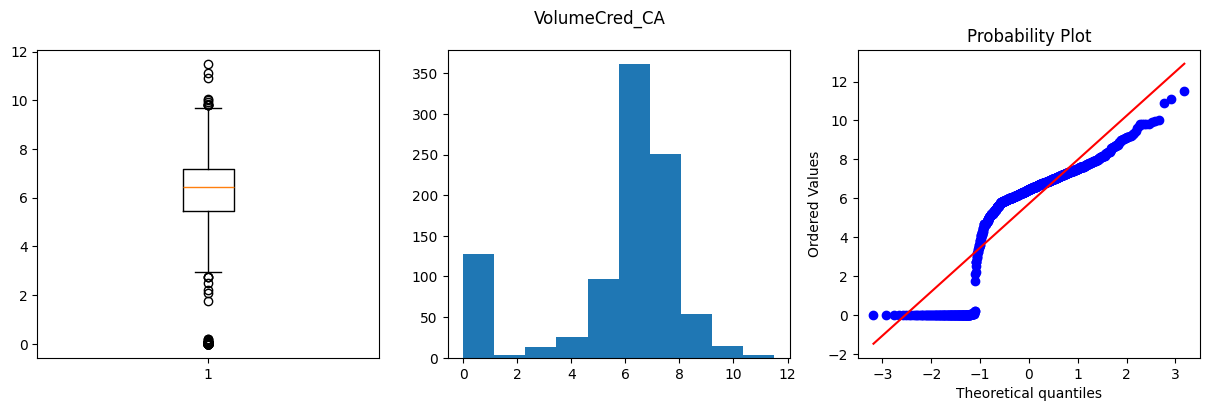

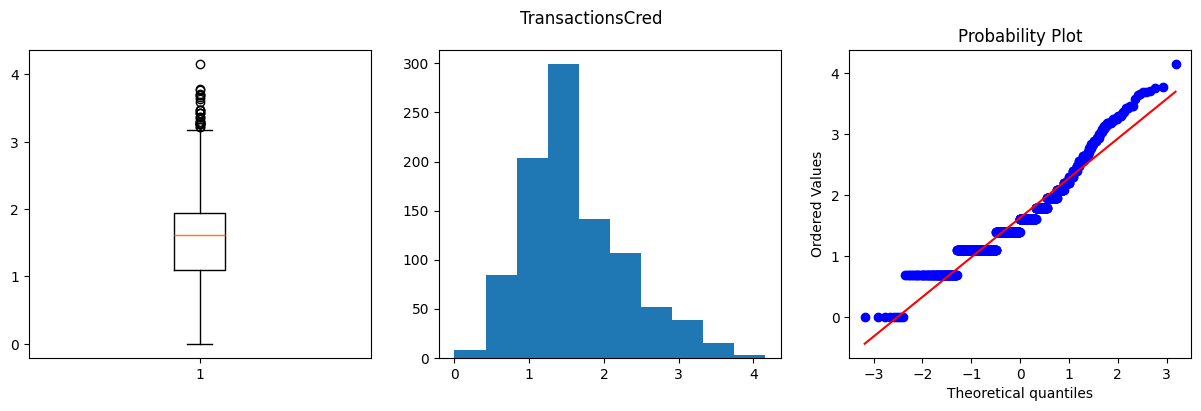

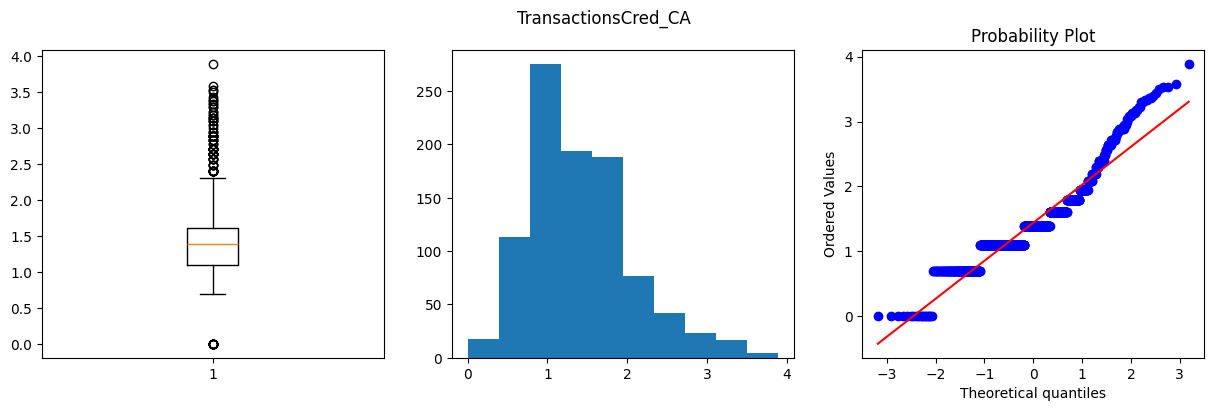

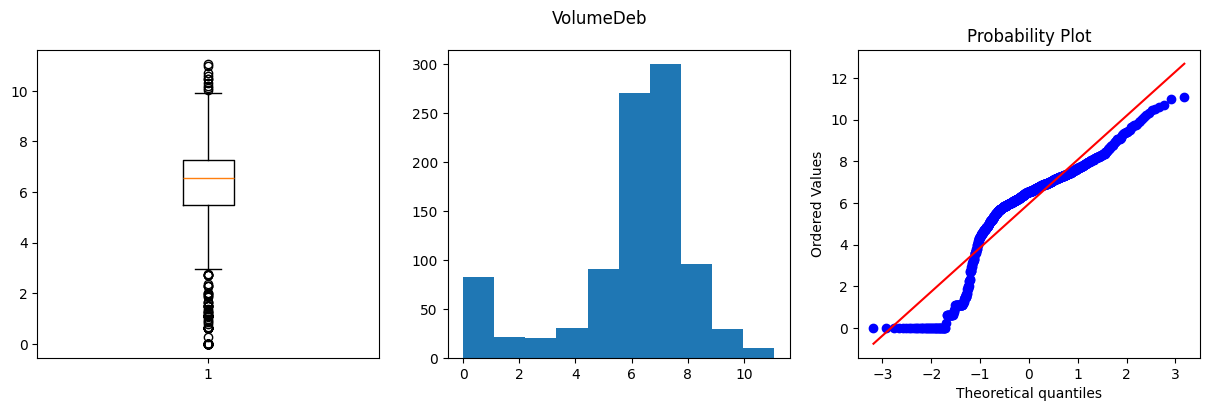

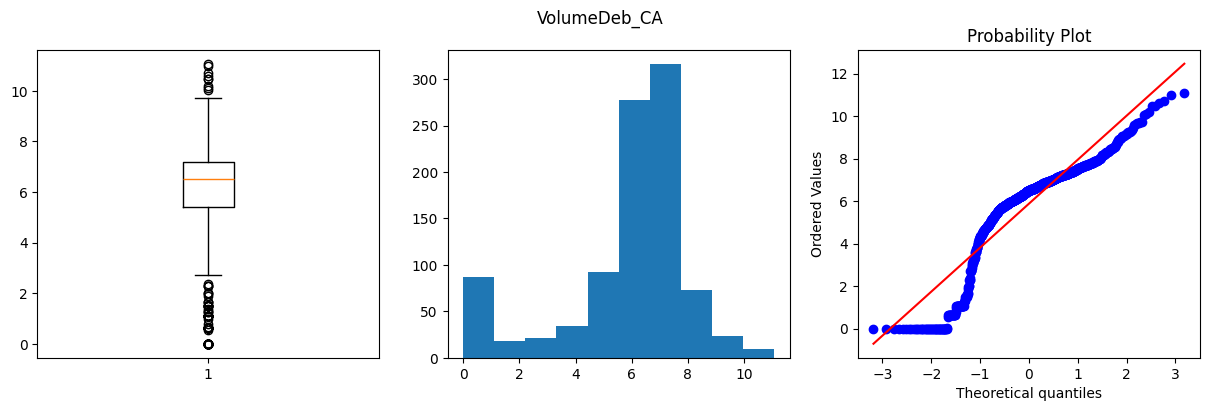

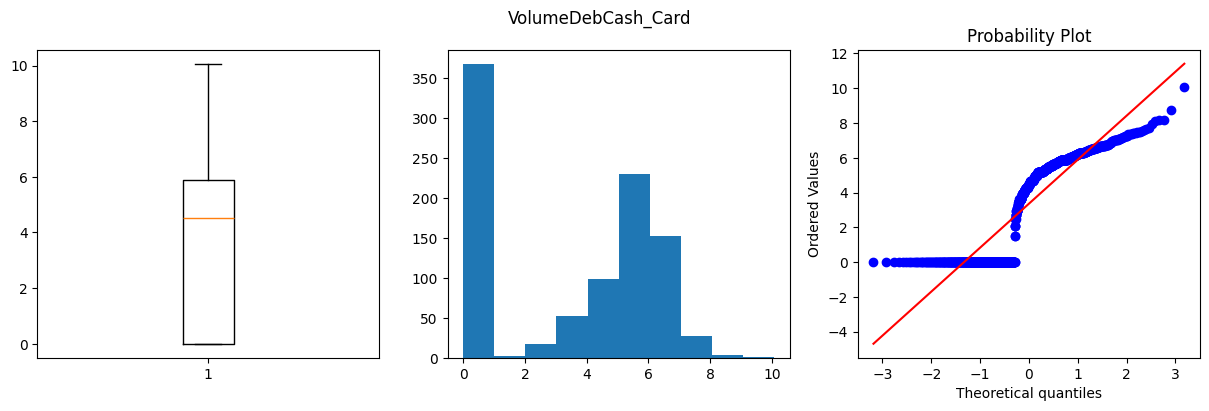

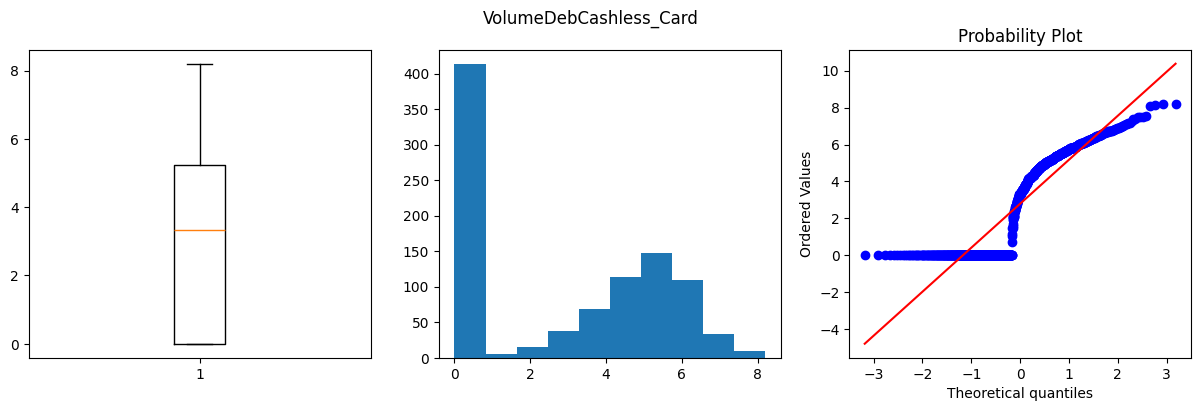

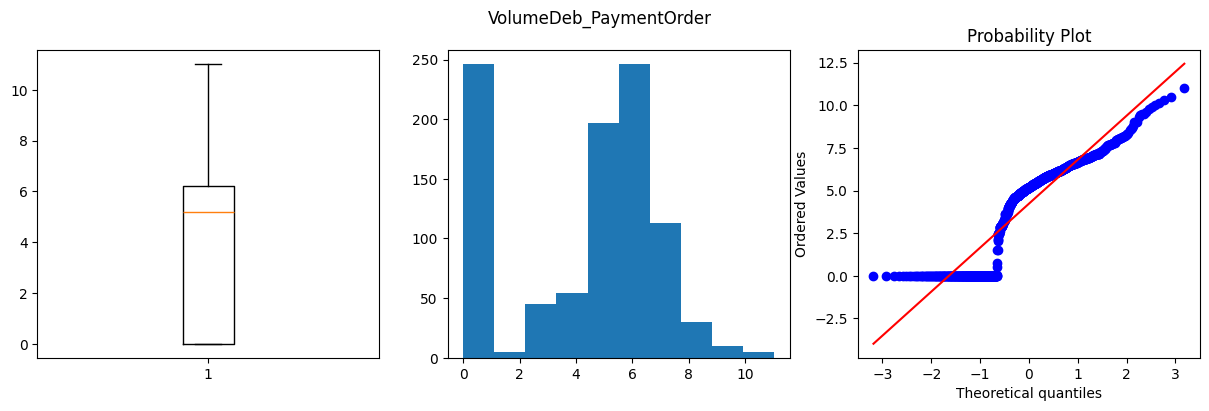

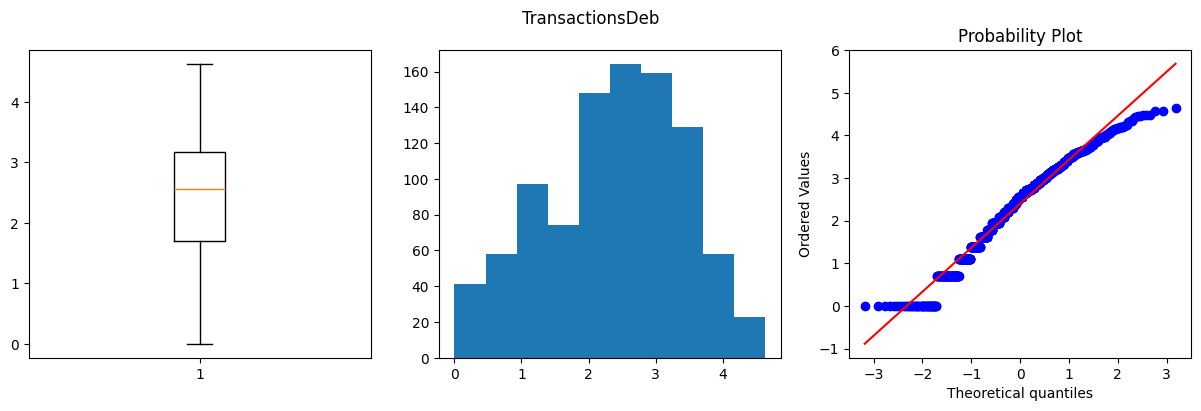

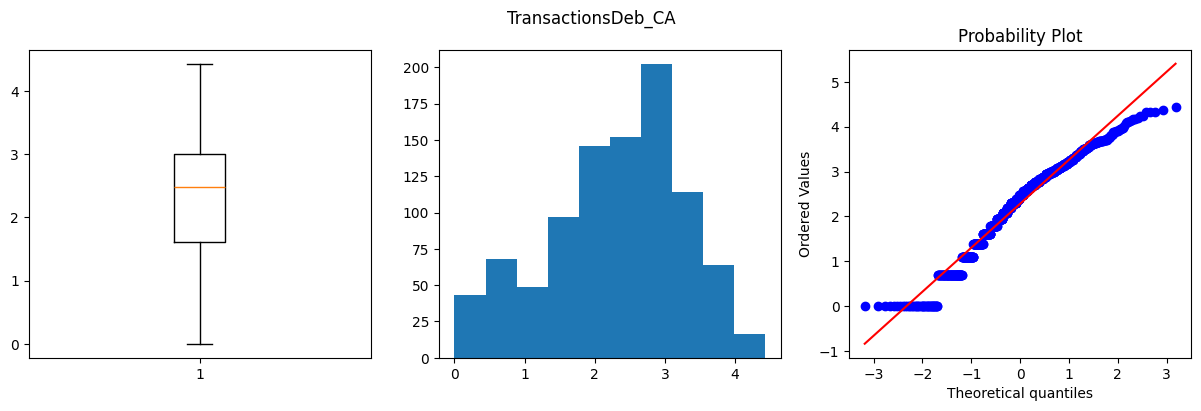

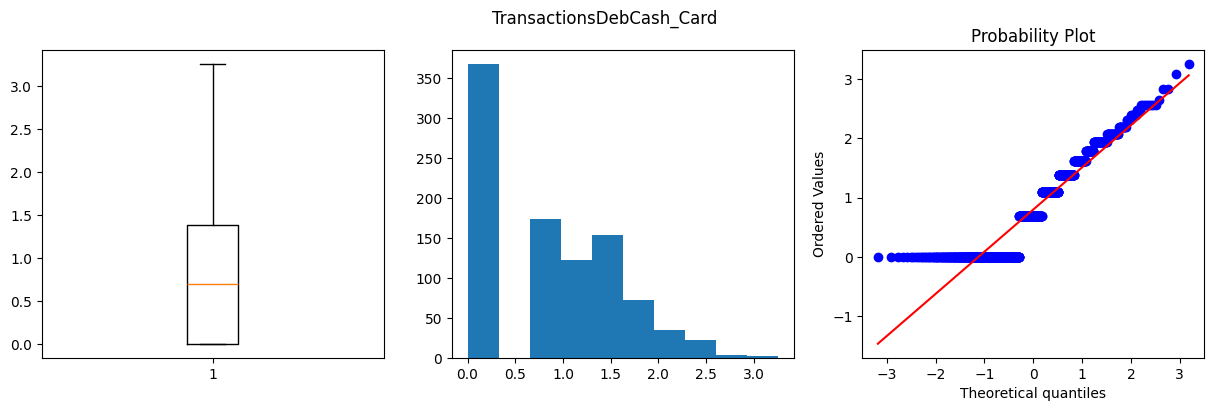

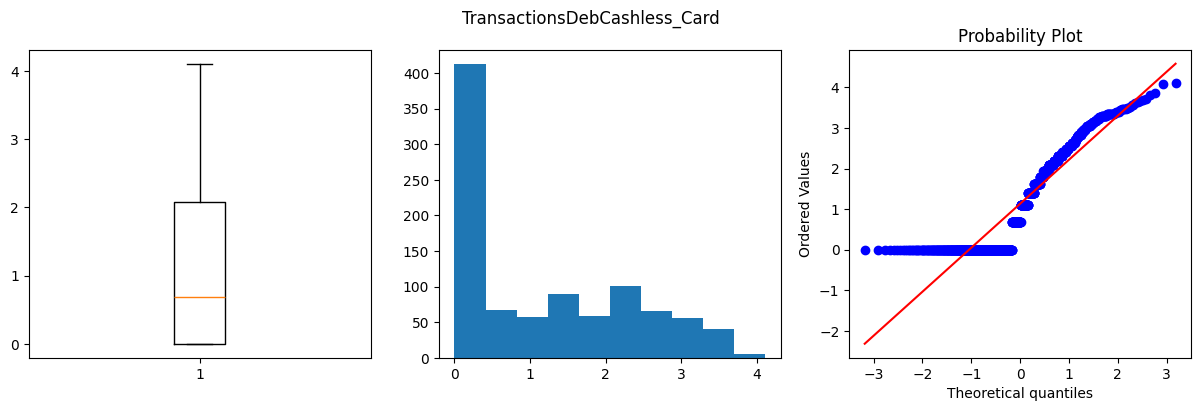

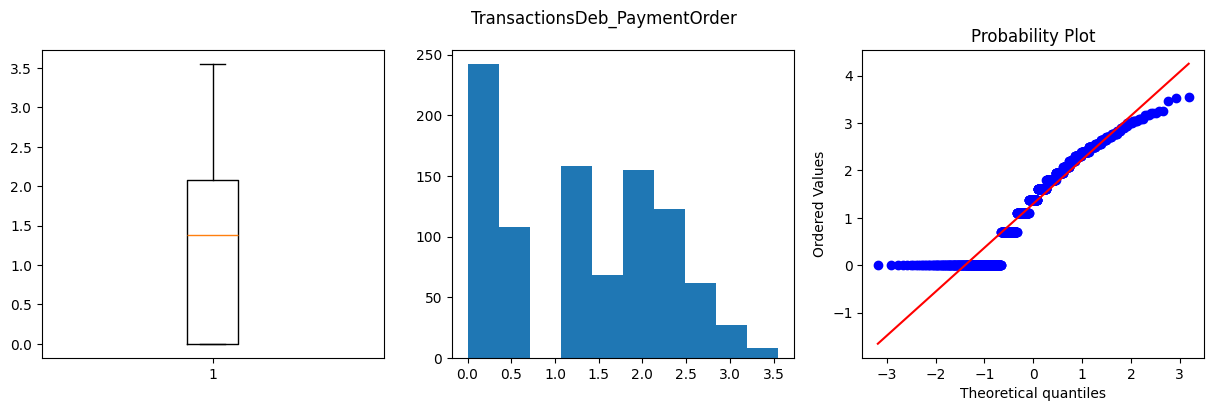

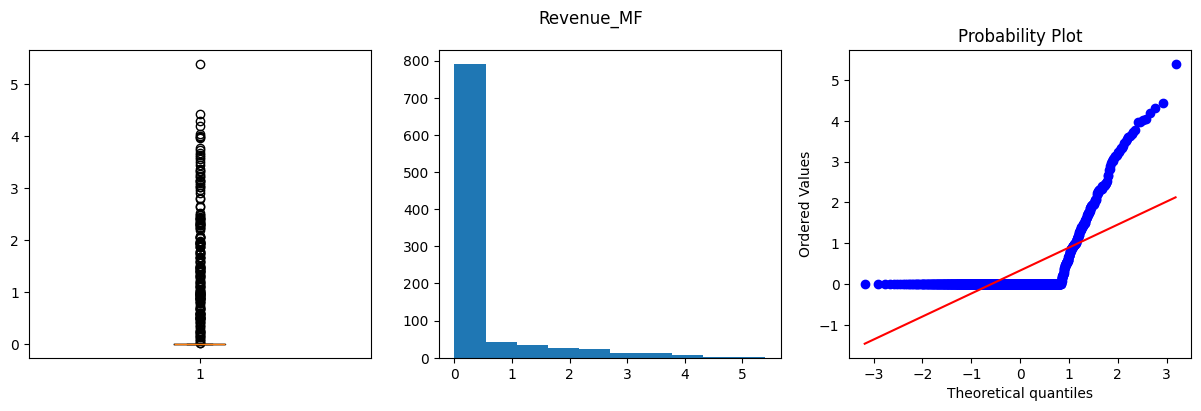

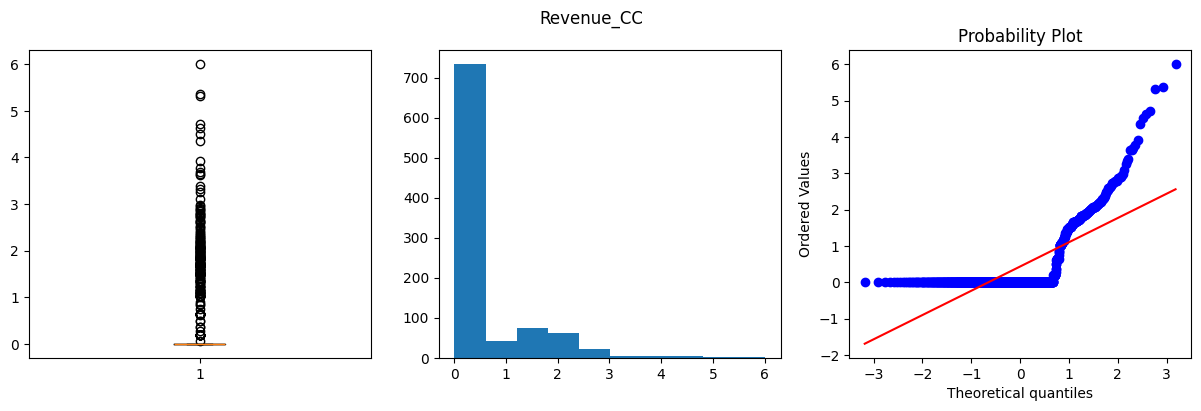

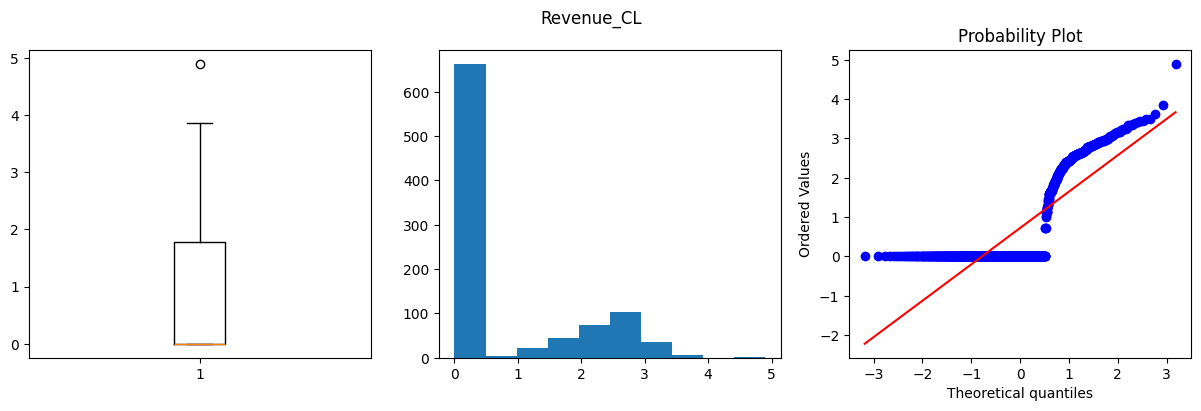

In [64]:
from sklearn.preprocessing import FunctionTransformer

logarithm_transformer = FunctionTransformer(np.log1p, validate=True)

# Apply the transformation to the skewed features
skewed_columns = ['Count_MF',
         'ActBal_CA',
         'ActBal_SA',
         'ActBal_MF',
         'ActBal_OVD',
         'ActBal_CC',
         'ActBal_CL',
         'VolumeCred',
         'VolumeCred_CA',
         'TransactionsCred',
         'TransactionsCred_CA',
         'VolumeDeb',
         'VolumeDeb_CA',
         'VolumeDebCash_Card',
         'VolumeDebCashless_Card',
         'VolumeDeb_PaymentOrder',
         'TransactionsDeb',
         'TransactionsDeb_CA',
         'TransactionsDebCash_Card',
         'TransactionsDebCashless_Card',
         'TransactionsDeb_PaymentOrder',
         'Revenue_MF',
         'Revenue_CC',
         'Revenue_CL',]

df_features_transformed = df_numeric.copy()

# Make all the values of 'ActBal_CC' positive
df_features_transformed['ActBal_CC'] = df_features_transformed['ActBal_CC'] - df_features_transformed['ActBal_CC'].min()

arr_transformed = logarithm_transformer.transform(df_features_transformed[skewed_columns].values)

for idx in range(len(skewed_columns)):
    df_features_transformed[skewed_columns[idx]] = arr_transformed[:, idx]

for col in skewed_columns: 
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
    fig.suptitle(col)
    axes[0].boxplot(df_features_transformed[col])
    axes[1].hist(df_features_transformed[col])
    stats.probplot(df_features_transformed[col], dist='norm', plot=axes[2])
    plt.show()    
  

#### <span style="color:orange">**Comments**</span>

It can be seen that:
* For most of the features, the value distribution gets closer to normal distribution form after applying data transformation. 
* For the features 'Count_MF', 'ActBal_SA', 'ActBal_MF', 'ActBal_OVD', and 'ActBal_CL', the value distribution are still very skewed. Since the value ranges of these features are fairly small, no further data transformation is going to applied to these features. 
* Each of the revunue columns 'Revenue_MF', 'Revenue_CC', and 'Revenue_CL', which will be used as the targets for the regression model building, contain a large number of 0 values. In modeling, we will build classifiers to predict whether the targets will be zero or non-zero, the regression models are used to predict target values only on the non-zero. This means the records with 0 target values will be excluede from the dataset in building regression models. We can see that after excluding the 0 values, the distribution of transformed values of these revenue columns are close to normal distribution. 

In [16]:
# Create the dataset for training
df_modeling_transformed = pd.merge(left=df_features_transformed, right=df_Sales_Revenues, left_on='Client', right_on='Client')

# Create the dataset for prediction
df_outer_transformed = pd.merge(left=df_features_transformed, right=df_Sales_Revenues, how='outer', left_on='Client', right_on='Client', indicator = True)
df_prediction_transformed = df_outer_transformed[(df_outer_transformed._merge=='left_only')].drop(['_merge', 
                                                                                                   'Sale_MF',
                                                                                                  'Sale_CC',
                                                                                                  'Sale_CL',
                                                                                                  'Revenue_MF',
                                                                                                  'Revenue_CC',
                                                                                                  'Revenue_CL'], axis=1)

In [17]:
# Save the datasets to CSV files
processed_data_path: str = "../data/processed/"

df_modeling.to_csv(os.path.join(processed_data_path, "dataset_modeling_original.csv"), index=False)
df_prediction.to_csv(os.path.join(processed_data_path, "dataset_prediction_original.csv"), index=False)

# Save the enriched datasets to CSV files
df_modeling_enriched.to_csv(os.path.join(processed_data_path, "dataset_modeling_enriched.csv"), index=False)  
df_prediction_enriched.to_csv(os.path.join(processed_data_path, "dataset_prediction_enriched.csv"), index=False)

# Save the transformed datasets to CSV files
df_modeling_transformed.to_csv(os.path.join(processed_data_path, "dataset_modeling_transformed.csv"), index=False)    
df_prediction_transformed.to_csv(os.path.join(processed_data_path, "dataset_prediction_transformed.csv"), index=False)

#### <span style="color:orange">**Results of Data Preparation**</span>

* **df_modeling**: the numerical dataset without enrichment and transformation for training the models
* **df_prediction**: the numerical dataset without enrichment and transformation for applying the models
* **df_modeling_enriched**: he numerical dataset with enrichment but without transformation for training the models
* **df_prediction_enriched**: the numerical dataset with enrichment but without transformation for applying the models
* **df_modeling_transformed**: the numerical dataset without enrichment but with transformation for training the models
* **df_prediction_transformed**:  the numerical dataset without enrichment but with transformation for applying the models

In [18]:
print(df_modeling.shape)
df_modeling.head()

(951, 36)


,Client,Age,Tenure,Count_CA,Count_SA,Count_MF,Count_OVD,Count_CC,Count_CL,ActBal_CA,...,TransactionsDebCash_Card,TransactionsDebCashless_Card,TransactionsDeb_PaymentOrder,Sex_M,Sale_MF,Sale_CC,Sale_CL,Revenue_MF,Revenue_CC,Revenue_CL
0,1217,38,165,1,0.0,0.0,0.0,0.0,0.0,6752.244643,...,0,0,1,1,0,0,0,0.000000,0.000000,0.000000
1,850,49,44,1,0.0,0.0,0.0,0.0,0.0,43.523214,...,0,0,1,0,0,1,0,0.000000,0.893929,0.000000
2,1473,54,34,1,1.0,0.0,0.0,1.0,1.0,29.024286,...,1,26,11,1,1,0,0,4.929643,0.000000,0.000000
3,1038,29,106,1,0.0,0.0,0.0,0.0,0.0,27.035714,...,0,0,0,1,0,0,0,0.000000,0.000000,0.000000
4,225,14,187,1,0.0,0.0,1.0,0.0,0.0,345.686071,...,0,4,1,1,0,0,1,0.000000,0.000000,8.130714


In [19]:
print(df_modeling_enriched.shape)
df_modeling_enriched.head()

(951, 59)


,Client,Age,Tenure,Count_CA,Count_SA,Count_MF,Count_OVD,Count_CC,Count_CL,ActBal_CA,...,avg_VolumeDebCashless,avg_VolumeDeb_PaymentOrder,VolumeCred_nonCA,VolumeDeb_nonCA,Sale_MF,Sale_CC,Sale_CL,Revenue_MF,Revenue_CC,Revenue_CL
0,1217,38,165,1,0.0,0.0,0.0,0.0,0.0,6752.244643,...,0.000000,714.285714,0.000000,0.000000,0,0,0,0.000000,0.000000,0.000000
1,850,49,44,1,0.0,0.0,0.0,0.0,0.0,43.523214,...,0.000000,121.928571,0.000000,0.000000,0,1,0,0.000000,0.893929,0.000000
2,1473,54,34,1,1.0,0.0,0.0,1.0,1.0,29.024286,...,17.099904,188.798701,847.998571,80.557143,1,0,0,4.929643,0.000000,0.000000
3,1038,29,106,1,0.0,0.0,0.0,0.0,0.0,27.035714,...,0.000000,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0.000000
4,225,14,187,1,0.0,0.0,1.0,0.0,0.0,345.686071,...,27.808929,19.285714,0.000000,0.000000,0,0,1,0.000000,0.000000,8.130714


In [20]:
print(df_modeling_transformed.shape)
df_modeling_transformed.head()

(951, 36)


,Client,Age,Tenure,Count_CA,Count_SA,Count_MF,Count_OVD,Count_CC,Count_CL,ActBal_CA,...,TransactionsDebCash_Card,TransactionsDebCashless_Card,TransactionsDeb_PaymentOrder,Sex_M,Sale_MF,Sale_CC,Sale_CL,Revenue_MF,Revenue_CC,Revenue_CL
0,1217,38,165,1,0.0,0.0,0.0,0.0,0.0,8.817778,...,0.000000,0.000000,0.693147,1,0,0,0,0.000000,0.000000,0.000000
1,850,49,44,1,0.0,0.0,0.0,0.0,0.0,3.796011,...,0.000000,0.000000,0.693147,0,0,1,0,0.000000,0.893929,0.000000
2,1473,54,34,1,1.0,0.0,0.0,1.0,1.0,3.402007,...,0.693147,3.295837,2.484907,1,1,0,0,4.929643,0.000000,0.000000
3,1038,29,106,1,0.0,0.0,0.0,0.0,0.0,3.333479,...,0.000000,0.000000,0.000000,1,0,0,0,0.000000,0.000000,0.000000
4,225,14,187,1,0.0,0.0,1.0,0.0,0.0,5.848420,...,0.000000,1.609438,0.693147,1,0,0,1,0.000000,0.000000,8.130714


## 5. Building Classification Models to Predict Product Purchase Propensity

### Building Baseline Models

DecisionTreeClassifier is used to build the baseline models, as it can give satisfactory results with imbalanced data, and no feature scaling or transformation is needed.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_val_score

****** Baseline Model Metrics for Sale_MF ******

Confusion Matrix: 
 [[625 133]
 [140  53]]

Classification Report:


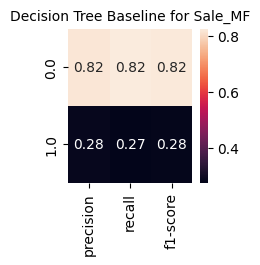

****** Baseline Model Metrics for Sale_CC ******

Confusion Matrix: 
 [[548 166]
 [169  68]]

Classification Report:


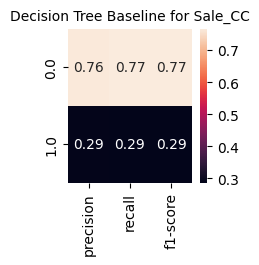

****** Baseline Model Metrics for Sale_CL ******

Confusion Matrix: 
 [[454 208]
 [191  98]]

Classification Report:


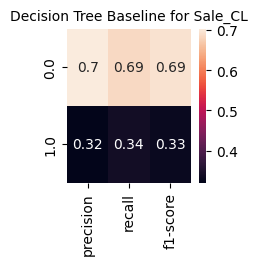

In [22]:
# Evaluate the confusion matrix and classifiocation metrices for each baseline model based on the dataset without enrichment and transformation
df_modeling = pd.read_csv(os.path.join(processed_data_path, "dataset_modeling_original.csv"))
df_modeling_enriched = pd.read_csv(os.path.join(processed_data_path, "dataset_modeling_enriched.csv"))

df_build = df_modeling.drop(['Client'], axis=1).astype('float32')
arr_build = df_build.values

X = arr_build[:, :-6]

y_Sale_MF = arr_build[:, -6]
y_Sale_CC = arr_build[:, -5]
y_Sale_CL = arr_build[:, -4]

target_names = ['Sale_MF', 'Sale_CC', 'Sale_CL']
target_sets = [y_Sale_MF, y_Sale_CC, y_Sale_CL]

def report_test_results(y_test: np.array, y_pred: np.array, target_name: str, model_name: str)  -> None:
    
    print(f"****** Baseline Model Metrics for {target_name} ******")

    # Confusion matrix
    print("\nConfusion Matrix: \n", metrics.confusion_matrix(y_test, y_pred)) # Confusion matrix
    
    # Classification report
    print("\nClassification Report:")
    clf_report_dtc = metrics.classification_report(y_test, y_pred, output_dict=True)
    plt.figure(figsize=(2, 2))
    plt.title(f"{model_name} for {target_name}", fontdict={'fontsize': 10})
    sns.heatmap(pd.DataFrame(clf_report_dtc).iloc[:-1, :-3].T, annot=True)
    plt.show()    


def build_test_dtc(X: np.array, y: np.array, target_name: str, model_name: str) -> None:

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 
    cv_splits = cv.split(X, y)

    # DecisionTreeClassifier is used to build the baseline as no feature scaling is needed.
    dtc = DecisionTreeClassifier(random_state=42, class_weight='balanced')

    y_test_cv = []
    y_pred_cv = []

    for train_indices, test_indices in cv_splits:
        # Split the dataset into train and test datasets
        X_train = X[train_indices]
        y_train = y[train_indices]

        X_test = X[test_indices]
        y_test = y[test_indices]   

        # Fitting and making predictions
        dtc.fit(X_train, y_train)
        y_pred_dtc = dtc.predict(X_test)

        y_test_cv.extend(y_test.tolist())
        y_pred_cv.extend(y_pred_dtc.tolist())

 
    report_test_results(y_test_cv, y_pred_cv, target_name, model_name)


for target_name, target_set in zip(target_names, target_sets):
    
    build_test_dtc(X, target_set, target_name, 'Decision Tree Baseline')

### Investigating Usefulness of the Created Features in Building Baseline Models

In [23]:
# Here, the baseline models are built upon df_modeling, as well as df_modeling_enriched, to compare the performance of the models with and without enrichment.
# Since it's not necessary to scale or transform numerical features for tree-based models, the dataset df_modeling_transformed is not used for training the models.

for data_set_name, data_set in zip(['df_modeling', 'df_modeling_enriched'], [df_modeling, df_modeling_enriched]):
    df_build = data_set.drop(['Client'], axis=1).astype('float32')
    arr_build = df_build.values

    X = arr_build[:, :-6]

    y_Sale_MF = arr_build[:, -6]
    y_Sale_CC = arr_build[:, -5]
    y_Sale_CL = arr_build[:, -4]

    target_names = ['Sale_MF', 'Sale_CC', 'Sale_CL']
    target_sets = [y_Sale_MF, y_Sale_CC, y_Sale_CL]

    print(f"\n-------- Baseline Model is built upon {data_set_name} --------")

    # The model is trained and evaluated using 10-fold cross-validation
    for target_name, target_set in zip(target_names, target_sets):
        
        y = target_set
        
        # 10-fold random stratified cross-validation
        # cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42) 
        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 
        
        dtc = DecisionTreeClassifier(random_state=42, class_weight='balanced')
            
        print(f"\n****** Baseline Model Metrics for {target_name} ******")
        
        # Accuracy score
        print("Mean CV Accuracy:", cross_val_score(dtc, X, y, scoring="accuracy", cv=cv, n_jobs=-1).mean())  

        # Precision score
        print("Mean CV Precision:", cross_val_score(dtc, X, y, scoring="precision", cv=cv, n_jobs=-1).mean()) 

        # Recall score
        print("Mean CV Recall:", cross_val_score(dtc, X, y, scoring="recall", cv=cv, n_jobs=-1).mean())  

        # ROC-AUC
        print("Mean CV ROC-AUC:", cross_val_score(dtc, X, y, scoring="roc_auc", cv=cv, n_jobs=-1).mean()) 



-------- Baseline Model is built upon df_modeling --------

****** Baseline Model Metrics for Sale_MF ******
Mean CV Accuracy: 0.7129605263157895
Mean CV Precision: 0.2830330612426116
Mean CV Recall: 0.27473684210526317
Mean CV ROC-AUC: 0.5496666666666667

****** Baseline Model Metrics for Sale_CC ******
Mean CV Accuracy: 0.6476644736842105
Mean CV Precision: 0.3001079156456731
Mean CV Recall: 0.28731884057971013
Mean CV ROC-AUC: 0.5272568381302307

****** Baseline Model Metrics for Sale_CL ******
Mean CV Accuracy: 0.5804166666666667
Mean CV Precision: 0.3158677248677249
Mean CV Recall: 0.3392857142857143
Mean CV ROC-AUC: 0.5124967693997544

-------- Baseline Model is built upon df_modeling_enriched --------

****** Baseline Model Metrics for Sale_MF ******
Mean CV Accuracy: 0.6877083333333334
Mean CV Precision: 0.22405482113047065
Mean CV Recall: 0.2336842105263158
Mean CV ROC-AUC: 0.5185438596491228

****** Baseline Model Metrics for Sale_CC ******
Mean CV Accuracy: 0.63927631578947

#### <span style="color:orange">**Comments**</span>

The metrics scores and the confusion matrices show that:
* The baseline models perform well when predicting the Non-Purchase class (Sale_MF==0, Sale_CC==0, Sale_CL==0), but are not able to make accurate predictions for the Purchase class (Sale_MF==1, Sale_CC==1, Sale_CL==1). 
* Both false positive rates and false negative rates are high. 

The problem may come from the imbalance of the classes in the target variables. **Oversampling** techniqhes are going to be used to generate balanced dataset to improve the model quality. 

The compararison of the performance of the baseline models built with and without enrichment shows that:
* Introducing enriched features doesn't improve the baseline models' performance. 
* However, the enriched dataset will still be used in the following model building investigation as after tuning the hyperparameters the created features may have positive contribution to models' performance.

### Comparing Different Oversampling Techniques

In [24]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.metrics import accuracy_score, roc_auc_score

target_names = ['Sale_MF', 'Sale_CC', 'Sale_CL']
target_indeces = [-6, -5, -4]

# The oversampling methods are applied to the training dataset to build the baseline models.
def build_baseline_models_with_oversampling(df_build: pd.DataFrame, target_names: list, target_indeces: list, sampling_method: str) -> None:
    
    arr_build =  df_build.drop(['Client'], axis=1).astype('float32').values
    X = arr_build[:, :-6]

    for target_name, target_index in zip(target_names, target_indeces):
        y = arr_build[:, target_index]

        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 
        cv_splits = cv.split(X, y)
        
        avg_accuracy = 0.0
        avg_precision = 0.0
        avg_recall = 0.0    
        avg_roc_auc = 0.0
        
        for train_indices, test_indices in cv_splits:
            X_train = X[train_indices]
            y_train = y[train_indices]

            X_test = X[test_indices]
            y_test = y[test_indices]    
            
            # Apply oversampling to the training data
            # The overSampler is applied to the training data only.
            if sampling_method == 'SMOTE':
                oversampler = SMOTE(random_state=42, sampling_strategy='auto')
            elif sampling_method == 'RandomOverSampler':
                oversampler = RandomOverSampler(random_state=42)
            else:
                raise ValueError(f"Unknown sampling method: {sampling_method}")
            
            X_balanced, y_balanced = oversampler.fit_resample(X_train, y_train)

            # DecisionTreeClassifier is used to build the baseline as no feature scaling is needed.
            dtc = DecisionTreeClassifier(random_state=42, class_weight='balanced')

            # Fitting and making predictions
            dtc.fit(X_balanced, y_balanced)
            y_pred_dtc = dtc.predict(X_test)
            y_proba_dtc = dtc.predict_proba(X_test)[:, 1]
            
            accuracy = accuracy_score(y_test, y_pred_dtc)
            precision = metrics.precision_score(y_test, y_pred_dtc)
            recall = metrics.recall_score(y_test, y_pred_dtc)
            roc_auc = roc_auc_score(y_test, y_proba_dtc)
            
            avg_accuracy += accuracy
            avg_precision += precision
            avg_recall += recall
            avg_roc_auc += roc_auc
            
        
        avg_accuracy = avg_accuracy / 10.0
        avg_precision = avg_precision / 10.0
        avg_recall = avg_recall / 10.0
        avg_roc_auc = avg_roc_auc / 10.0   
            
        print(f"\n****** Decision Tree on Balanced Data with {sampling_method} for {target_name} ******")    

        # Accuracy score
        print("\nMean CV Accuracy:", avg_accuracy)  

        # Precision score
        print("Mean CV Precision:", avg_precision)

        # Recall score
        print("Mean CV Recall:", avg_recall)

        # ROC-AUC
        print("Mean CV ROC-AUC:", avg_roc_auc)       


In [25]:
# Perform random oversampling with replacement
build_baseline_models_with_oversampling(df_modeling, target_names, target_indeces, 'RandomOverSampler')


****** Decision Tree on Balanced Data with RandomOverSampler for Sale_MF ******

Mean CV Accuracy: 0.712938596491228
Mean CV Precision: 0.28316756224570894
Mean CV Recall: 0.2744736842105263
Mean CV ROC-AUC: 0.5494473684210526

****** Decision Tree on Balanced Data with RandomOverSampler for Sale_CC ******

Mean CV Accuracy: 0.6666776315789474
Mean CV Precision: 0.3148694804644462
Mean CV Recall: 0.31159420289855067
Mean CV ROC-AUC: 0.5479136898686807

****** Decision Tree on Balanced Data with RandomOverSampler for Sale_CL ******

Mean CV Accuracy: 0.6372368421052632
Mean CV Precision: 0.40517267781783917
Mean CV Recall: 0.39802955665024625
Mean CV ROC-AUC: 0.5698650723097456


#####  Synthetic Minority Oversampling Technique (SMOTE)

In [26]:
# Perform SMOTE oversampling
build_baseline_models_with_oversampling(df_modeling, target_names, target_indeces, 'SMOTE')


****** Decision Tree on Balanced Data with SMOTE for Sale_MF ******

Mean CV Accuracy: 0.6666557017543859
Mean CV Precision: 0.21576264378895962
Mean CV Recall: 0.2431578947368421
Mean CV ROC-AUC: 0.5087456140350877

****** Decision Tree on Balanced Data with SMOTE for Sale_CC ******

Mean CV Accuracy: 0.6477412280701755
Mean CV Precision: 0.3191120455162809
Mean CV Recall: 0.36739130434782613
Mean CV ROC-AUC: 0.5541573110158536

****** Decision Tree on Balanced Data with SMOTE for Sale_CL ******

Mean CV Accuracy: 0.6056469298245613
Mean CV Precision: 0.3590327291822008
Mean CV Recall: 0.37733990147783253
Mean CV ROC-AUC: 0.5414062691468764


#### <span style="color:orange">**Comments**</span>

The comparison of the model matrics scores between the oversampling techniqhes and the baseline indicates that:
* Using the oversampling techniqhes has significantly improved the quality of the classification models for Sale_CC and Sale_CL; both precision and recall have increased. 
* But the quality of the classification model for SSale_MF has not been improved by balancing the training data using oversampling.
* Fot the Decision Tree classification models, **Random Oversampling with Replacement** gives the better results than oversampling with SMOTE. 

### Comparing Different Modeling Methods

In [27]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

# A set of ensemble models are defined to accurately fit the data.
models = [RandomForestClassifier(random_state=42), 
          ExtraTreesClassifier(random_state=42), 
          GradientBoostingClassifier(random_state=42), 
          XGBClassifier(random_state=42)]
model_names = ["RandomForest", "ExtraTrees", "GradientBoosting", "XGBoost"]

# Define targets
target_names = ['Sale_MF', 'Sale_CC', 'Sale_CL']
target_indeces = [-6, -5, -4]


def cross_validate_models(df_build: pd.DataFrame, dataset_name: str) -> None:
    

    for target_name, target_index in zip(target_names, target_indeces):
        arr_build = df_build.values
        
        X = arr_build[:, :-6]
        y = arr_build[:, target_index]
       
        # 10-fold random stratified cross-validation
        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 

        print(f"****** Model Metrics for {target_name} on {dataset_name} ******")

        # Getting matrics scores for the different models
        for model, model_name in zip(models, model_names):

            print(f"-- {model_name} --")
            # Accuracy score
            print("Mean CV Accuracy:", cross_val_score(model, X, y, scoring="accuracy", cv=cv, n_jobs=-1).mean())  

            # Precision score
            print("Mean CV Precision:", cross_val_score(model, X, y, scoring="precision", cv=cv, n_jobs=-1).mean()) 

            # Recall score
            print("Mean CV Recall:", cross_val_score(model, X, y, scoring="recall", cv=cv, n_jobs=-1).mean())

            # ROC-AUC
            print("Mean CV ROC-AUC:", cross_val_score(model, X, y, scoring="roc_auc", cv=cv, n_jobs=-1).mean())        
            print()     
            
            
cross_validate_models(df_build, "Original Dataset")            

****** Model Metrics for Sale_MF on Original Dataset ******
-- RandomForest --
Mean CV Accuracy: 0.8044298245614036
Mean CV Precision: 0.6016666666666667
Mean CV Recall: 0.08263157894736842
Mean CV ROC-AUC: 0.5665822022160665

-- ExtraTrees --
Mean CV Accuracy: 0.798125
Mean CV Precision: 0.43666666666666665
Mean CV Recall: 0.09263157894736843
Mean CV ROC-AUC: 0.5934766620498615

-- GradientBoosting --
Mean CV Accuracy: 0.8023245614035087
Mean CV Precision: 0.5583333333333333
Mean CV Recall: 0.12394736842105263
Mean CV ROC-AUC: 0.5686048476454293

-- XGBoost --
Mean CV Accuracy: 0.7875877192982456
Mean CV Precision: 0.44929653679653675
Mean CV Recall: 0.14578947368421052
Mean CV ROC-AUC: 0.5646030470914127

****** Model Metrics for Sale_CC on Original Dataset ******
-- RandomForest --
Mean CV Accuracy: 0.7749890350877193
Mean CV Precision: 0.6765079365079365
Mean CV Recall: 0.18605072463768113
Mean CV ROC-AUC: 0.6120545080061691

-- ExtraTrees --
Mean CV Accuracy: 0.7623464912280701
Me

### Investigating Usefulness of the Created Features in Using Different Modeling Methods

In [28]:
df_build_enriched = df_modeling_enriched.drop(['Client'], axis=1).astype('float32')

cross_validate_models(df_build_enriched, "Enriched Dataset")   

****** Model Metrics for Sale_MF on Enriched Dataset ******
-- RandomForest --
Mean CV Accuracy: 0.8044298245614036
Mean CV Precision: 0.6016666666666667
Mean CV Recall: 0.08263157894736842
Mean CV ROC-AUC: 0.5665822022160665

-- ExtraTrees --
Mean CV Accuracy: 0.798125
Mean CV Precision: 0.43666666666666665
Mean CV Recall: 0.09263157894736843
Mean CV ROC-AUC: 0.5934766620498615

-- GradientBoosting --
Mean CV Accuracy: 0.8023245614035087
Mean CV Precision: 0.5583333333333333
Mean CV Recall: 0.12394736842105263
Mean CV ROC-AUC: 0.5686048476454293

-- XGBoost --
Mean CV Accuracy: 0.7875877192982456
Mean CV Precision: 0.44929653679653675
Mean CV Recall: 0.14578947368421052
Mean CV ROC-AUC: 0.5646030470914127

****** Model Metrics for Sale_CC on Enriched Dataset ******
-- RandomForest --
Mean CV Accuracy: 0.7749890350877193
Mean CV Precision: 0.6765079365079365
Mean CV Recall: 0.18605072463768113
Mean CV ROC-AUC: 0.6120545080061691

-- ExtraTrees --
Mean CV Accuracy: 0.7623464912280701
Me

#### <span style="color:orange">**Comments**</span>

By comparing the metric scores for different ensemble modeling methods on the original and enriched datasets, the following conclusions can be drawn:
* With the default hyperparameter settings, all these ensemble learning methods do not improve the model quality in terms of recall.
* With the default hyperparameter settings, the created features do not introduce significant model quality improvement. 

### Optimizing Model Hyperparameters

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from typing import Union


def randomSearch_pipeline(X_train: np.array, y_train: np.array, modeling_method: str, param_dist: dict, cv: int = 10, scoring_fit: str = 'accuracy', over_sampler: str = 'RandomOverSampler') -> Union[DecisionTreeClassifier, ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier, XGBClassifier]:
    """
    Perform a random search with cross-validation on the specified modeling method and parameter distribution.
    Parameters:
        X_train (np.array): Feature matrix for training.
        y_train (np.array): Target vector for training.
        modeling_method (str): The modeling method to use ('DecisionTree', 'RandomForest', 'ExtraTrees', 'GradientBoosting', 'XGBoost').
        param_dist (dict): Dictionary with parameters names as keys and distributions or lists of parameters to try.
        cv (int): Number of cross-validation folds.
        scoring_fit (str): Scoring metric to use for evaluation.
    Returns:
        fitted_model: The fitted model after random search.
    """
    # Initialize the classifier
    if modeling_method == 'DecisionTree':
        model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
    elif modeling_method == 'RandomForest':
        model = RandomForestClassifier(random_state=42, class_weight='balanced')
    elif modeling_method == 'ExtraTrees':
        model = ExtraTreesClassifier(random_state=42, class_weight='balanced')  
    elif modeling_method == 'GradientBoosting':
        model = GradientBoostingClassifier(random_state=42)    
    elif modeling_method == 'XGBoost':          
        model = XGBClassifier(random_state=42, eval_metric='logloss')
    else:       
        raise ValueError("Unsupported modeling method. Choose from 'RandomForest', 'ExtraTrees', 'GradientBoosting', or 'XGBoost'.")
    
    # Initialize the oversampler
    if over_sampler not in ['RandomOverSampler', 'SMOTE']:
        oversampler = None
    else:
        oversampler = RandomOverSampler(sampling_strategy='auto', random_state=42) if over_sampler == 'RandomOverSampler' else SMOTE(sampling_strategy='auto', random_state=42)

    # Create a pipeline with SMOTE and the initialized model
    pipeline = ImbPipeline([
        ('oversampler', oversampler),
        ('classifier', model)
    ])

    rs = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist, 
        n_iter=50,  # Number of different combinations to try
        cv=cv, 
        random_state=42,
        n_jobs=-1, 
        scoring=scoring_fit,
        verbose=2
    )

    fitted_model = rs.fit(X_train, y_train)
    
    return fitted_model

# Define the parameter grid for DecisionTreeClassifier
param_dist_decisionTree = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [None] + list(np.arange(1, 21)),   # None or values from 1 to 20
    'classifier__min_samples_split': np.arange(2, 11),           # values from 2 to 10
    'classifier__min_samples_leaf': np.arange(1, 11),            # values from 1 to 10
    'classifier__max_features': [None, 'sqrt', 'log2'],
    # 'splitter': ['best', 'random']
}

# Define the hyperparameter grid for RandomForestClassifier
param_dist_randomForest = {
    'classifier__n_estimators': np.arange(50, 500, 50),
    'classifier__criterion': ['gini', 'entropy', 'log_loss'], 
    'classifier__max_depth': [None, 10, 20, 30, 40, 50],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__bootstrap': [True, False]
}

# Define the hyperparameter grid for ExtraTreesClassifier
param_dist_extraTrees = {
    'classifier__n_estimators': np.arange(50, 500, 50),
    'classifier__criterion': ['gini', 'entropy', 'log_loss'], 
    'classifier__max_depth': [None, 10, 20, 30, 40, 50],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__bootstrap': [True, False]  # ExtraTreesClassifier default is False
}

# Define the parameter grid for GradientBoostingClassifier
param_dist_gradientBoosting = {
    'classifier__n_estimators': np.arange(50, 500, 50),
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 4, 5, 6],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__max_features': ['sqrt', 'log2', None]
}

# Define the parameter grid for XGBClassifier
param_dist_XGBoost = {
    'classifier__n_estimators': np.arange(50, 500, 50),
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__min_child_weight': [1, 3, 5],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
    'classifier__gamma': [0, 0.1, 0.2, 0.3],
    'classifier__reg_alpha': [0, 0.1, 1],
    'classifier__reg_lambda': [1, 1.5, 2]
}

target_names = ['Sale_MF', 'Sale_CC', 'Sale_CL']    
target_indeces = [-6, -5, -4]   

best_param_configurations = {'Sale_MF': None, 'Sale_CC': None, 'Sale_CL': None}

for data_set_name, data_set in zip(['not_enriched', 'enriched'], [df_build, df_build_enriched]) :

    arr_build = data_set.values

    for learning_method in ['DecisionTree', 'RandomForest', 'ExtraTrees', 'GradientBoosting', 'XGBoost']:
        
        modeling_methods = [learning_method] * 3

        if learning_method == 'DecisionTree':
            param_grid = param_dist_decisionTree
        elif learning_method == 'RandomForest':
            param_grid = param_dist_randomForest         
        elif learning_method == 'ExtraTrees': 
            param_grid = param_dist_extraTrees 
        elif learning_method == 'GradientBoosting':
            param_grid = param_dist_gradientBoosting
        elif learning_method == 'XGBoost':  
            param_grid = param_dist_XGBoost
        else:
            raise ValueError("Unsupported modeling method. Choose from 'RandomForest', 'ExtraTrees', 'GradientBoosting', or 'XGBoost'.")

        for over_sampler in ['None', 'RandomOverSampler', 'SMOTE']:

            # Perform random search with cross-validation for each target variable
            # 10-fold random stratified cross-validation
            for target_name, target_index, modeling_method in zip(target_names, target_indeces, modeling_methods):

                X = arr_build[:, :-6]
                y = arr_build[:, target_index]

                # Split the dataset into train and test datasets
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

                # Apply oversampling to the training data
                # The overSampler is applied to the training data only.
                # Perform random search with cross-validation
                # 10-fold random stratified cross-validation 
                # Since the task is to identify the clients with the high propensity to buy the products, the binary classification is aiming for a good balance between recall and precision.
                # Therefore, the 'roc_auc' score is used as the scoring metric in hyperparameter optimization to balance TPR and FPR globally.
                model = randomSearch_pipeline(X, y, modeling_method, param_grid, 10, 'roc_auc', over_sampler)  

                if best_param_configurations[target_name] is None:
                    best_param_configurations[target_name] = {'data_set': data_set_name, 'modeling_method': modeling_method, 'over_sampler': over_sampler, 'best_score': model.best_score_, 'best_hyperparams': model.best_params_}  
                else:
                    if model.best_score_ > best_param_configurations[target_name]['best_score']:
                        best_param_configurations[target_name] = {'data_set': data_set_name, 'modeling_method': modeling_method, 'over_sampler': over_sampler, 'best_score': model.best_score_, 'best_hyperparams': model.best_params_}   

                
                print(f"****** Best Scores/Hyperparameters for {target_name} ******")
                print(model.best_score_)
                # print(model.best_params_) 
                print("\n")

             
print("****** Best hyperparameters for each target variable:")  
for target_name, configurations in best_param_configurations.items():
    print(f"{target_name}: {target_name}")
    print(f"Best score: {configurations['best_score']}")
    print(f"Modeling method: {configurations['modeling_method']}")
    print(f"Over sampler: {configurations['over_sampler']}")
    print(f"Data set: {configurations['data_set']}")  
    print(f"Best hyperparameters: {configurations['best_hyperparams']}")
    print("\n")

# Save the best modling configurations into a JSON file
import json


# Since JSON module in Python doesn't know how to handle NumPy types, we need to convert them to standard Python types.
def convert_numpy_types(obj: Union[np.ndarray, np.generic, dict, list]) -> Union[dict, list, float, int, str]:
    
    """Convert NumPy types to standard Python types for JSON serialization.     
    Args:   
        obj (Union[np.ndarray, np.generic, dict, list]): The object to convert.
       
    Returns:
        Union[dict, list, float, int, str]: The converted object.
    """

    if isinstance(obj, dict):
        return {k: convert_numpy_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_types(v) for v in obj]
    elif isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj
    

cleaned_best_param_configurations = convert_numpy_types(best_param_configurations)

results_path: str = "../results/"
with open(os.path.join(results_path, "best_modeling_configurations.json"), 'w') as f:
    json.dump(cleaned_best_param_configurations, f, indent=4)


Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Best Scores/Hyperparameters for Sale_MF ******
0.5819389196675899


Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Best Scores/Hyperparameters for Sale_CC ******
0.6198560753611848


Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Best Scores/Hyperparameters for Sale_CL ******
0.5981347182582386


Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Best Scores/Hyperparameters for Sale_MF ******
0.5793097414589103


Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Best Scores/Hyperparameters for Sale_CC ******
0.5969659872479643


Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Best Scores/Hyperparameters for Sale_CL ******
0.6103798907388716


Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Best Scores/Hyperparameters for Sale_MF ******
0.581674838411819


Fitting 10 folds for each of 50 can

In [36]:
best_param_configurations

{'Sale_MF': {'data_set': 'not_enriched',
  'modeling_method': 'ExtraTrees',
  'over_sampler': 'None',
  'best_score': 0.6307650507848569,
  'best_hyperparams': {'classifier__n_estimators': 400,
   'classifier__min_samples_split': 10,
   'classifier__min_samples_leaf': 2,
   'classifier__max_features': 'sqrt',
   'classifier__max_depth': None,
   'classifier__criterion': 'gini',
   'classifier__bootstrap': False}},
 'Sale_CC': {'data_set': 'not_enriched',
  'modeling_method': 'ExtraTrees',
  'over_sampler': 'RandomOverSampler',
  'best_score': 0.6430132070603978,
  'best_hyperparams': {'classifier__n_estimators': 150,
   'classifier__min_samples_split': 10,
   'classifier__min_samples_leaf': 4,
   'classifier__max_features': 'sqrt',
   'classifier__max_depth': 50,
   'classifier__criterion': 'entropy',
   'classifier__bootstrap': True}},
 'Sale_CL': {'data_set': 'not_enriched',
  'modeling_method': 'GradientBoosting',
  'over_sampler': 'None',
  'best_score': 0.666554765358162,
  'best_

### Building Final Classification Models

****** Model Metrics for Sale_MF ******

Accuracy: 0.7696335078534031
Precision: 0.5625
Recall: 0.1956521739130435
F1 Score: 0.2903225806451613
ROC-AUC: 0.6133433283358319

Confusion Matrix: 
 [[138   7]
 [ 37   9]]


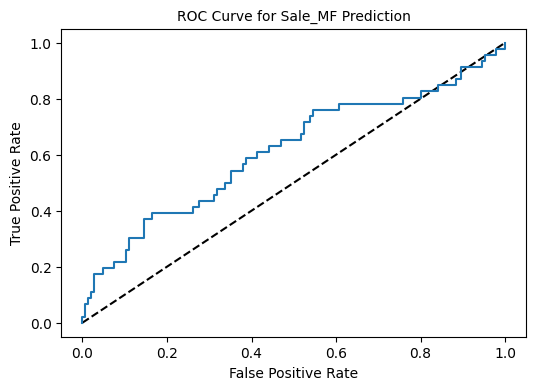



****** Model Metrics for Sale_CC ******

Accuracy: 0.7015706806282722
Precision: 0.45161290322580644
Recall: 0.25925925925925924
F1 Score: 0.32941176470588235
ROC-AUC: 0.5644768856447688

Confusion Matrix: 
 [[120  17]
 [ 40  14]]


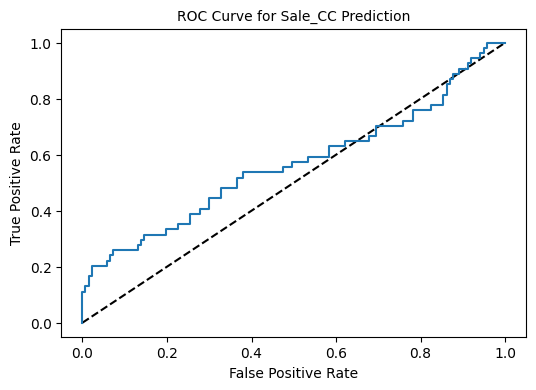



****** Model Metrics for Sale_CL ******

Accuracy: 0.7696335078534031
Precision: 0.6666666666666666
Recall: 0.33962264150943394
F1 Score: 0.45
ROC-AUC: 0.6808859721082855

Confusion Matrix: 
 [[129   9]
 [ 35  18]]


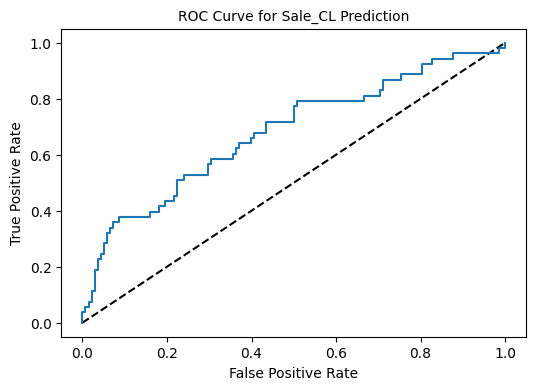

In [33]:
# Estimate metric scores and plot ROC curves to describe the model quality of the best models on the test set 

import os
import json
from typing import Union
from sklearn.metrics import roc_curve

# Load the best modeling configurations from the JSON file 
results_path: str = "../results/"
with open(os.path.join(results_path, "best_modeling_configurations.json"), "r") as f:
    best_param_configurations = json.load(f)

for target_name, target_index in zip(target_names, target_indeces):

    # Load the best modeling configurations for the target variable
    configurations = best_param_configurations[target_name]   

    # Load the dataset based on the configurations
    if configurations['data_set'] == 'not_enriched':        
        arr_build = pd.read_csv(os.path.join(processed_data_path, "dataset_modeling_original.csv")).values
    else:
        arr_build = pd.read_csv(os.path.join(processed_data_path, "dataset_modeling_enriched.csv")).values

    X = arr_build[:, :-6]
    y = arr_build[:, target_index]

    # Split the dataset into train and test datasets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Apply oversampling to the training data
    # The overSampler is applied to the training data only.     
    if configurations['over_sampler'] == 'RandomOverSampler':
        oversampler = RandomOverSampler(sampling_strategy='auto', random_state=42)
    elif configurations['over_sampler'] == 'SMOTE':
        oversampler = SMOTE(sampling_strategy='auto', random_state=42)
    else:
        oversampler = None

    if oversampler is not None:
        X_train, y_train = oversampler.fit_resample(X_train, y_train)
    
    # Get the modeling method and best hyperparameters from the configurations, and build the model
    modeling_method = configurations['modeling_method']
    if modeling_method == 'DecisionTree':
        model = DecisionTreeClassifier(random_state=42, 
                                       class_weight='balanced',
                                       criterion=configurations['best_hyperparams']['classifier__criterion'],
                                       max_depth=configurations['best_hyperparams']['classifier__max_depth'],
                                       min_samples_split=configurations['best_hyperparams']['classifier__min_samples_split'],
                                       min_samples_leaf=configurations['best_hyperparams']['classifier__min_samples_leaf'],
                                       max_features=configurations['best_hyperparams']['classifier__max_features'])
    elif modeling_method == 'RandomForest':
        model = RandomForestClassifier(random_state=42, 
                                       class_weight='balanced',
                                       n_estimators=configurations['best_hyperparams']['classifier__n_estimators'],
                                       criterion=configurations['best_hyperparams']['classifier__criterion'],
                                       max_depth=configurations['best_hyperparams']['classifier__max_depth'],
                                       min_samples_split=configurations['best_hyperparams']['classifier__min_samples_split'],
                                       min_samples_leaf=configurations['best_hyperparams']['classifier__min_samples_leaf'],
                                       max_features=configurations['best_hyperparams']['classifier__max_features'],
                                       bootstrap=configurations['best_hyperparams']['classifier__bootstrap'])
    elif modeling_method == 'ExtraTrees':
        model = ExtraTreesClassifier(random_state=42, 
                                     class_weight='balanced',
                                     n_estimators=configurations['best_hyperparams']['classifier__n_estimators'],
                                     criterion=configurations['best_hyperparams']['classifier__criterion'],   
                                     max_depth=configurations['best_hyperparams']['classifier__max_depth'],                                                                       
                                     min_samples_split=configurations['best_hyperparams']['classifier__min_samples_split'],
                                     min_samples_leaf=configurations['best_hyperparams']['classifier__min_samples_leaf'],
                                     max_features=configurations['best_hyperparams']['classifier__max_features'],
                                     bootstrap=configurations['best_hyperparams']['classifier__bootstrap'])                                    
    elif modeling_method == 'GradientBoosting':
        model = GradientBoostingClassifier(random_state=42, 
                                           n_estimators=configurations['best_hyperparams']['classifier__n_estimators'],
                                           learning_rate=configurations['best_hyperparams']['classifier__learning_rate'],
                                           max_depth=configurations['best_hyperparams']['classifier__max_depth'],
                                           min_samples_split=configurations['best_hyperparams']['classifier__min_samples_split'],
                                           min_samples_leaf=configurations['best_hyperparams']['classifier__min_samples_leaf'],
                                           subsample=configurations['best_hyperparams']['classifier__subsample'],
                                           max_features=configurations['best_hyperparams']['classifier__max_features'])
    elif modeling_method == 'XGBoost':
        model = XGBClassifier(random_state=42,
                              eval_metric='logloss',
                              class_weight='balanced',
                              n_estimators=configurations['best_hyperparams']['classifier__n_estimators'],
                              learning_rate=configurations['best_hyperparams']['classifier__learning_rate'],
                              max_depth=configurations['best_hyperparams']['classifier__max_depth'],
                              min_child_weight=configurations['best_hyperparams']['classifier__min_child_weight'],
                              subsample=configurations['best_hyperparams']['classifier__subsample'],
                              colsample_bytree=configurations['best_hyperparams']['classifier__colsample_bytree'],
                              gamma=configurations['best_hyperparams']['classifier__gamma'],
                              reg_alpha=configurations['best_hyperparams']['classifier__reg_alpha'],
                              reg_lambda=configurations['best_hyperparams']['classifier__reg_lambda'])
    else:       
        raise ValueError("Unsupported modeling method. Choose from 'DecisionTree', 'RandomForest', 'ExtraTrees', 'GradientBoosting', or 'XGBoost'.")


    # Fit and make predictions
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_probs = model.predict_proba(X_test)[:, 1]

    accuracy = metrics.accuracy_score(y_test, y_pred)
    precision = metrics.precision_score(y_test, y_pred)
    recall = metrics.recall_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_probs)


    print(f"****** Model Metrics for {target_name} ******")
    print("\nAccuracy:", accuracy)     
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc_auc)
    print("\nConfusion Matrix: \n", metrics.confusion_matrix(y_test, y_pred)) # Confusion matrix

    # Generate ROC curve values: fpr, tpr, thresholds
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)

    plt.figure(figsize=(6, 4))
    plt.plot([0, 1], [0, 1], 'k--')

    # Plot tpr against fpr
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {target_name} Prediction', fontdict={'fontsize': 10})
    plt.show()    
    print("\n")


In [34]:
# Build final classification models

def train_classifier(target_name: str, target_index: int) -> Union[DecisionTreeClassifier, ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier, XGBClassifier]:
    
    configurations = best_param_configurations[target_name]
    
    # Load the dataset based on the configurations
    if configurations['data_set'] == 'not_enriched':        
        arr_build = pd.read_csv(os.path.join(processed_data_path, "dataset_modeling_original.csv")).values
    else:
        arr_build = pd.read_csv(os.path.join(processed_data_path, "dataset_modeling_enriched.csv")).values
    
    X = arr_build[:, :-6]
    y = arr_build[:, target_index]    

    # Apply oversampling to the training data
    if configurations['over_sampler'] == 'RandomOverSampler':
        oversampler = RandomOverSampler(sampling_strategy='auto', random_state=42)
    elif configurations['over_sampler'] == 'SMOTE':
        oversampler = SMOTE(sampling_strategy='auto', random_state=42)
    else:
        oversampler = None

    if oversampler is not None:
        X_train, y_train = oversampler.fit_resample(X, y)
    else:
        X_train, y_train = X, y

    # Get the modeling method and best hyperparameters from the configurations, and build the model
    modeling_method = configurations['modeling_method']
    if modeling_method == 'DecisionTree':
        model = DecisionTreeClassifier(random_state=42, 
                                       class_weight='balanced',
                                       criterion=configurations['best_hyperparams']['classifier__criterion'],
                                       max_depth=configurations['best_hyperparams']['classifier__max_depth'],
                                       min_samples_split=configurations['best_hyperparams']['classifier__min_samples_split'],
                                       min_samples_leaf=configurations['best_hyperparams']['classifier__min_samples_leaf'],
                                       max_features=configurations['best_hyperparams']['classifier__max_features'])
    elif modeling_method == 'RandomForest':
        model = RandomForestClassifier(random_state=42, 
                                       class_weight='balanced',
                                       n_estimators=configurations['best_hyperparams']['classifier__n_estimators'],
                                       criterion=configurations['best_hyperparams']['classifier__criterion'],
                                       max_depth=configurations['best_hyperparams']['classifier__max_depth'],
                                       min_samples_split=configurations['best_hyperparams']['classifier__min_samples_split'],
                                       min_samples_leaf=configurations['best_hyperparams']['classifier__min_samples_leaf'],
                                       max_features=configurations['best_hyperparams']['classifier__max_features'],
                                       bootstrap=configurations['best_hyperparams']['classifier__bootstrap'])
    elif modeling_method == 'ExtraTrees':
        model = ExtraTreesClassifier(random_state=42, 
                                     class_weight='balanced',
                                     n_estimators=configurations['best_hyperparams']['classifier__n_estimators'],
                                     criterion=configurations['best_hyperparams']['classifier__criterion'],   
                                     max_depth=configurations['best_hyperparams']['classifier__max_depth'],                                                                       
                                     min_samples_split=configurations['best_hyperparams']['classifier__min_samples_split'],
                                     min_samples_leaf=configurations['best_hyperparams']['classifier__min_samples_leaf'],
                                     max_features=configurations['best_hyperparams']['classifier__max_features'],
                                     bootstrap=configurations['best_hyperparams']['classifier__bootstrap'])                                    
    elif modeling_method == 'GradientBoosting':
        model = GradientBoostingClassifier(random_state=42, 
                                           n_estimators=configurations['best_hyperparams']['classifier__n_estimators'],
                                           learning_rate=configurations['best_hyperparams']['classifier__learning_rate'],
                                           max_depth=configurations['best_hyperparams']['classifier__max_depth'],
                                           min_samples_split=configurations['best_hyperparams']['classifier__min_samples_split'],
                                           min_samples_leaf=configurations['best_hyperparams']['classifier__min_samples_leaf'],
                                           subsample=configurations['best_hyperparams']['classifier__subsample'],
                                           max_features=configurations['best_hyperparams']['classifier__max_features'])
    elif modeling_method == 'XGBoost':
        model = XGBClassifier(random_state=42,
                              eval_metric='logloss',
                              class_weight='balanced',
                              n_estimators=configurations['best_hyperparams']['classifier__n_estimators'],
                              learning_rate=configurations['best_hyperparams']['classifier__learning_rate'],
                              max_depth=configurations['best_hyperparams']['classifier__max_depth'],
                              min_child_weight=configurations['best_hyperparams']['classifier__min_child_weight'],
                              subsample=configurations['best_hyperparams']['classifier__subsample'],
                              colsample_bytree=configurations['best_hyperparams']['classifier__colsample_bytree'],
                              gamma=configurations['best_hyperparams']['classifier__gamma'],
                              reg_alpha=configurations['best_hyperparams']['classifier__reg_alpha'],
                              reg_lambda=configurations['best_hyperparams']['classifier__reg_lambda'])
    else:       
        raise ValueError("Unsupported modeling method. Choose from 'DecisionTree', 'RandomForest', 'ExtraTrees', 'GradientBoosting', or 'XGBoost'.")
    
    model.fit(X_train, y_train)
    
    return model
    
# Load the best modeling configurations from the JSON file 
results_path: str = "../results/"
with open(os.path.join(results_path, "best_modeling_configurations.json"), "r") as f:
    best_param_configurations = json.load(f)

# Train the classifiers for each target variable
# The classifiers are trained on the training dataset with oversampling.
classifier_Sale_MF = train_classifier(target_names[0], target_indeces[0])
classifier_Sale_CC = train_classifier(target_names[1], target_indeces[1])
classifier_Sale_CL  = train_classifier(target_names[2], target_indeces[2])

# Save to pickle files
import pickle

model_output_path: str = "../models"
with open(os.path.join(model_output_path, "classifier_Sale_MF.pkl"), "wb") as f:
    pickle.dump(classifier_Sale_MF, f)
with open(os.path.join(model_output_path, "classifier_Sale_CC.pkl"), "wb") as f:
    pickle.dump(classifier_Sale_CC, f)
with open(os.path.join(model_output_path, "classifier_Sale_CL.pkl"), "wb") as f:
    pickle.dump(classifier_Sale_CL, f)

print("The final classifiers are trained and saved to pickle files.")


The final classifiers are trained and saved to pickle files.


## 6. Building Regression Models to Predict Product Purchase Revenue

### Building Baseline Models

########## Baseline Models for not_enriched Dataset ##########
Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_MF ******
Best RMSE on test set: 18.9010
Best Median Absolute Error on test set: 6.7471
Best MAPE on test set: 28.1086
Best R2 score on test set: -0.0361
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_MF ******


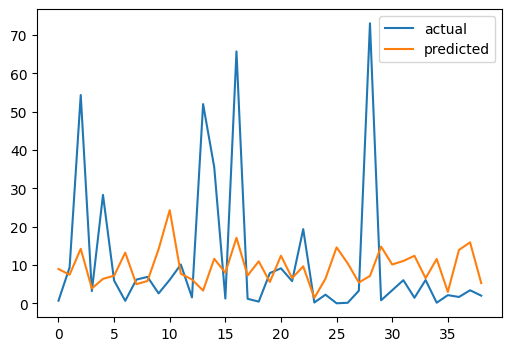

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CC ******
Best RMSE on test set: 35.2772
Best Median Absolute Error on test set: 6.2679
Best MAPE on test set: 5.9559
Best R2 score on test set: -0.0259
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_CC ******


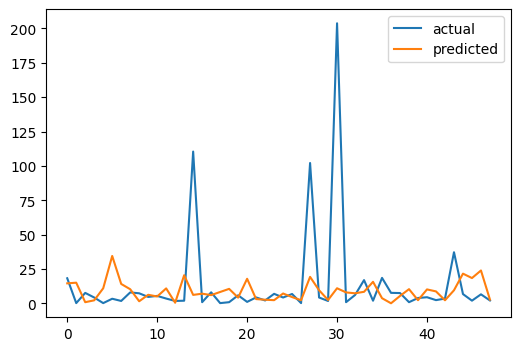

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CL ******
Best RMSE on test set: 7.4472
Best Median Absolute Error on test set: 4.4874
Best MAPE on test set: 1.1575
Best R2 score on test set: -0.4412
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_CL ******


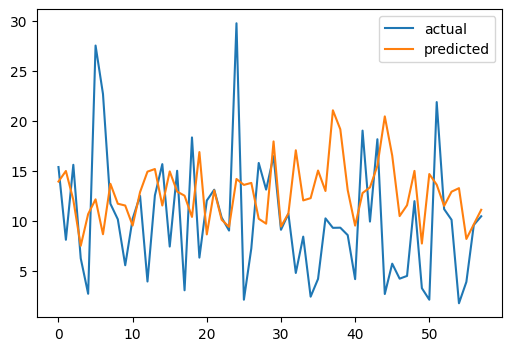




########## Baseline Models for enriched Dataset ##########
Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_MF ******
Best RMSE on test set: 19.2680
Best Median Absolute Error on test set: 9.4099
Best MAPE on test set: 22.4033
Best R2 score on test set: -0.0767
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_MF ******


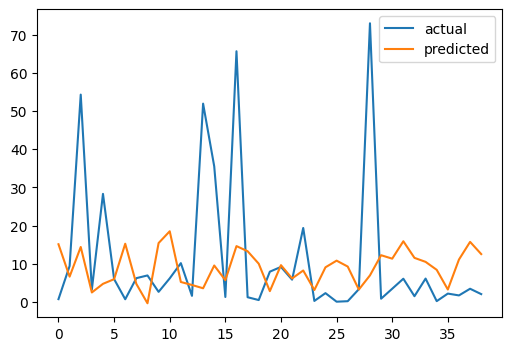

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CC ******
Best RMSE on test set: 35.6419
Best Median Absolute Error on test set: 6.6420
Best MAPE on test set: 6.7619
Best R2 score on test set: -0.0473
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_CC ******


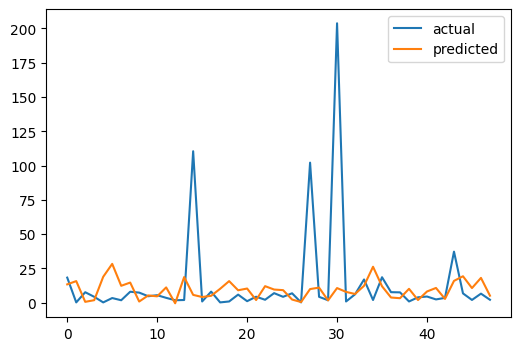

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CL ******
Best RMSE on test set: 7.9673
Best Median Absolute Error on test set: 4.4836
Best MAPE on test set: 1.2108
Best R2 score on test set: -0.6495
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_CL ******


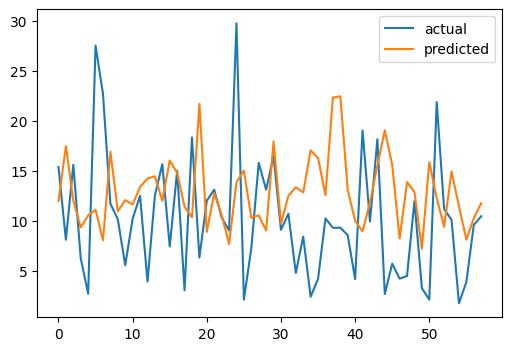




########## Baseline Models for transformed Dataset ##########
Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_MF ******
Best RMSE on test set: 18.8999
Best Median Absolute Error on test set: 7.3505
Best MAPE on test set: 28.1376
Best R2 score on test set: -0.0360
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_MF ******


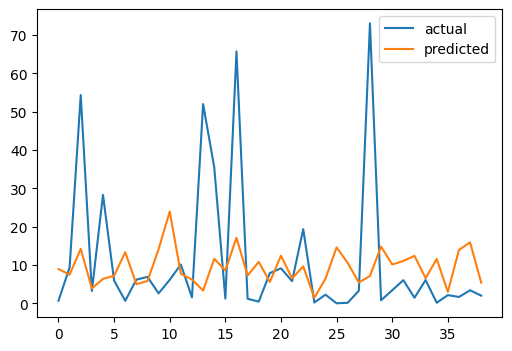

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CC ******
Best RMSE on test set: 35.1974
Best Median Absolute Error on test set: 6.2529
Best MAPE on test set: 5.7718
Best R2 score on test set: -0.0213
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_CC ******


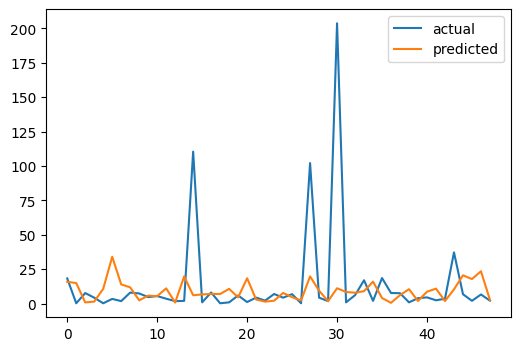

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CL ******
Best RMSE on test set: 7.4563
Best Median Absolute Error on test set: 4.4843
Best MAPE on test set: 1.1620
Best R2 score on test set: -0.4447
Best Hyperparams: {'regressor__learning_rate': 0.023081131526330123, 'regressor__max_depth': 6, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 14, 'regressor__min_samples_split': 7, 'regressor__n_estimators': 198, 'regressor__subsample': 0.8990875095589655}

****** Model Prediction vs. Actual Values for Revenue_CL ******


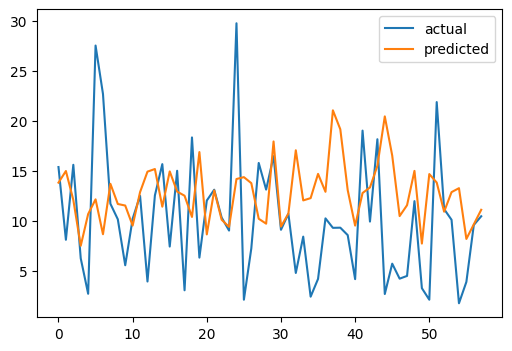

In [12]:
# Use GradientBoostingRegressor to build the baseline regression models for the target variable 'Revenue_MF', 'Revenue_CC', and 'Revenue_CL'.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, r2_score, median_absolute_error
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd


target_names = ['Revenue_MF', 'Revenue_CC', 'Revenue_CL']
target_indeces = [-3, -2, -1]

# Load the dataset
processed_data_path: str = "../data/processed"
df_modeling = pd.read_csv(os.path.join(processed_data_path, "dataset_modeling_original.csv"))
df_modeling_enriched = pd.read_csv(os.path.join(processed_data_path, "dataset_modeling_enriched.csv"))
df_modeling_transformed = pd.read_csv(os.path.join(processed_data_path, "dataset_modeling_transformed.csv"))


for data_set_name, data_set in zip(['not_enriched', 'enriched', 'transformed'], [df_modeling, df_modeling_enriched, df_modeling_transformed]):

    print(f"########## Baseline Models for {data_set_name} Dataset ##########")
    # Iterate through each target variable
    for target_name, target_index in zip(target_names, target_indeces):
        df_reg_build = data_set[data_set[target_name]!=0].drop(['Client'], axis=1).astype('float32')
        arr_reg_build = df_reg_build.values
        X = arr_reg_build[:, :-6]   
        y = arr_reg_build[:, target_index]
        
        # Split the dataset into train and test datasets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Define the pipeline
        pipe = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('regressor', GradientBoostingRegressor(random_state=42))
        ])

        # Hyperparameter distributions for GradientBoostingRegressor
        # The hyperparameter tuning is performed on the training dataset.
        param_dist = {
            'regressor__n_estimators': randint(100, 1000),
            'regressor__learning_rate': uniform(0.01, 0.3), 
            'regressor__max_depth': randint(3, 10),
            'regressor__min_samples_split': randint(2, 20), 
            'regressor__min_samples_leaf': randint(1, 20),  
            'regressor__subsample': uniform(0.6, 0.4),
            'regressor__max_features': ['sqrt', 'log2', None] 
        }

        rs = RandomizedSearchCV(
            pipe,
            param_distributions=param_dist,
            scoring='neg_root_mean_squared_error',
            n_iter=50,  # Number of different combinations to try
            cv=10,
            verbose=1,
            random_state=42,
            n_jobs=-1
        )
        # Fit the model to the training data
        rs.fit(X_train, y_train)

        # Predict on test set
        y_pred = rs.best_estimator_.predict(X_test)
        # Calculate RMSE
        rmse = root_mean_squared_error(y_test, y_pred)

        # Print the results
        print(f"****** Baseline Model Metric and hyperparameters for {target_name} ******")
        print(f"Best RMSE on test set: {rmse:.4f}")
        print(f"Best Median Absolute Error on test set: {median_absolute_error(y_test, y_pred):.4f}")    
        print(f"Best MAPE on test set: {mean_absolute_percentage_error(y_test, y_pred):.4f}") 
        print(f"Best R2 score on test set: {r2_score(y_test, y_pred):.4f}")
        print(f"Best Hyperparams: {rs.best_params_}\n" )

        print(f"****** Model Prediction vs. Actual Values for {target_name} ******")
        # Get actual values
        predictions = pd.DataFrame(y_test, columns=['actual'])
        predictions['predicted'] = y_pred
        predictions.plot(kind='line',figsize=(6, 4))
        plt.show()
            
    print("\n\n")

########## Baseline Models for not_enriched Dataset ##########
Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_MF ******
Best RMSE on test set: 19.2995
Best Median Absolute Error on test set: 6.0956
Best MAPE on test set: 16.6400
Best R2 score on test set: -0.0803
Best Hyperparams: {'regressor__regressor__learning_rate': 0.277613966553134, 'regressor__regressor__max_depth': 5, 'regressor__regressor__max_features': None, 'regressor__regressor__min_samples_leaf': 2, 'regressor__regressor__min_samples_split': 2, 'regressor__regressor__n_estimators': 383, 'regressor__regressor__subsample': 0.8675696238652398}

****** Model Prediction vs. Actual Values for Revenue_MF ******


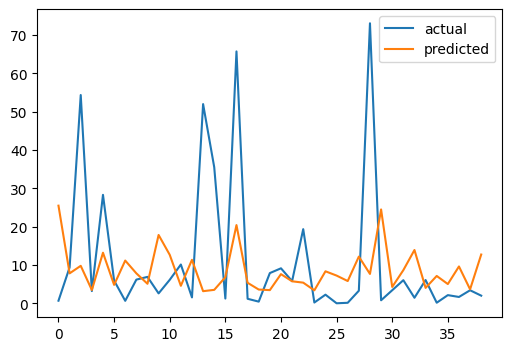

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CC ******
Best RMSE on test set: 34.9991
Best Median Absolute Error on test set: 3.5649
Best MAPE on test set: 3.9760
Best R2 score on test set: -0.0098
Best Hyperparams: {'regressor__regressor__learning_rate': 0.10623401949152074, 'regressor__regressor__max_depth': 8, 'regressor__regressor__max_features': 'sqrt', 'regressor__regressor__min_samples_leaf': 3, 'regressor__regressor__min_samples_split': 5, 'regressor__regressor__n_estimators': 502, 'regressor__regressor__subsample': 0.884459812975207}

****** Model Prediction vs. Actual Values for Revenue_CC ******


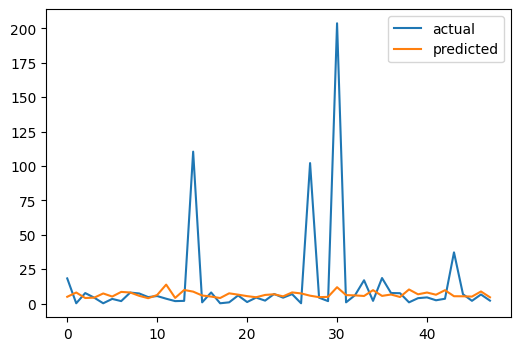

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CL ******
Best RMSE on test set: 7.9558
Best Median Absolute Error on test set: 6.2019
Best MAPE on test set: 1.3458
Best R2 score on test set: -0.6447
Best Hyperparams: {'regressor__regressor__learning_rate': 0.10623401949152074, 'regressor__regressor__max_depth': 8, 'regressor__regressor__max_features': 'sqrt', 'regressor__regressor__min_samples_leaf': 3, 'regressor__regressor__min_samples_split': 5, 'regressor__regressor__n_estimators': 502, 'regressor__regressor__subsample': 0.884459812975207}

****** Model Prediction vs. Actual Values for Revenue_CL ******


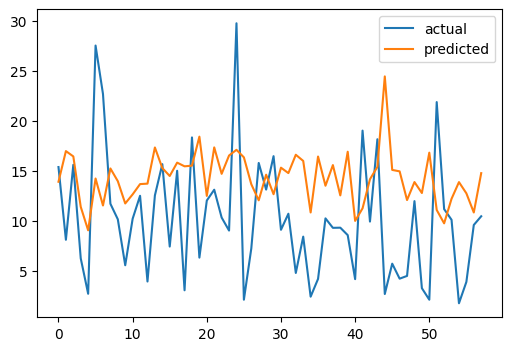




########## Baseline Models for enriched Dataset ##########
Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_MF ******
Best RMSE on test set: 27.4073
Best Median Absolute Error on test set: 5.8610
Best MAPE on test set: 14.6110
Best R2 score on test set: -1.1786
Best Hyperparams: {'regressor__regressor__learning_rate': 0.0983346676208757, 'regressor__regressor__max_depth': 7, 'regressor__regressor__max_features': None, 'regressor__regressor__min_samples_leaf': 1, 'regressor__regressor__min_samples_split': 4, 'regressor__regressor__n_estimators': 227, 'regressor__regressor__subsample': 0.7490747468376198}

****** Model Prediction vs. Actual Values for Revenue_MF ******


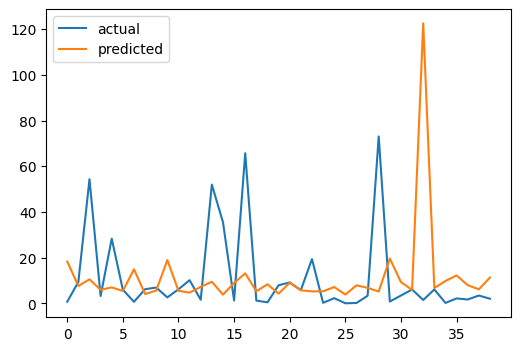

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CC ******
Best RMSE on test set: 35.4444
Best Median Absolute Error on test set: 3.9175
Best MAPE on test set: 4.6854
Best R2 score on test set: -0.0357
Best Hyperparams: {'regressor__regressor__learning_rate': 0.10623401949152074, 'regressor__regressor__max_depth': 8, 'regressor__regressor__max_features': 'sqrt', 'regressor__regressor__min_samples_leaf': 3, 'regressor__regressor__min_samples_split': 5, 'regressor__regressor__n_estimators': 502, 'regressor__regressor__subsample': 0.884459812975207}

****** Model Prediction vs. Actual Values for Revenue_CC ******


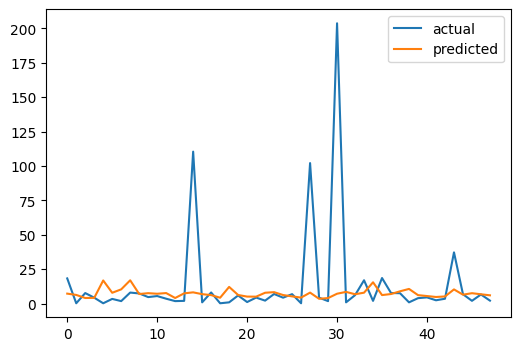

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CL ******
Best RMSE on test set: 8.3675
Best Median Absolute Error on test set: 7.0914
Best MAPE on test set: 1.4235
Best R2 score on test set: -0.8194
Best Hyperparams: {'regressor__regressor__learning_rate': 0.02906750508580709, 'regressor__regressor__max_depth': 9, 'regressor__regressor__max_features': 'log2', 'regressor__regressor__min_samples_leaf': 5, 'regressor__regressor__min_samples_split': 4, 'regressor__regressor__n_estimators': 783, 'regressor__regressor__subsample': 0.8550229885420852}

****** Model Prediction vs. Actual Values for Revenue_CL ******


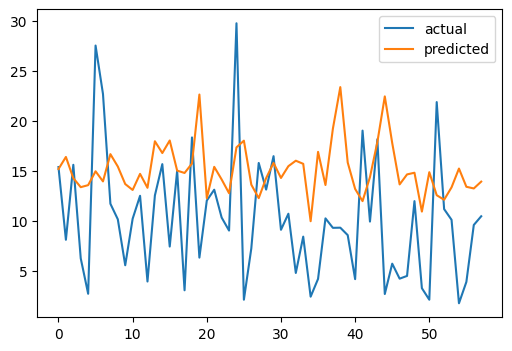




########## Baseline Models for transformed Dataset ##########
Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_MF ******
Best RMSE on test set: 19.2637
Best Median Absolute Error on test set: 4.9021
Best MAPE on test set: 21.7782
Best R2 score on test set: -0.0763
Best Hyperparams: {'regressor__regressor__learning_rate': 0.10623401949152074, 'regressor__regressor__max_depth': 8, 'regressor__regressor__max_features': 'sqrt', 'regressor__regressor__min_samples_leaf': 3, 'regressor__regressor__min_samples_split': 5, 'regressor__regressor__n_estimators': 502, 'regressor__regressor__subsample': 0.884459812975207}

****** Model Prediction vs. Actual Values for Revenue_MF ******


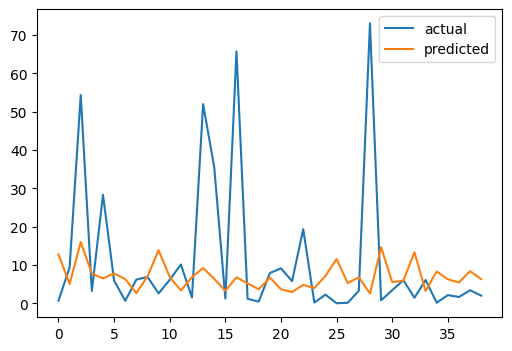

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CC ******
Best RMSE on test set: 34.9433
Best Median Absolute Error on test set: 3.3823
Best MAPE on test set: 4.0469
Best R2 score on test set: -0.0066
Best Hyperparams: {'regressor__regressor__learning_rate': 0.10623401949152074, 'regressor__regressor__max_depth': 8, 'regressor__regressor__max_features': 'sqrt', 'regressor__regressor__min_samples_leaf': 3, 'regressor__regressor__min_samples_split': 5, 'regressor__regressor__n_estimators': 502, 'regressor__regressor__subsample': 0.884459812975207}

****** Model Prediction vs. Actual Values for Revenue_CC ******


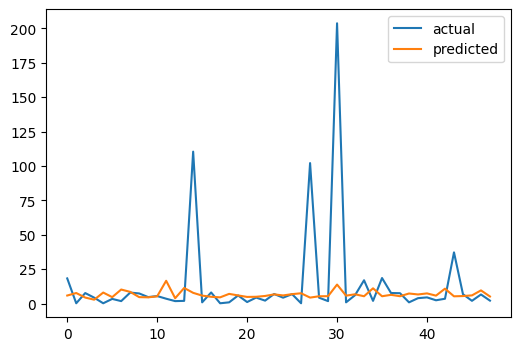

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CL ******
Best RMSE on test set: 8.2832
Best Median Absolute Error on test set: 6.0788
Best MAPE on test set: 1.3837
Best R2 score on test set: -0.7829
Best Hyperparams: {'regressor__regressor__learning_rate': 0.10623401949152074, 'regressor__regressor__max_depth': 8, 'regressor__regressor__max_features': 'sqrt', 'regressor__regressor__min_samples_leaf': 3, 'regressor__regressor__min_samples_split': 5, 'regressor__regressor__n_estimators': 502, 'regressor__regressor__subsample': 0.884459812975207}

****** Model Prediction vs. Actual Values for Revenue_CL ******


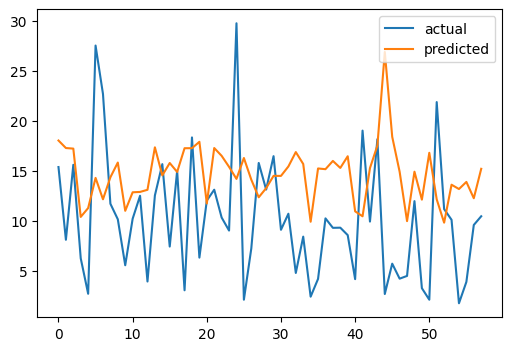

In [13]:
# Based on the analysis in the sections "3. Basic EDA of the Dataframes" and "4. Preparing the Datasets for Modeling and Prediction", we know than the targets 'Revenue_MF', 'Revenue_CC', and 'Revenue_CL' are highly right-skewed.
# Here, we apply TransformedTargetRegressor to handle skewed targets.

from sklearn.compose import TransformedTargetRegressor

for data_set_name, data_set in zip(['not_enriched', 'enriched', 'transformed'], [df_modeling, df_modeling_enriched, df_modeling_transformed]):

    print(f"########## Baseline Models for {data_set_name} Dataset ##########")
    # Iterate through each target variable
    for target_name, target_index in zip(target_names, target_indeces):
        df_reg_build = data_set[data_set[target_name]!=0].drop(['Client'], axis=1).astype('float32')
        # df_reg_build = data_set.drop(['Client'], axis=1).astype('float32')
        arr_reg_build = df_reg_build.values
        X = arr_reg_build[:, :-6]   
        y = arr_reg_build[:, target_index]
        
        # Split the dataset into train and test datasets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Define the pipeline
        pipe = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('regressor', GradientBoostingRegressor(loss='quantile', alpha=0.9, random_state=42))
        ])

        # Wrap with TransformedTargetRegressor to handle skewed targets
        model = TransformedTargetRegressor(
            regressor = pipe,
            func = np.log1p,          # Apply log(1 + y)
            inverse_func = np.expm1,   # Apply exp(y) - 1 to reverse
            check_inverse=False,  # Check if the inverse function is correct    
        )

        # Hyperparameter distributions for GradientBoostingRegressor
        # The hyperparameter tuning is performed on the training dataset.
        param_dist = {
            'regressor__regressor__n_estimators': randint(100, 1000),
            'regressor__regressor__learning_rate': uniform(0.01, 0.3), 
            'regressor__regressor__max_depth': randint(3, 10),
            'regressor__regressor__min_samples_split': randint(2, 20), 
            'regressor__regressor__min_samples_leaf': randint(1, 20),  
            'regressor__regressor__subsample': uniform(0.6, 0.4),
            'regressor__regressor__max_features': ['sqrt', 'log2', None] 
        }

        rs = RandomizedSearchCV(
            model,
            param_distributions=param_dist,
            scoring='neg_root_mean_squared_error',
            n_iter=50,  # Number of different combinations to try
            cv=10,
            verbose=1,
            random_state=42,
            n_jobs=-1
        )
        # Fit the model to the training data
        rs.fit(X_train, y_train)

        # Predict on test set
        y_pred = rs.best_estimator_.predict(X_test)
        # Calculate RMSE
        rmse = root_mean_squared_error(y_test, y_pred)


        # Print the results
        print(f"****** Baseline Model Metric and hyperparameters for {target_name} ******")
        print(f"Best RMSE on test set: {rmse:.4f}")
        print(f"Best Median Absolute Error on test set: {median_absolute_error(y_test, y_pred):.4f}")    
        print(f"Best MAPE on test set: {mean_absolute_percentage_error(y_test, y_pred):.4f}") 
        print(f"Best R2 score on test set: {r2_score(y_test, y_pred):.4f}")
        print(f"Best Hyperparams: {rs.best_params_}\n" )

        print(f"****** Model Prediction vs. Actual Values for {target_name} ******")
        # Get actual values
        predictions = pd.DataFrame(y_test, columns=['actual'])
        predictions['predicted'] = y_pred
        predictions.plot(kind='line',figsize=(6, 4))
        plt.show()
            
    print("\n\n")

#### <span style="color:orange">**Comments**</span>

The baseline model building results show that:
* The regression models fail to predict the target values accurately, especially for very large target values. </br>

This is a common and tough challenge in financial data, sales volumes, and similar domains — as what we deal with are the issues of extreme outliers or long-tail regression. In such cases, standard practices usually fail to accurately predict extreme values. </br>
A more strategic, layered approach is needed to tackling this regression problem. 

########## Baseline Models for not_enriched Dataset ##########
Fitting 10 folds for each of 50 candidates, totalling 500 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000083 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 586
[LightGBM] [Info] Number of data points in the train set: 154, number of used features: 17
[LightGBM] [Info] Start training from score 9.252906
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

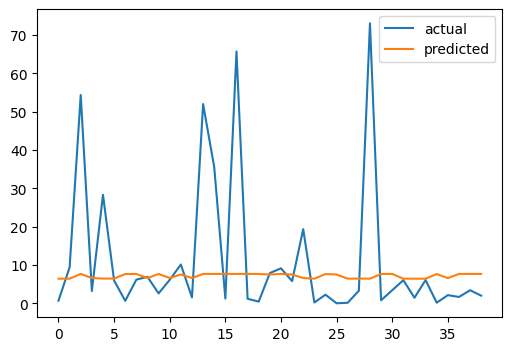

Fitting 10 folds for each of 50 candidates, totalling 500 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 728
[LightGBM] [Info] Number of data points in the train set: 189, number of used features: 20
[LightGBM] [Info] Start training from score 10.266498
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

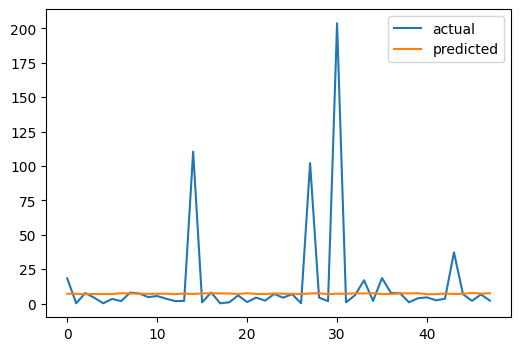

Fitting 10 folds for each of 50 candidates, totalling 500 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 834
[LightGBM] [Info] Number of data points in the train set: 231, number of used features: 18
[LightGBM] [Info] Start training from score 12.472723
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

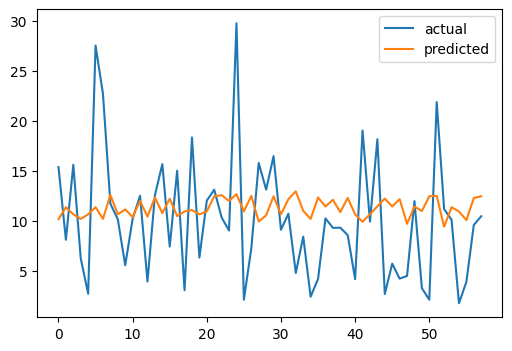




########## Baseline Models for enriched Dataset ##########
Fitting 10 folds for each of 50 candidates, totalling 500 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 930
[LightGBM] [Info] Number of data points in the train set: 154, number of used features: 27
[LightGBM] [Info] Start training from score 9.252906
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

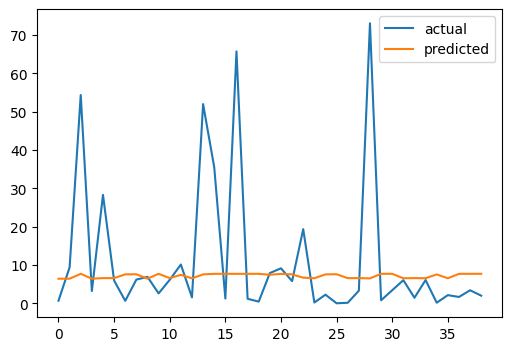

Fitting 10 folds for each of 50 candidates, totalling 500 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000432 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1269
[LightGBM] [Info] Number of data points in the train set: 189, number of used features: 44
[LightGBM] [Info] Start training from score 10.266498
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

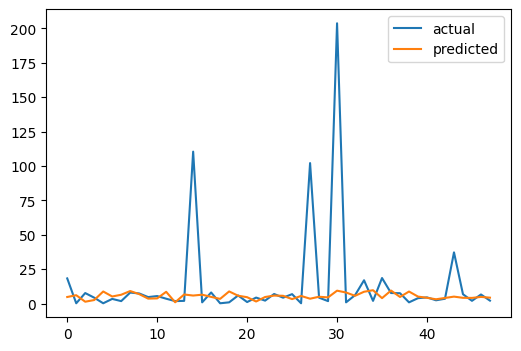

Fitting 10 folds for each of 50 candidates, totalling 500 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000226 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1382
[LightGBM] [Info] Number of data points in the train set: 231, number of used features: 34
[LightGBM] [Info] Start training from score 12.472723
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

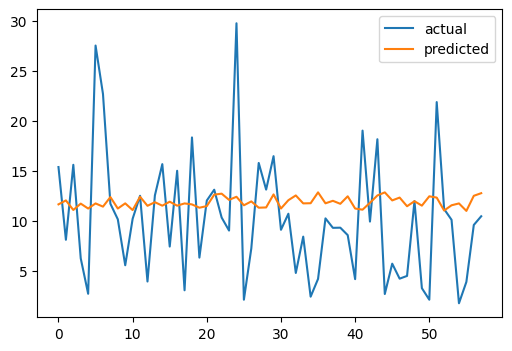

In [10]:
# Use LGBMRegressor to build the regression models, as LGBMRegressor often perform better than GradientBoostingRegressor in noisy data or long-tail problems.
from lightgbm import LGBMRegressor

for data_set_name, data_set in zip(['not_enriched', 'enriched'], [df_modeling, df_modeling_enriched]) :

    print(f"########## Baseline Models for {data_set_name} Dataset ##########")
    # Iterate through each target variable
    for target_name, target_index in zip(target_names, target_indeces):
        df_reg_build = data_set[data_set[target_name]!=0].drop(['Client'], axis=1).astype('float32')
        # df_reg_build = data_set.drop(['Client'], axis=1).astype('float32')
        arr_reg_build = df_reg_build.values
        X = arr_reg_build[:, :-6]   
        y = arr_reg_build[:, target_index]
        
        # Split the dataset into train and test datasets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Define the pipeline
        pipe = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('regressor', LGBMRegressor(objective='quantile', random_state=42))
        ])

        # Wrap with TransformedTargetRegressor to handle skewed targets
        model = TransformedTargetRegressor(
            regressor = pipe,
            func = np.log1p,          # Apply log(1 + y)
            inverse_func = np.expm1,   # Apply exp(y) - 1 to reverse
            check_inverse=False,  # Check if the inverse function is correct    
        )

        # Hyperparameter distributions for LGBMRegressor
        # The hyperparameter tuning is performed on the training dataset.
        param_dist = {
            'regressor__num_leaves': randint(20, 150),                   # Controls complexity
            'regressor__max_depth': randint(3, 15),                      # Max tree depth
            'regressor__learning_rate': uniform(0.01, 0.2),              # Smaller = slower but more accurate
            'regressor__n_estimators': randint(100, 1000),               # Number of boosting rounds
            'regressor__min_child_samples': randint(5, 100),             # Minimum samples in one leaf
            'regressor__subsample': uniform(0.5, 0.5),                   # Row sampling (like bagging)
            'regressor__colsample_bytree': uniform(0.5, 0.5),            # Feature sampling
            'regressor__reg_alpha': uniform(0.0, 1.0),                   # L1 regularization
            'regressor__reg_lambda': uniform(0.0, 1.0),                  # L2 regularization
            'regressor__boosting_type': ['gbdt', 'dart'],                # Boosting type
            'regressor__objective': ['regression', 'huber'],             # Objective function
        }

        rs = RandomizedSearchCV(
            pipe,
            param_distributions=param_dist,
            scoring='neg_root_mean_squared_error',
            n_iter=50,  # Number of different combinations to try
            cv=10,
            verbose=1,
            random_state=42,
            n_jobs=-1
        )
        # Fit the model to the training data
        rs.fit(X_train, y_train)

        # Predict on test set
        y_pred = rs.best_estimator_.predict(X_test)
        # Calculate RMSE
        rmse = root_mean_squared_error(y_test, y_pred)


        # Print the results
        print(f"****** Baseline Model Metric and hyperparameters for {target_name} ******")
        print(f"Best RMSE on test set: {rmse:.4f}")
        print(f"Best Median Absolute Error on test set: {median_absolute_error(y_test, y_pred):.4f}")    
        print(f"Best MAPE on test set: {mean_absolute_percentage_error(y_test, y_pred):.4f}") 
        print(f"Best R2 score on test set: {r2_score(y_test, y_pred):.4f}")
        print(f"Best Hyperparams: {rs.best_params_}\n" )

        print(f"****** Model Prediction vs. Actual Values for {target_name} ******")
        # Get actual values
        predictions = pd.DataFrame(y_test, columns=['actual'])
        predictions['predicted'] = y_pred
        predictions.plot(kind='line',figsize=(6, 4))
        plt.show()
            
    print("\n\n")

########## Baseline Models for not_enriched Dataset ##########
Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_MF ******
Best RMSE on test set: 9.5728
Best Median Absolute Error on test set: 0.4397
Best MAPE on test set: 1513338571849728.0000
Best R2 score on test set: -0.0695
Best Hyperparams: {'regressor__regressor__colsample_bytree': 0.5503890006887133, 'regressor__regressor__gamma': 0.09110912825774864, 'regressor__regressor__learning_rate': 0.038332888226778515, 'regressor__regressor__max_depth': 5, 'regressor__regressor__min_child_weight': 7, 'regressor__regressor__n_estimators': 948, 'regressor__regressor__reg_alpha': 0.6557226353807422, 'regressor__regressor__reg_lambda': 0.38539662096556504, 'regressor__regressor__subsample': 0.8408068344863948}

****** Model Prediction vs. Actual Values for Revenue_MF ******


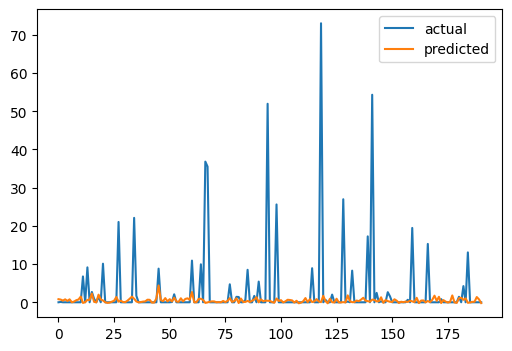

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CC ******
Best RMSE on test set: 18.2819
Best Median Absolute Error on test set: 0.6787
Best MAPE on test set: 1871533341409280.0000
Best R2 score on test set: -0.0411
Best Hyperparams: {'regressor__regressor__colsample_bytree': 0.9928252270553004, 'regressor__regressor__gamma': 1.2102763575575022, 'regressor__regressor__learning_rate': 0.21164066422176356, 'regressor__regressor__max_depth': 13, 'regressor__regressor__min_child_weight': 8, 'regressor__regressor__n_estimators': 222, 'regressor__regressor__reg_alpha': 0.24215993827742588, 'regressor__regressor__reg_lambda': 0.8031397563798959, 'regressor__regressor__subsample': 0.7351503172230192}

****** Model Prediction vs. Actual Values for Revenue_CC ******


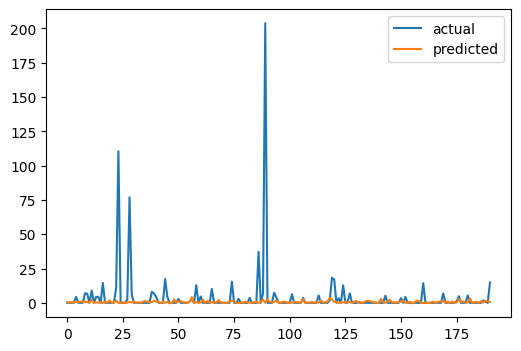

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CL ******
Best RMSE on test set: 6.7250
Best Median Absolute Error on test set: 1.1445
Best MAPE on test set: 3547371598249984.0000
Best R2 score on test set: 0.0196
Best Hyperparams: {'regressor__regressor__colsample_bytree': 0.982627653632069, 'regressor__regressor__gamma': 3.0351712384334233, 'regressor__regressor__learning_rate': 0.092799754606763, 'regressor__regressor__max_depth': 3, 'regressor__regressor__min_child_weight': 9, 'regressor__regressor__n_estimators': 938, 'regressor__regressor__reg_alpha': 0.4234014807063696, 'regressor__regressor__reg_lambda': 0.3948815181755697, 'regressor__regressor__subsample': 0.6467440873590191}

****** Model Prediction vs. Actual Values for Revenue_CL ******


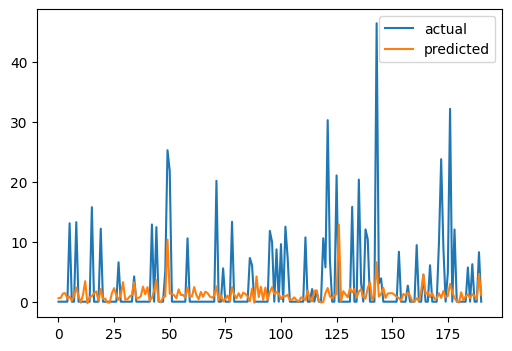




########## Baseline Models for enriched Dataset ##########
Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_MF ******
Best RMSE on test set: 9.6403
Best Median Absolute Error on test set: 0.3693
Best MAPE on test set: 1768884696776704.0000
Best R2 score on test set: -0.0847
Best Hyperparams: {'regressor__regressor__colsample_bytree': 0.6250082246080524, 'regressor__regressor__gamma': 2.902720061719549, 'regressor__regressor__learning_rate': 0.2701349821629166, 'regressor__regressor__max_depth': 7, 'regressor__regressor__min_child_weight': 1, 'regressor__regressor__n_estimators': 794, 'regressor__regressor__reg_alpha': 0.7508710677914974, 'regressor__regressor__reg_lambda': 0.7545428740846823, 'regressor__regressor__subsample': 0.5515619344179663}

****** Model Prediction vs. Actual Values for Revenue_MF ******


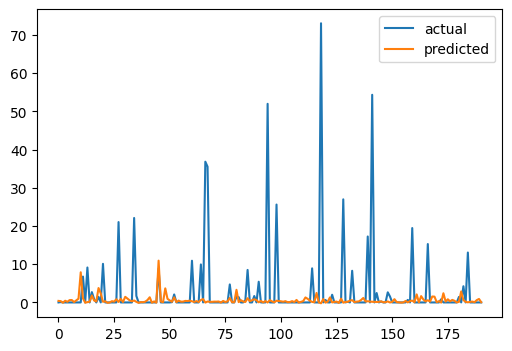

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CC ******
Best RMSE on test set: 18.2438
Best Median Absolute Error on test set: 0.5099
Best MAPE on test set: 1581112350474240.0000
Best R2 score on test set: -0.0368
Best Hyperparams: {'regressor__regressor__colsample_bytree': 0.6246461145744375, 'regressor__regressor__gamma': 2.0519146151781484, 'regressor__regressor__learning_rate': 0.2366653415629146, 'regressor__regressor__max_depth': 6, 'regressor__regressor__min_child_weight': 7, 'regressor__regressor__n_estimators': 798, 'regressor__regressor__reg_alpha': 0.6947849330397046, 'regressor__regressor__reg_lambda': 0.8804678390152577, 'regressor__regressor__subsample': 0.8121770240668966}

****** Model Prediction vs. Actual Values for Revenue_CC ******


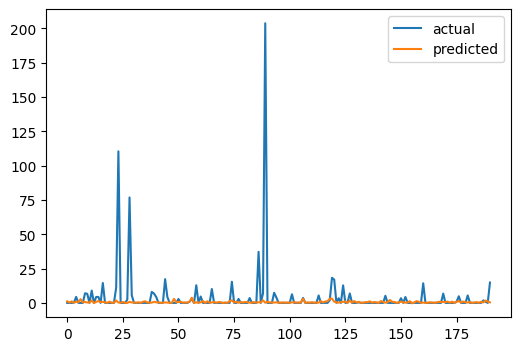

Fitting 10 folds for each of 50 candidates, totalling 500 fits
****** Baseline Model Metric and hyperparameters for Revenue_CL ******
Best RMSE on test set: 6.7798
Best Median Absolute Error on test set: 1.1697
Best MAPE on test set: 3571501529825280.0000
Best R2 score on test set: 0.0035
Best Hyperparams: {'regressor__regressor__colsample_bytree': 0.767044709687721, 'regressor__regressor__gamma': 2.424149856794916, 'regressor__regressor__learning_rate': 0.2177308098670811, 'regressor__regressor__max_depth': 12, 'regressor__regressor__min_child_weight': 8, 'regressor__regressor__n_estimators': 926, 'regressor__regressor__reg_alpha': 0.32320293202075523, 'regressor__regressor__reg_lambda': 0.5187906217433661, 'regressor__regressor__subsample': 0.8515094794475889}

****** Model Prediction vs. Actual Values for Revenue_CL ******


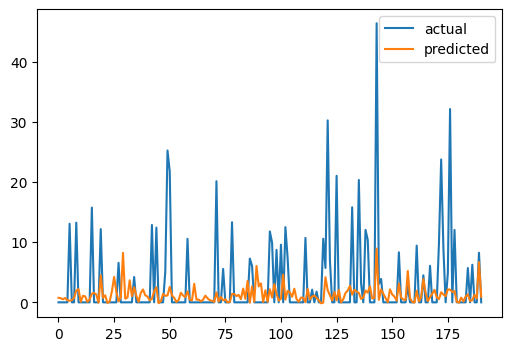

In [7]:
# Use XGBRegressor to build the regression models.
from xgboost import XGBRegressor

for data_set_name, data_set in zip(['not_enriched', 'enriched'], [df_modeling, df_modeling_enriched]) :

    print(f"########## Baseline Models for {data_set_name} Dataset ##########")
    # Iterate through each target variable
    for target_name, target_index in zip(target_names, target_indeces):
        # df_reg_build = data_set[data_set[target_name]!=0].drop(['Client'], axis=1).astype('float32')
        df_reg_build = data_set.drop(['Client'], axis=1).astype('float32')
        arr_reg_build = df_reg_build.values
        X = arr_reg_build[:, :-6]   
        y = arr_reg_build[:, target_index]
        
        # Split the dataset into train and test datasets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Define the pipeline
        pipe = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('regressor', XGBRegressor(objective='reg:squarederror', random_state=42))
        ])

        # Wrap with TransformedTargetRegressor to handle skewed targets
        model = TransformedTargetRegressor(
            regressor = pipe,
            func = np.log1p,          # Apply log(1 + y)
            inverse_func = np.expm1,   # Apply exp(y) - 1 to reverse
            check_inverse=False,  # Check if the inverse function is correct    
        )

        # Hyperparameter distributions for XGBRegressor
        # The hyperparameter tuning is performed on the training dataset.
        param_dist = {
            'regressor__regressor__n_estimators': randint(100, 1000),              # Number of trees
            'regressor__regressor__learning_rate': uniform(0.01, 0.3),             # Step size shrinkage
            'regressor__regressor__max_depth': randint(3, 15),                     # Max depth of each tree
            'regressor__regressor__min_child_weight': randint(1, 10),              # Minimum sum of instance weight needed in a child
            'regressor__regressor__gamma': uniform(0, 5),                          # Minimum loss reduction to make a split
            'regressor__regressor__subsample': uniform(0.5, 0.5),                  # % of rows sampled per tree
            'regressor__regressor__colsample_bytree': uniform(0.5, 0.5),           # % of features sampled per tree
            'regressor__regressor__reg_alpha': uniform(0, 1.0),                    # L1 regularization term
            'regressor__regressor__reg_lambda': uniform(0, 1.0),                   # L2 regularization term
        }

        rs = RandomizedSearchCV(
            model,
            param_distributions=param_dist,
            scoring='neg_root_mean_squared_error',
            n_iter=50,  # Number of different combinations to try
            cv=10,
            verbose=1,
            random_state=42,
            n_jobs=-1
        )
        # Fit the model to the training data
        rs.fit(X_train, y_train)

        # Predict on test set
        y_pred = rs.best_estimator_.predict(X_test)
        # Calculate RMSE
        rmse = root_mean_squared_error(y_test, y_pred)


        # Print the results
        print(f"****** Baseline Model Metric and hyperparameters for {target_name} ******")
        print(f"Best RMSE on test set: {rmse:.4f}")
        print(f"Best Median Absolute Error on test set: {median_absolute_error(y_test, y_pred):.4f}")    
        print(f"Best MAPE on test set: {mean_absolute_percentage_error(y_test, y_pred):.4f}") 
        print(f"Best R2 score on test set: {r2_score(y_test, y_pred):.4f}")
        print(f"Best Hyperparams: {rs.best_params_}\n" )

        print(f"****** Model Prediction vs. Actual Values for {target_name} ******")
        # Get actual values
        predictions = pd.DataFrame(y_test, columns=['actual'])
        predictions['predicted'] = y_pred
        predictions.plot(kind='line',figsize=(6, 4))
        plt.show()
            
    print("\n\n")

### Exploring Modeling Methods and Regression Errors 

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error

models = [RandomForestRegressor(random_state=0), 
          GradientBoostingRegressor(random_state=0), 
          XGBRegressor(booster='gblinear', random_state=0)]
model_names = ["RandomForest", "GradientBoosting", "XGBoost"]

target_names = ['Revenue_MF', 'Revenue_CC', 'Revenue_CL']
target_indeces = [-3, -2, -1]


for target_name, target_index in zip(target_names, target_indeces):

    df_Rev_build = df_modeling[df_modeling[target_name]!=0].drop(['Client'], axis=1).astype('float32')

    arr_build = df_Rev_build.values
    
    # Scale the data using StandardScaler, as the ensemble regression models are sensetive to scaling 
    scaler = StandardScaler()
    
    arr_scaled = scaler.fit_transform(arr_build)

    X = arr_scaled[:, :-6]
    y = arr_scaled[:, target_index]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"****** Cross-Validation Scores for {target_name} ******")
  
    for model, model_name in zip(models, model_names):
        
        model = model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        print(f"-- {model_name} --")
        # R^2 score
        print("\tMean negtive MAPE:", cross_val_score(model, X, y, scoring="neg_mean_absolute_percentage_error", cv=10, n_jobs=-1).mean()) 
        
        # MAPE on the test set
        print("\tMAPE on test set:", mean_absolute_percentage_error(y_test, y_pred), "\n") 


Cross-validation results show that the MAPE scroes for different modeling algorithms are quite high. **GradientBoostingRegressor** is selected to build the final regression models, as it can be used to generate prediction intervals to give a reasonable range of estimation. 

In [ ]:
# Set lower and upper quantile to produce a 90% confidence interval
LOWER_ALPHA = 0.05
UPPER_ALPHA = 0.95

# Investigate the prediction interval by using GradientBoostingRegressor 
for target_name, target_index in zip(target_names, target_indeces):
    
    df_Rev_build = df_modeling[df_modeling[target_name]!=0].drop(['Client'], axis=1).astype('float32')

    arr_build = df_Rev_build.values
    
    # Scale the data using StandardScaler, as the ensemble regression models are sensetive to scaling 
    scaler = StandardScaler()
    
    arr_scaled = scaler.fit_transform(arr_build)

    X = arr_scaled[:, :-6]
    y = arr_scaled[:, target_index]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"****** Modeling Results for {target_name} ******")    
    
    # Each model has to be separate
    lower_model = GradientBoostingRegressor(loss="quantile", alpha=LOWER_ALPHA)

    # The mid model will use the default loss
    mid_model = GradientBoostingRegressor(loss="quantile", alpha=0.5)

    upper_model = GradientBoostingRegressor(loss="quantile", alpha=UPPER_ALPHA)


    # Fit models
    lower_model.fit(X_train, y_train)
    mid_model.fit(X_train, y_train)
    upper_model.fit(X_train, y_train)
    
    # Get actual values
    predictions = pd.DataFrame(y_test, columns=['actual'])
    
    # Predict
    predictions['lower'] = lower_model.predict(X_test)
    predictions['mid'] = mid_model.predict(X_test)
    predictions['upper'] = upper_model.predict(X_test)
    
    predictions.plot(kind='line',figsize=(6, 4))
    plt.show()


The plots of prediction intervals indicate that the models trained with the quantile loss and different alpha values can generate the good prediction intervals:
* The actual values are usually within the interval derived by the "lower" and "upper" models.
* The "mid" models can be used to generate reasonable estimates of the actual target values. 
<br/><br/>

Therefore, in the marketing optimization, we are going to use the "mid" models to estimate the revenues, while the "lower" and "upper" models will be used to give the 90% confidence interval of the estimation.   

### Building Final Regression Models

In [ ]:
# Build final classification models
def train_regressors(df_modeling: pd.DataFrame, target_name, target_index: int) -> (GradientBoostingRegressor,
                                                                                    GradientBoostingRegressor,
                                                                                    GradientBoostingRegressor,
                                                                                    StandardScaler):
    
    df_Rev_build = df_modeling[df_modeling[target_name]!=0].drop(['Client'], axis=1).astype('float32')

    arr_build = df_Rev_build.values
    
    X = arr_build[:, :-6]
    y = arr_build[:, target_index].reshape(-1, 1)    
    
    arr_filtered = np.concatenate((X, y), axis=1)
    
    # Scale the data using StandardScaler 
    scaler = StandardScaler()
    
    arr_scaled = scaler.fit_transform(arr_filtered)
    
    X_scaled = arr_scaled[:, :-1]
    y_scaled = arr_scaled[:, -1]    
    
    # Define models
    lower_model = GradientBoostingRegressor(loss="quantile", alpha=LOWER_ALPHA)
    mid_model = GradientBoostingRegressor(loss="quantile", alpha=0.5)
    upper_model = GradientBoostingRegressor(loss="quantile", alpha=UPPER_ALPHA)
    
    # Fit models
    lower_model.fit(X_scaled, y_scaled)
    mid_model.fit(X_scaled, y_scaled)
    upper_model.fit(X_scaled, y_scaled)
    
    return lower_model, mid_model, upper_model, scaler


reg_rev_MF_lower, reg_rev_MF_mid, reg_rev_MF_upper, scaler_rev_MF = train_regressors(df_modeling, 
                                                                                     target_names[0], 
                                                                                     target_indeces[0])

reg_rev_CC_lower, reg_rev_CC_mid, reg_rev_CC_upper, scaler_rev_CC = train_regressors(df_modeling, 
                                                                                     target_names[1], 
                                                                                     target_indeces[1])

reg_rev_CL_lower, reg_rev_CL_mid, reg_rev_CL_upper, scaler_rev_CL = train_regressors(df_modeling, 
                                                                                     target_names[2], 
                                                                                     target_indeces[2])


## 7. Generate Optimazation Results to Maximize Revenue

### Estimating Buying Propensity Using the Classification Models

In [ ]:
df_propensity = pd.DataFrame().assign(Client=df_prediction['Client'])
array_prediction = df_prediction.drop(['Client'], axis=1).astype('float32').values
total_num_clients = array_prediction.shape[0]

prob_names = ['prob_MF', 'prob_CC', 'prob_CL']
classifiers = [classifier_Sale_MF, classifier_Sale_CC, classifier_Sale_CL]
target_rates = [target_rate_Sale_MF, target_rate_Sale_CC, target_rate_Sale_CL]

for prob_name, classifier, target_rate in zip(prob_names, classifiers, target_rates):

    # Estimate the probability for a specific product
    probs = classifier.predict_proba(array_prediction)[:, 1]

    # Normalize the probability to make the target rate consistent with that in the training set  
    propensity = probs * (target_rate * total_num_clients) / probs.sum() 

    df_propensity[prob_name] = propensity


### Estimating Revenue and Confidence Intervals Using the Regression Models

In [ ]:
rev_names = [{'mid': 'rev_MF', 'lower': 'rev_MF_lower', 'upper': 'rev_MF_upper'},
             {'mid': 'rev_CC', 'lower': 'rev_CC_lower', 'upper': 'rev_CC_upper'},
             {'mid': 'rev_CL', 'lower': 'rev_CL_lower', 'upper': 'rev_CL_upper'}]

regressors  = [{'mid': reg_rev_MF_mid, 'lower': reg_rev_MF_lower, 'upper': reg_rev_MF_upper},
               {'mid': reg_rev_CC_mid, 'lower': reg_rev_CC_lower, 'upper': reg_rev_CC_upper},
               {'mid': reg_rev_CL_mid, 'lower': reg_rev_CL_lower, 'upper': reg_rev_CL_upper}]

scalers = [scaler_rev_MF, scaler_rev_CC, scaler_rev_CL]


for rev_name, regressor, scaler in zip(rev_names, regressors, scalers):

    # Scale the features
    array_scaled = scaler.transform(np.hstack((array_prediction, np.zeros((array_prediction.shape[0], 1)))))

    # Estimate the revenue for a specific product
    rev = regressor['mid'].predict(array_scaled[:, :-1])
    rev_lower = regressor['lower'].predict(array_scaled[:, :-1])
    rev_upper = regressor['upper'].predict(array_scaled[:, :-1])

    # Invert scaling for prediction
    inv_rev = np.concatenate((array_scaled[:, :-1], rev.reshape(-1, 1)), axis=1)
    inv_rev = scaler.inverse_transform(inv_rev)
    inv_rev = inv_rev[:, -1]

    inv_rev_lower = np.concatenate((array_scaled[:, :-1], rev_lower.reshape(-1, 1)), axis=1)
    inv_rev_lower = scaler.inverse_transform(inv_rev_lower)
    inv_rev_lower = inv_rev_lower[:,-1]

    inv_rev_upper = np.concatenate((array_scaled[:, :-1], rev_upper.reshape(-1, 1)), axis=1)
    inv_rev_upper = scaler.inverse_transform(inv_rev_upper)
    inv_rev_upper = inv_rev_upper[:, -1]


    df_propensity[rev_name['mid']] = inv_rev
    df_propensity[rev_name['lower']] = inv_rev_lower
    df_propensity[rev_name['upper']] = inv_rev_upper


### Generating Optimization Results for Direct Marketing Campaign

In [ ]:
df_predicted = df_propensity.copy()

for product_name in ['MF', 'CC', 'CL']:
    # Calculate the expected revenue for each product
    df_predicted[f'rev_{product_name}_exp'] = df_predicted[f'prob_{product_name}'] * df_predicted[f'rev_{product_name}']
    df_predicted[f'rev_{product_name}_lower_exp'] = df_predicted[f'prob_{product_name}'] * df_predicted[f'rev_{product_name}_lower']
    df_predicted[f'rev_{product_name}_upper_exp'] = df_predicted[f'prob_{product_name}'] * df_predicted[f'rev_{product_name}_upper']
    
# Calculate the expected total revenue    
df_predicted['rev_total_exp'] = df_predicted['rev_MF_exp'] + df_predicted['rev_CC_exp'] + df_predicted['rev_CL_exp']
df_predicted['rev_total_lower_exp'] = df_predicted['rev_MF_lower_exp'] + df_predicted['rev_CC_lower_exp'] + df_predicted['rev_CL_lower_exp']
df_predicted['rev_total_upper_exp'] = df_predicted['rev_MF_upper_exp'] + df_predicted['rev_CC_upper_exp'] + df_predicted['rev_CL_upper_exp']

# Get the top 100 clients to maximize the expected total revenue  
df_predicted = df_predicted.sort_values(by='rev_total_exp', axis=0, ascending=False)
df_optimized = df_predicted.iloc[0:100]

df_optimized = df_optimized[['Client', 'prob_MF', 'prob_CC', 'prob_CL', 'rev_total_exp', 'rev_total_lower_exp', 'rev_total_upper_exp'] ]

print(f"Expected Number of Clients to Buy MF: {df_optimized['prob_MF'].values.sum()}")
print(f"Expected Number of Clients to Buy CC: {df_optimized['prob_CC'].values.sum()}")
print(f"Expected Number of Clients to Buy CL: {df_optimized['prob_CL'].values.sum()}")

print(f"Expected Total Revenue: {df_optimized['rev_total_exp'].values.sum()}")
print(f"90% Confidence Interval of Expected Total Revenue: [{df_optimized['rev_total_lower_exp'].values.sum()}, {df_optimized['rev_total_upper_exp'].values.sum()}]")


In [ ]:
df_optimized.to_csv("Campaign_Targets.csv", index=False)

In [ ]:
df_propensity['prob_MF'].values